# CryptoStatArb — Research Notebook

**Statistical Arbitrage in Cryptocurrencies** (WSQ Course Project)

Goal: research profitable **momentum and/or reversal** strategies on crypto,
backtest unconstrained, apply realistic execution costs (Binance.US, Tier 1),
and evaluate returns / vol / Sharpe / max drawdown / alpha-beta.

Exchange: [Binance.US](https://www.binance.us/fees)

In [1]:
# --- Core libs ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from pathlib import Path

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Canonical dataset — build once via download_data.ipynb, then load here:
DATA_DIR = Path('data')
# panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
# close, volume = panel['Close'], panel['Volume']
# ret = close.pct_change()

In [2]:
# --- Binance.US commission (published standard rates, checked 2026-08-27) ---
FEES = {
    'maker_bps': 0.0,      # 0.00%  limit orders that ADD liquidity
    'taker_bps': 2.0,      # 0.02%  market orders that TAKE liquidity
    'bnb_discount': 0.05,  # 5% off maker & taker when fees paid in BNB
}

# Course-project baseline (from ClassProject brief) for cross-checking backtests:
#   market order = 7 bps commission + 13 bps assumed slippage = 20 bps all-in
#   limit order  = 7 bps commission only
PROJECT_COST_ASSUMPTION = {
    'commission_bps': 7.0,
    'slippage_bps': 13.0,
    'market_all_in_bps': 20.0,
    'limit_bps': 7.0,
}

# Asset-dependent costs (half-spread, impact) are filled in per symbol later, e.g.:
#   SYMBOL_TCOSTS = {'BTCUSDT': {'half_spread_bps': ..., 'impact_bps': ...}, ...}
SYMBOL_TCOSTS = {}

def bps(x):
    """basis points -> decimal (e.g. 20 -> 0.0020)."""
    return x / 1e4

FEES

{'maker_bps': 0.0, 'taker_bps': 2.0, 'bnb_discount': 0.05}

## Performance & Risk Metrics (reusable helpers)

Conventions follow the WSQ course (updated per mentor feedback, 2026-09-09):

- **Sharpe is computed on *daily aggregated* strategy returns**, annualized `mean / std * √252`.
  Any input frequency is resampled to daily first by `to_daily()`, so you never pass a bar-count.
- **The benchmark for alpha/beta is BTC** — not an equal-weight crypto market. An equal-weight
  basket of 60 coins is dragged down by dying alts, which flatters any long-biased strategy.
- Every summary reports **alpha (annualized), alpha t-stat, beta, and correlation** vs that benchmark.

Inputs:
- `strat_ret` — strategy **return** series, any frequency (aggregated to daily internally).
- `port` — the **weights** DataFrame (time × asset), used for turnover.
- `benchmark` — BTC daily returns.
- `kind` — `'simple'` (compound within the day) or `'log'` (sum within the day). Match your P&L.

> **Note on √252.** Crypto trades 365 days a year, so `√252` understates Sharpe by
> `√(252/365) ≈ 0.83` — a systematic ~17% haircut. We use it anyway for consistency with the rest of
> the course; `ANN_CRYPTO = 365` is available if the calendar-correct figure is ever needed.

In [3]:
# --- Performance & risk metrics ---------------------------------------------
# Course convention (per mentor feedback 2026-09-09): aggregate strategy returns to DAILY,
# then annualize with mean / std * sqrt(252). Benchmark for alpha/beta is BTC, not an
# equal-weight crypto market.
ANN_TRADING = 252    # course convention -- use this for every reported number
ANN_CRYPTO  = 365    # calendar-correct for 24/7 crypto; for reference only
# NOTE: sqrt(252) on data that trades 365 days/yr scales Sharpe by sqrt(252/365) ~ 0.83,
# i.e. a systematic ~17% haircut. Kept for consistency with the rest of the course.

def to_daily(ret, kind='simple'):
    """Aggregate a return series of ANY frequency to daily returns.

    kind='simple' -> compound within the day: prod(1+r) - 1
    kind='log'    -> sum within the day (log returns are additive over time)
    Already-daily input passes through unchanged.
    """
    if kind == 'log':
        return ret.resample('1D').sum(min_count=1).dropna()
    return ((1 + ret).resample('1D').prod(min_count=1) - 1).dropna()

def sharpe(daily_ret, ann=ANN_TRADING):
    """Annualized Sharpe from DAILY returns: mean / std * sqrt(ann)."""
    sd = daily_ret.std()
    return np.nan if not sd else daily_ret.mean() / sd * np.sqrt(ann)

def drawdown(equity):
    """Drawdown series from an equity/price curve (WSQ convention)."""
    return equity / equity.expanding(min_periods=1).max() - 1

def equity_curve(ret):
    """Compounded equity from per-period SIMPLE returns (starts at 1)."""
    return (1 + ret.fillna(0)).cumprod()

def max_drawdown(ret):
    """Worst peak-to-trough drawdown (a negative number)."""
    return drawdown(equity_curve(ret)).min()

def max_dd_duration(ret):
    """Longest underwater stretch, in periods of the input series."""
    eq = equity_curve(ret)
    underwater = eq < eq.expanding(min_periods=1).max()
    return int(underwater.groupby((~underwater).cumsum()).cumsum().max())

def turnover(port):
    """Per-period turnover: sum_i |w_it - w_i,t-1|  (WSQ formula). Returns a Series."""
    return (port.fillna(0) - port.shift().fillna(0)).abs().sum(1)

def alpha_beta(strat_ret, benchmark_ret, ann=ANN_TRADING):
    """Regress strategy on benchmark: strat = alpha + beta * benchmark + eps.

    Both inputs should be DAILY returns. Returns a Series so the fields are unambiguous:
      alpha_ann -- annualized intercept (per-period alpha * ann)
      alpha_t   -- t-stat of the intercept: is the alpha distinguishable from zero?
      beta      -- OLS slope (exposure to the benchmark)
      corr      -- correlation of the two return series
      r2        -- fraction of strategy variance explained by the benchmark
    """
    nan = pd.Series({k: np.nan for k in ['alpha_ann', 'alpha_t', 'beta', 'corr', 'r2']})
    if benchmark_ret is None:
        return nan
    d = pd.concat([strat_ret, benchmark_ret], axis=1).dropna()
    d.columns = ['strat', 'bench']
    if len(d) < 3 or not d.bench.std() or not d.strat.std():
        return nan
    res = sm.OLS(d.strat, sm.add_constant(d.bench)).fit()
    return pd.Series({'alpha_ann': res.params.iloc[0] * ann,
                      'alpha_t':   res.tvalues.iloc[0],
                      'beta':      res.params.iloc[1],
                      'corr':      d.strat.corr(d.bench),
                      'r2':        res.rsquared})

def beta_contribution(strat_ret, benchmark_ret):
    """The beta * benchmark component of returns (the 'market' part of P&L)."""
    return alpha_beta(strat_ret, benchmark_ret)['beta'] * benchmark_ret

def performance_summary(strat_ret, port=None, benchmark=None, ann=ANN_TRADING,
                        name='strategy', kind='simple'):
    """One-row summary for a strategy return series of any frequency.

    Returns are aggregated to daily first, so `ann` is 252 (course convention).
    `benchmark` should be BTC daily returns; `port` is the weights frame, for turnover.
    """
    d = to_daily(strat_ret, kind)
    bm = to_daily(benchmark, kind) if benchmark is not None else None
    ab = alpha_beta(d, bm, ann)
    return pd.Series({
        'ann_return':      d.mean() * ann,
        'ann_vol':         d.std() * np.sqrt(ann),
        'sharpe':          sharpe(d, ann),
        'avg_turnover':    turnover(port).mean() if port is not None else np.nan,
        'max_drawdown':    max_drawdown(d),
        'max_dd_dur_days': max_dd_duration(d),
        'alpha_ann':       ab['alpha_ann'],
        'alpha_t':         ab['alpha_t'],
        'beta':            ab['beta'],
        'corr':            ab['corr'],
    }, name=name)

def summary_table(strats, ports=None, benchmark=None, ann=ANN_TRADING, kind='simple'):
    """Metrics table (rows = strategies) from a dict {name: return_series}.
       `ports`: optional {name: weights_df}."""
    rows = []
    for nm, r in strats.items():
        p = ports.get(nm) if isinstance(ports, dict) else None
        a = ann.get(nm, ANN_TRADING) if isinstance(ann, dict) else ann
        rows.append(performance_summary(r, p, benchmark, a, nm, kind))
    return pd.DataFrame(rows)

print('metrics ready:', [f.__name__ for f in
      (to_daily, sharpe, drawdown, max_drawdown, max_dd_duration, turnover,
       alpha_beta, beta_contribution, performance_summary, summary_table)])
print(f'annualization: ANN_TRADING={ANN_TRADING} (course, reported) | ANN_CRYPTO={ANN_CRYPTO} (reference)')

metrics ready: ['to_daily', 'sharpe', 'drawdown', 'max_drawdown', 'max_dd_duration', 'turnover', 'alpha_beta', 'beta_contribution', 'performance_summary', 'summary_table']
annualization: ANN_TRADING=252 (course, reported) | ANN_CRYPTO=365 (reference)


### Using the metrics

```python
btc = logret['BTCUSDT']          # the benchmark: BTC, not an equal-weight basket

# one strategy (returns at any frequency; aggregated to daily internally):
performance_summary(strat_ret, port, benchmark=btc, name='xs_momentum')

# several at once -> a table:
summary_table({'gross': r_gross, 'net_20bps': r_net},
              ports={'gross': w, 'net_20bps': w},
              benchmark=btc)

# just the regression, if that's all you need:
alpha_beta(to_daily(strat_ret), to_daily(btc))
# -> alpha_ann, alpha_t, beta, corr, r2
```

**Reading the output.** `sharpe` is the headline, but `alpha_t` is what says whether the strategy adds
anything *beyond* BTC exposure. A high Sharpe with `beta ≈ 0.5` and `alpha_t ≈ 1.0` is mostly a levered
BTC position, not a strategy. For a dollar-neutral book expect `beta ≈ 0` and near-all-alpha.

`max_dd_dur_days` is in days. Pass `kind='log'` if your P&L series is log returns.

## Data & Log Prices

Load the canonical panel (built by `download_data.ipynb`), resample to **daily** closes, and take **log prices** (then log returns) — the base series for all the EDA below.

In [4]:
# --- Daily log prices for all coins (resample hourly UTC close -> daily close) ---
# Daily (not hourly) so the ADF test isn't drowned in 40k obs of excess power.
close = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')['Close']
dclose = close.resample('1D').last()
logpx = np.log(dclose)
print('daily log-price panel:', logpx.shape, '|', logpx.index.min().date(), '->', logpx.index.max().date())
logpx.tail()

daily log-price panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,-2.3925,4.8808,-1.5079,-2.3919,-1.9235,-1.4524,0.4200,-4.3306,2.0200,-0.0182,...,-1.4740,1.4490,-5.1678,-5.6840,-7.8833,-1.6439,7.8528,6.7202,1.6956,-2.3157
2026-08-25 00:00:00+00:00,-2.3570,4.8347,-1.5649,-2.4137,-1.9604,-1.4524,0.4167,-4.3709,1.9912,0.0583,...,-1.6296,1.4351,-5.1795,-5.6840,-7.9074,-1.7019,7.8528,6.6436,1.6292,-2.3486
2026-08-26 00:00:00+00:00,-2.3623,4.8363,-1.5481,-2.4088,-1.9733,-1.4524,0.4095,-4.3725,2.0081,-0.0471,...,-1.5995,1.4791,-5.0046,-5.6840,-7.8240,-1.6870,7.6563,6.7049,1.6094,-2.3026
2026-08-27 00:00:00+00:00,-2.3570,4.8577,-1.5421,-2.3928,-1.9442,-1.4524,0.4511,-4.3103,2.0189,-0.0141,...,-1.5945,1.5510,-4.9362,-5.6840,-7.7848,-1.6738,7.6563,6.6967,1.6974,-2.3056
2026-08-28 00:00:00+00:00,-2.4453,4.8112,-1.5941,-2.4421,-1.9885,-1.4439,0.3743,-4.2708,1.9844,-0.0141,...,-1.6503,1.4893,-5.0056,-5.6840,-7.8291,-1.7217,7.6563,6.6727,1.5933,-2.3549


## Exploratory Data Analysis

Understand the universe before any strategy work:
1. **Log returns** — `logret = logpx.diff()`, daily continuously-compounded returns.
2. **Price history** — raw daily close for all 60 coins (small multiples).
3. **Return correlation** — Pearson correlation of daily log returns, on a heatmap.
4. **Detrended price** — each coin's cumulative BTC-beta-neutral residual (own β per coin), 2023 onward.
5. **Intraday structure (GAM)** — seasonality of absolute *and signed* returns, volume, and volatility over hour-of-day × weekday.
6. **Real order-book spread** — live best bid/ask per coin → true intraday illiquidity, the *tradeable* universe, and how the spread moves over time.
7. **Volatility dynamics & distributions** — rolling realized vol of 4-hour returns, plus the distributions of price, return, volatility and spread on the 10 most liquid coins.

This EDA runs on the **full sample** by design — inspecting data is not fitting to it. The
**Research protocol** section at the end sets the train/test discipline that every strategy cell
after it obeys.

Strategies that were tested and rejected live in [`research_failed.ipynb`](research_failed.ipynb),
with [`docs/strategy_log.md`](docs/strategy_log.md) as the prose index.

In [5]:
# --- Daily log returns for all coins:  r_t = log(P_t) - log(P_{t-1}) ---
logret = logpx.diff()
print('daily log-return panel:', logret.shape, '|',
      logret.index.min().date(), '->', logret.index.max().date())
logret.tail()

daily log-return panel: (1701, 60) | 2022-01-01 -> 2026-08-28


Ticker,1INCHUSDT,AAVEUSDT,ADAUSDT,ALGOUSDT,APEUSDT,API3USDT,ATOMUSDT,AUDIOUSDT,AVAXUSDT,AXSUSDT,...,SUSHIUSDT,UNIUSDT,VETUSDT,VOXELUSDT,VTHOUSDT,XLMUSDT,YFIUSDT,ZECUSDT,ZENUSDT,ZRXUSDT
open_time_utc,,,,,,,,,,,,,,,,,,,,,
2026-08-24 00:00:00+00:00,0.0379,-0.0696,-0.0260,-0.0297,-0.0210,0.0662,-0.0562,0.0411,-0.0098,0.0696,...,-0.0216,-0.0584,-0.0162,0.0606,0.0107,-0.0329,0.0746,-0.0284,0.0450,-0.0446
2026-08-25 00:00:00+00:00,0.0355,-0.0461,-0.0570,-0.0219,-0.0370,0.0000,-0.0033,-0.0403,-0.0288,0.0764,...,-0.1556,-0.0139,-0.0117,0.0000,-0.0242,-0.0580,0.0000,-0.0766,-0.0664,-0.0330
2026-08-26 00:00:00+00:00,-0.0053,0.0016,0.0168,0.0049,-0.0129,0.0000,-0.0073,-0.0016,0.0169,-0.1054,...,0.0302,0.0440,0.1749,0.0000,0.0834,0.0149,-0.1965,0.0612,-0.0198,0.0460
2026-08-27 00:00:00+00:00,0.0053,0.0214,0.0060,0.0160,0.0291,0.0000,0.0416,0.0622,0.0108,0.0330,...,0.0049,0.0719,0.0684,0.0000,0.0392,0.0132,0.0000,-0.0081,0.0880,-0.0030
2026-08-28 00:00:00+00:00,-0.0883,-0.0465,-0.0520,-0.0492,-0.0443,0.0085,-0.0768,0.0394,-0.0345,0.0000,...,-0.0557,-0.0617,-0.0695,0.0000,-0.0442,-0.0478,0.0000,-0.0240,-0.1041,-0.0493


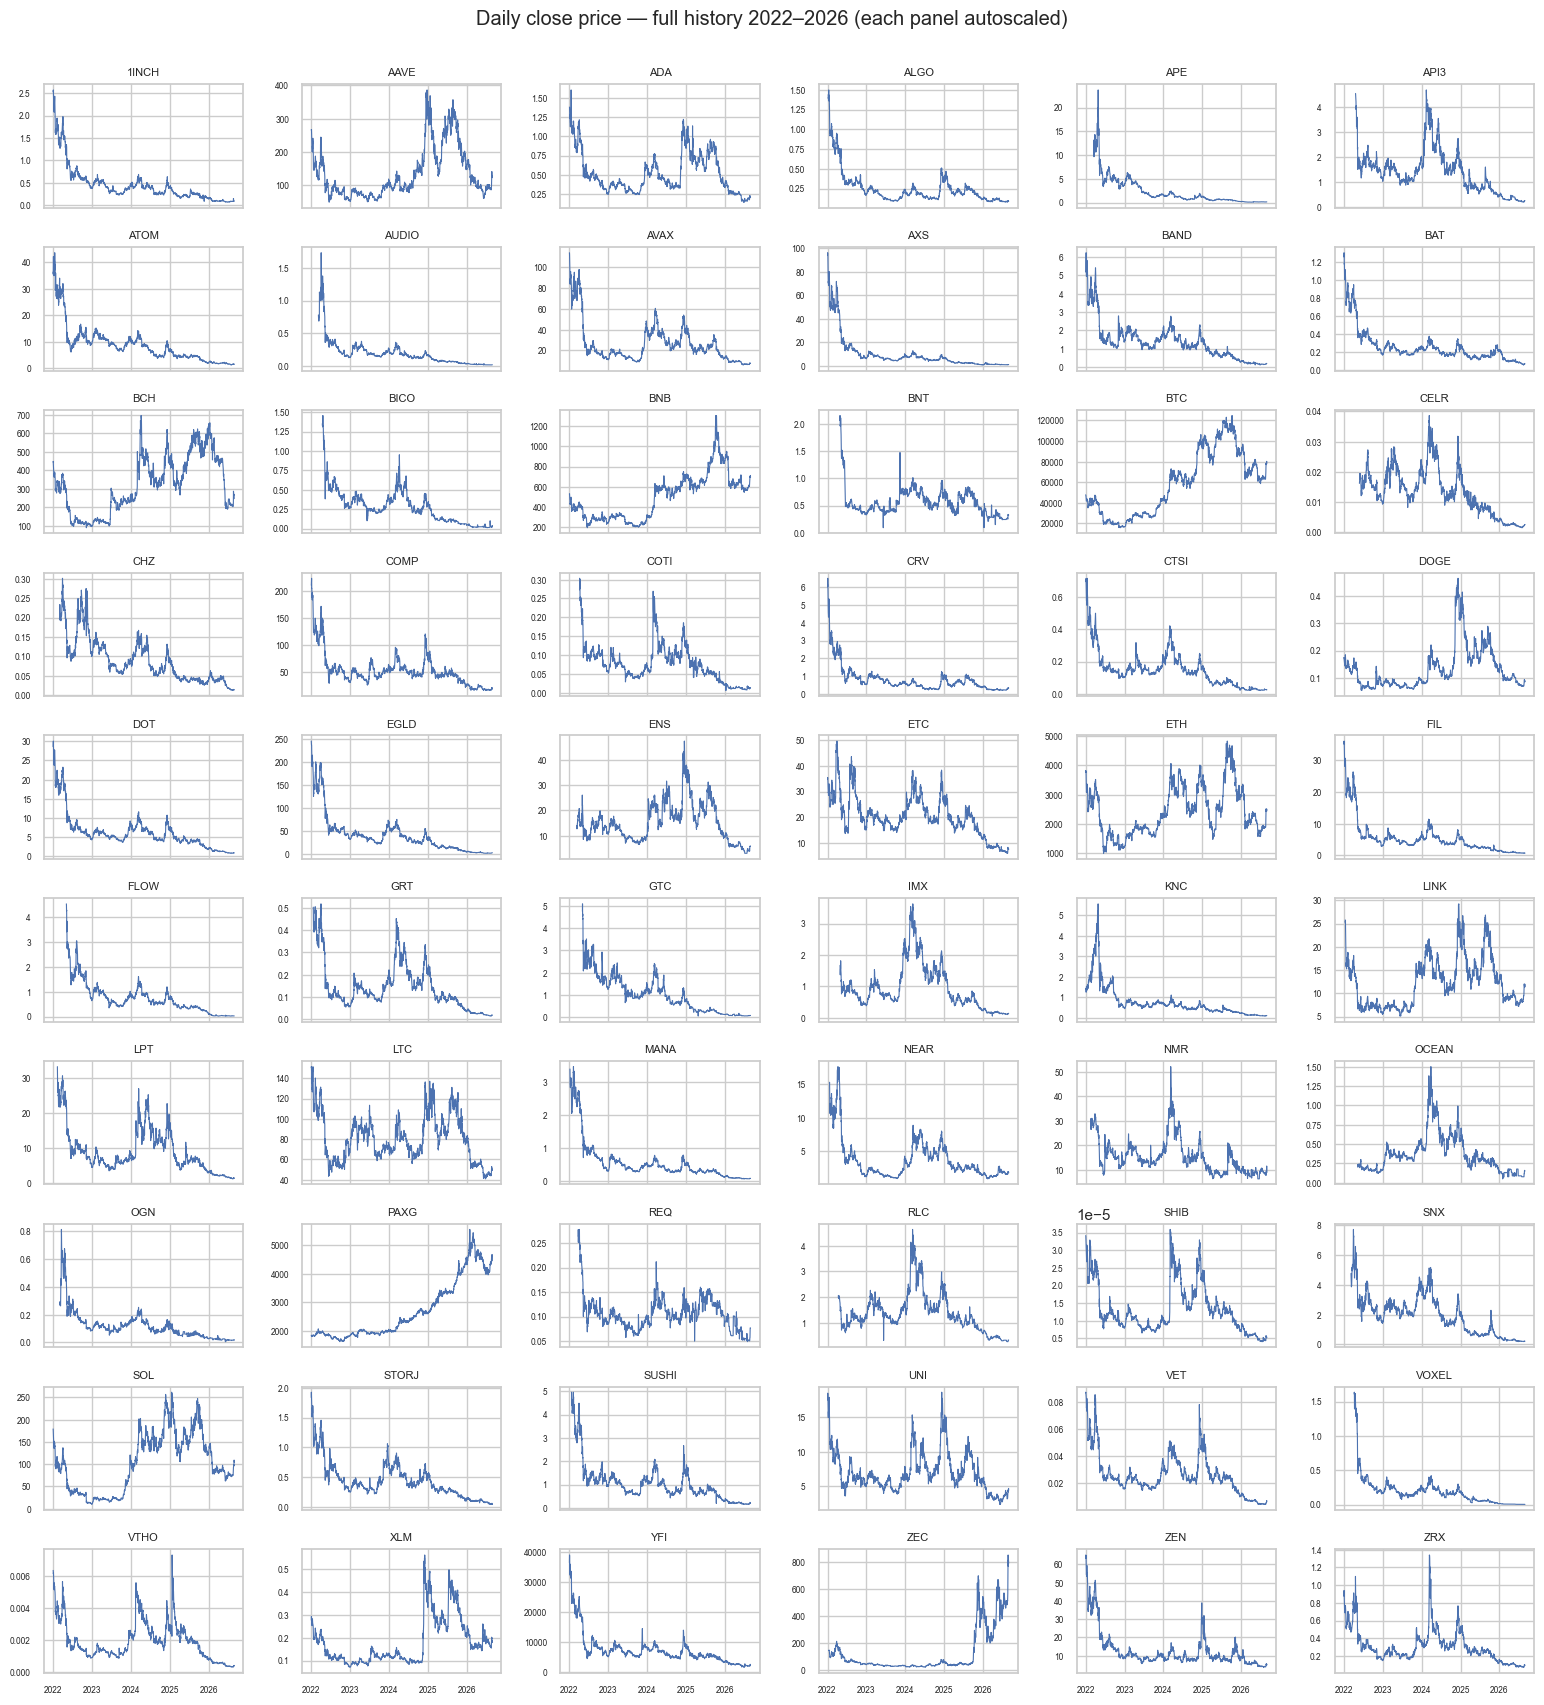

In [6]:
# --- Raw daily close price, full history, one panel per coin ---
# Own y-axis per panel: prices span BTC ~1e5 down to SHIB ~1e-5, so a shared axis is useless.
cols = list(dclose.columns)
ncol = 6
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.6, nrow * 1.7), sharex=True)
for ax, c in zip(axes.flat, cols):
    ax.plot(dclose.index, dclose[c], lw=0.8)
    ax.set_title(c.replace('USDT', ''), fontsize=8)
    ax.tick_params(labelsize=6)
for ax in axes.flat[len(cols):]:
    ax.axis('off')
fig.suptitle('Daily close price — full history 2022–2026 (each panel autoscaled)', y=1.002)
fig.tight_layout()
plt.show()

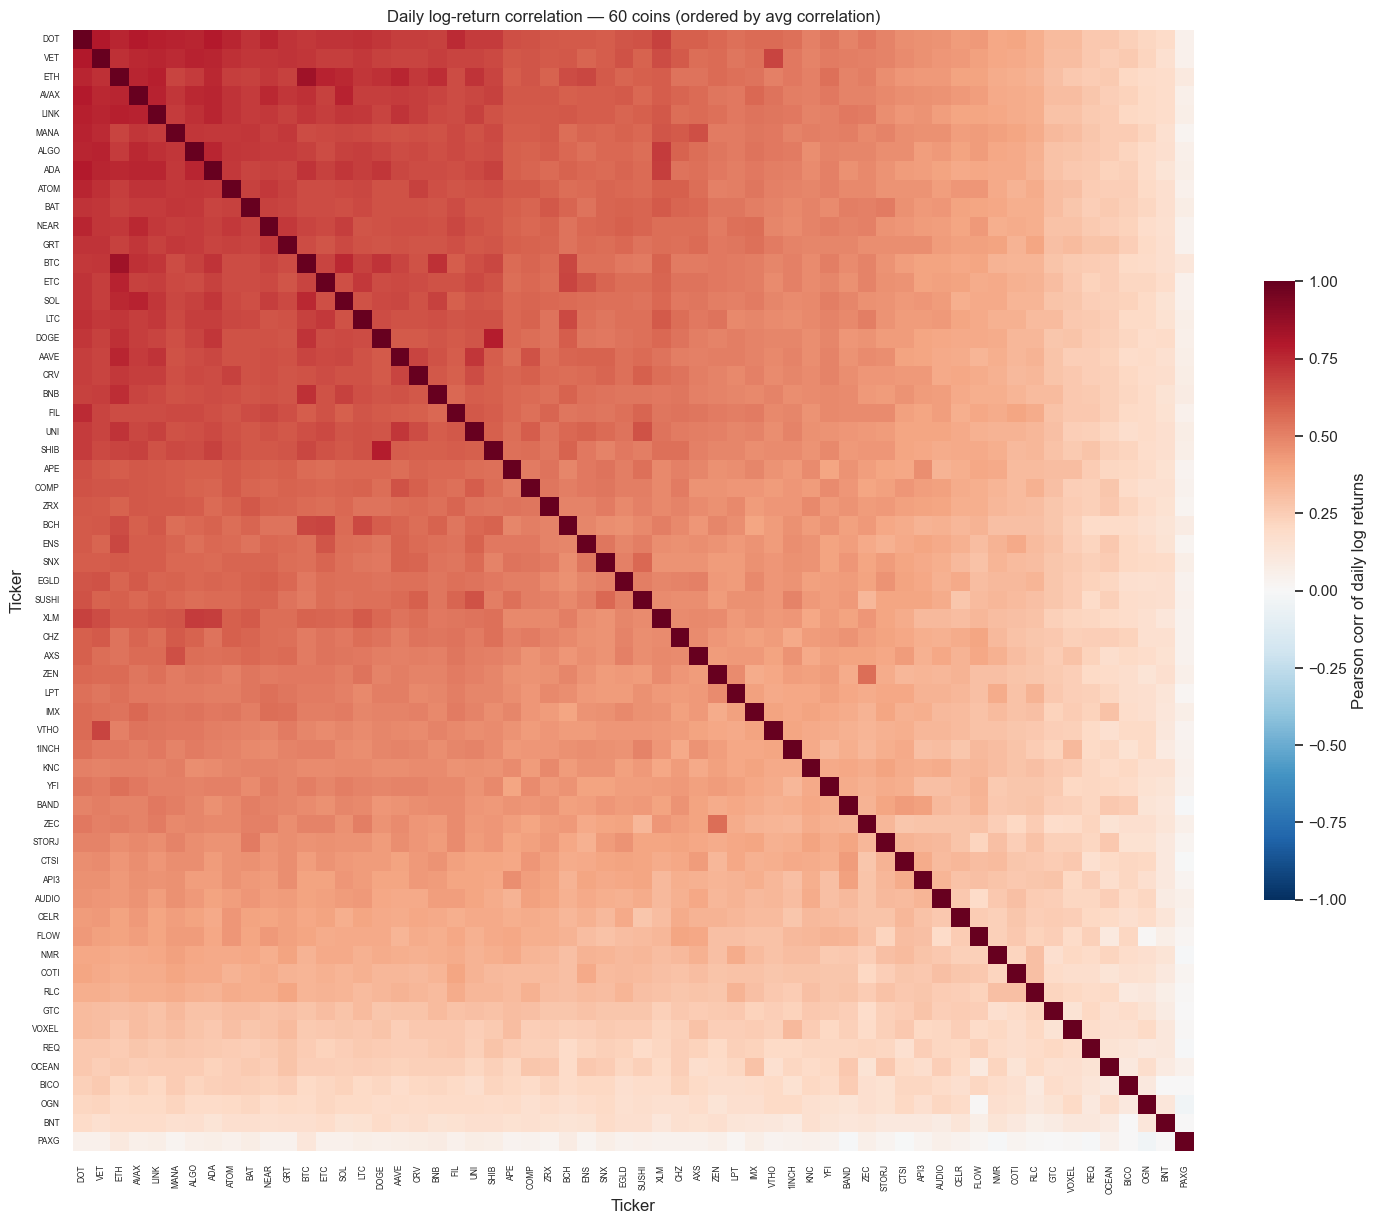

mean pairwise corr = 0.421 | min = -0.035 | max = 0.846


In [7]:
# --- Correlation matrix of daily log returns across all 60 coins ---
corr = logret.corr()
# order by average correlation so the tightly-coupled majors cluster into a visible block
order = corr.mean().sort_values(ascending=False).index
corr = corr.loc[order, order]
labels = [c.replace('USDT', '') for c in corr.columns]

fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, cmap='RdBu_r', vmin=-1, vmax=1, center=0, square=True,
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Pearson corr of daily log returns', 'shrink': 0.5}, ax=ax)
ax.set_title('Daily log-return correlation — 60 coins (ordered by avg correlation)')
ax.tick_params(labelsize=6)
fig.tight_layout()
plt.show()

offdiag = corr.values[np.triu_indices_from(corr, k=1)]
print(f'mean pairwise corr = {offdiag.mean():.3f} | min = {offdiag.min():.3f} | max = {offdiag.max():.3f}')

### Detrended (BTC-beta-neutral) price series

The heatmap above is dominated by one thing: everything loads on BTC. To see what each coin does *on
its own*, fit a **separate** regression per coin over 2023+ and subtract that coin's own BTC exposure:

$$r_{i,t} = \beta_i\, r_{\text{BTC},t} + \varepsilon_{i,t}
\qquad\Longrightarrow\qquad \text{detrended}_i(T) = \sum_{t \le T} \varepsilon_{i,t}$$

Every coin gets **its own** $\beta_i$ (they range ≈ 0.07 to 1.45) — not one global coefficient.

**The intercept is deliberately left in.** Removing the full OLS residual would force every curve flat
around zero *by construction* and the plot would carry no information. Keeping α means the **slope of
each curve is that coin's alpha versus BTC**, which is the reason to draw it at all.

Read it as: **down = lost to BTC after adjusting for how much BTC risk the coin carries.** Coins marked
**(stale)** have >20% of days with an exactly-zero return (stale/illiquid), so their residuals are unreliable —
staleness correlates ≈ 0.8 with the real order-book spread measured further below.

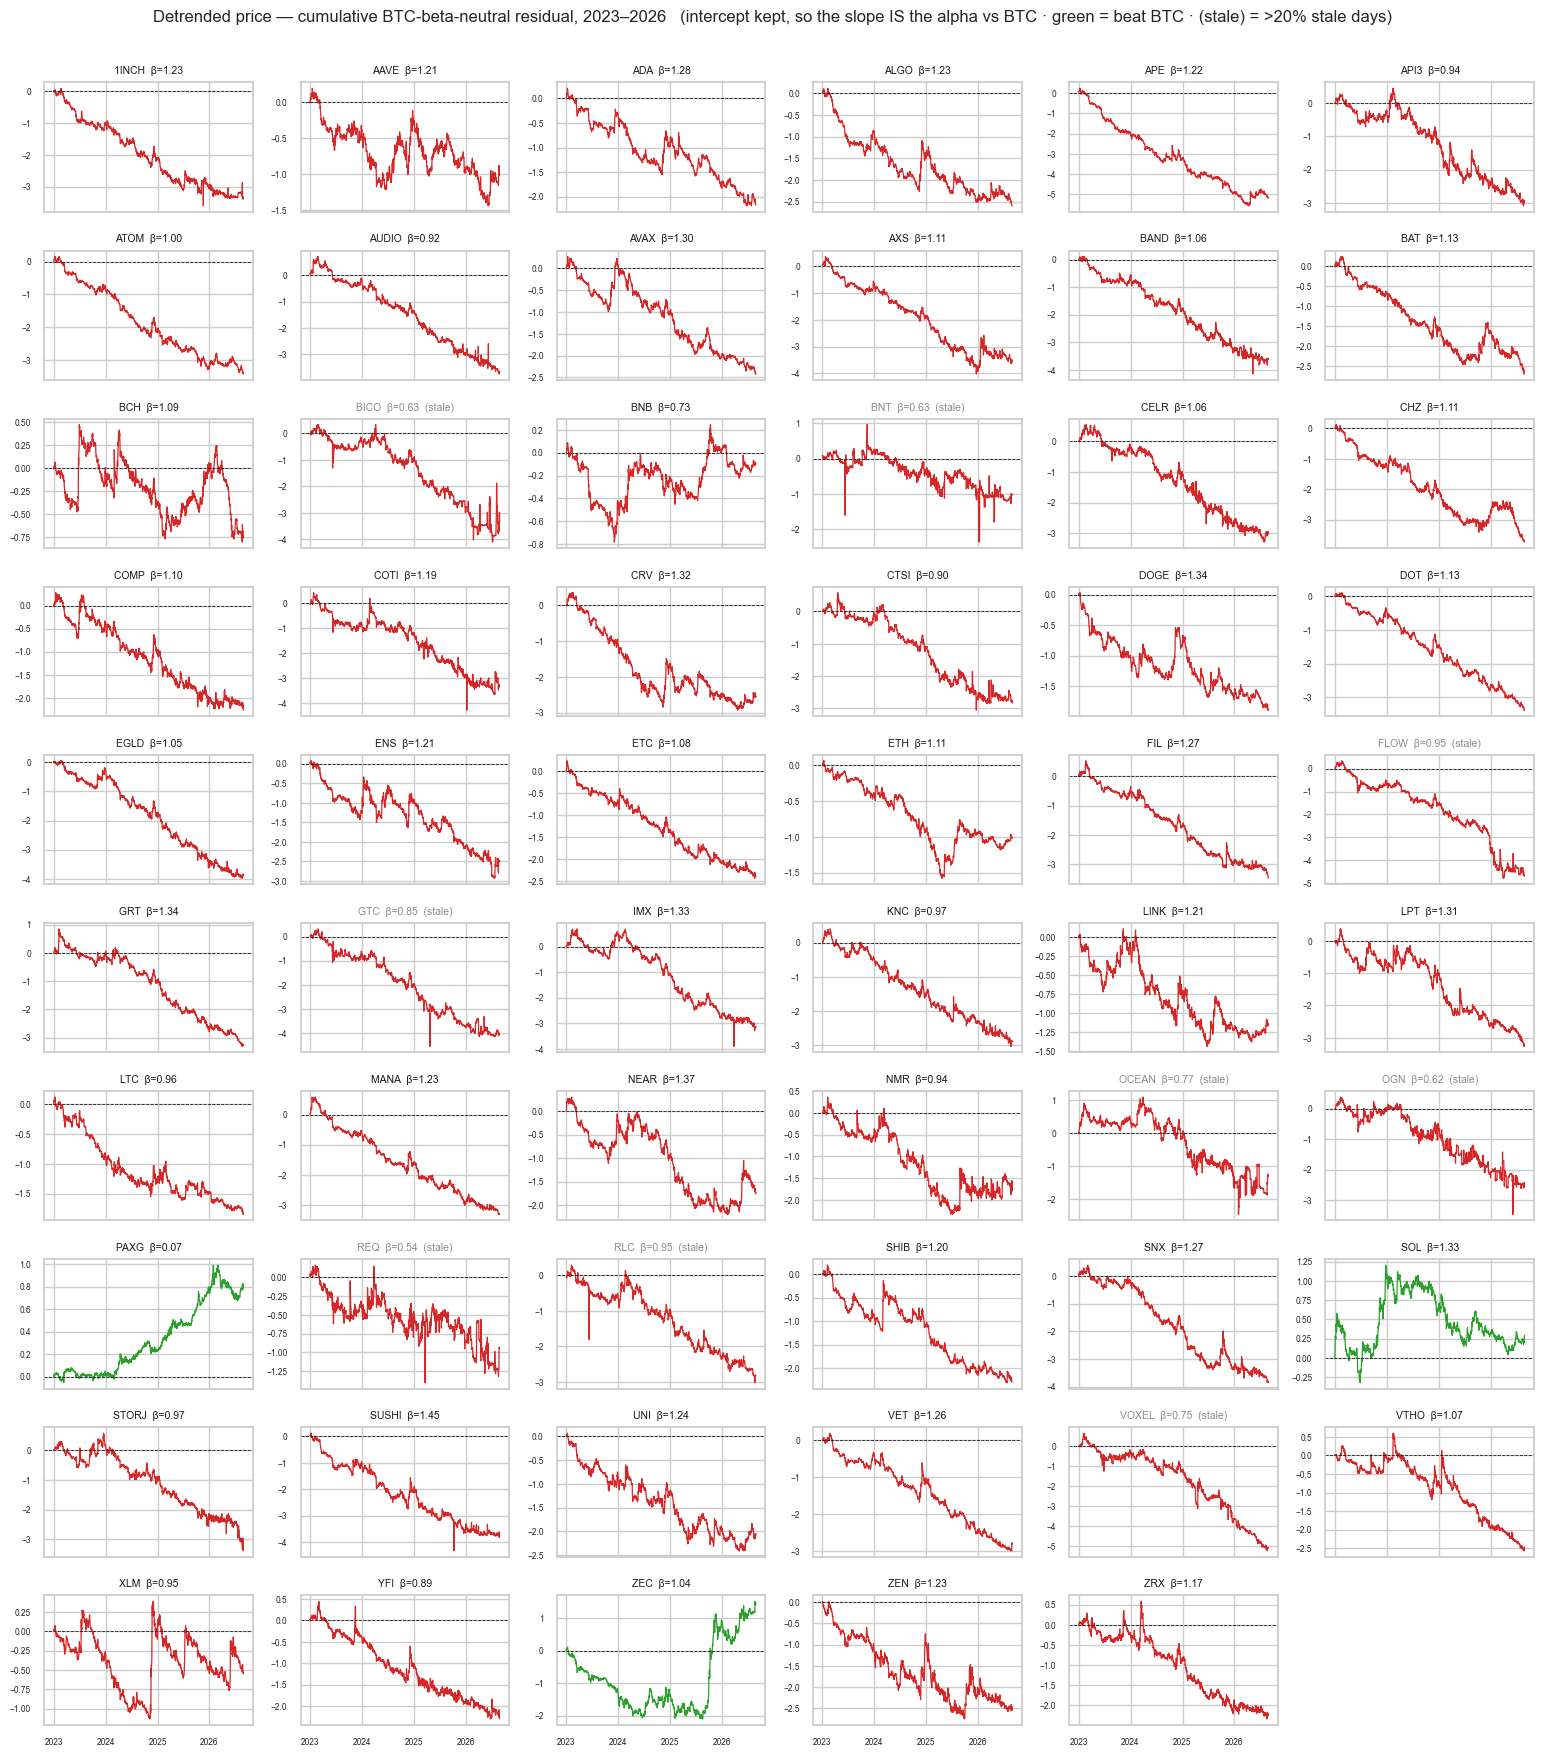

beta to BTC: median 1.11 (min 0.07 PAXG, max 1.45 SUSHI) | R^2 median 0.23
cumulative residual NEGATIVE for 56 of 59 coins | median alpha vs BTC = -0.71/yr in log terms
alpha significant: 13 negative, 0 positive (t > |1.96|) -- individually noisy, and the coins are far from independent, so read the cross-sectional consistency as one regime observation, not 59 votes


,beta,alpha_ann,t_alpha,r2,stale_%
ZECUSDT,1.0450,0.3920,0.7440,0.1870,0.9730
PAXGUSDT,0.0750,0.2130,1.5830,0.0180,6.7370
SOLUSDT,1.3310,0.0790,0.2630,0.5360,0.1500
BNBUSDT,0.7310,-0.0270,-0.1370,0.4500,0.1500
XLMUSDT,0.9490,-0.1500,-0.4010,0.2730,0.9730
BCHUSDT,1.0920,-0.2070,-0.6150,0.3810,0.2990
REQUSDT,0.5420,-0.2540,-0.3850,0.0380,31.1380
BNTUSDT,0.6250,-0.2760,-0.2350,0.0160,33.0090


In [8]:
# --- Detrended price series: cumulative BTC-beta-neutral residual, per coin, 2023 -> 2026 ---
import matplotlib.dates as mdates

DT_START = '2023-01-01'
R_dt  = logret.loc[DT_START:]                       # daily log returns, 2023 onward
btc   = R_dt['BTCUSDT']
stale = (R_dt == 0).mean()                          # frac of days with an exactly-zero return

fit = {}
for c in R_dt.columns:
    if c == 'BTCUSDT':                              # the factor itself has no residual
        continue
    d = pd.concat([R_dt[c], btc], axis=1).dropna()
    f = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1])).fit()
    fit[c] = {'beta': f.params.iloc[1], 'alpha_ann': f.params.iloc[0] * 365, 't_alpha': f.tvalues.iloc[0],
              'r2': f.rsquared, 'stale_%': stale[c] * 100}
fit = pd.DataFrame(fit).T
detrended = pd.DataFrame({c: R_dt[c] - fit.loc[c, 'beta'] * btc for c in fit.index}).cumsum()

cols = list(detrended.columns)
ncol = 6
nrow = int(np.ceil(len(cols) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(ncol * 2.6, nrow * 1.75), sharex=True)
for ax, c in zip(axes.flat, cols):
    s = detrended[c].dropna()
    flag = fit.loc[c, 'stale_%'] > 20
    ax.plot(s.index, s, lw=0.9, color=('tab:green' if s.iloc[-1] > 0 else 'tab:red'))
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_title(f"{c[:-4]}  β={fit.loc[c, 'beta']:.2f}" + ('  (stale)' if flag else ''),
                 fontsize=7.5, color=('0.55' if flag else 'k'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(labelsize=6)
for ax in axes.flat[len(cols):]:
    ax.axis('off')
fig.suptitle('Detrended price — cumulative BTC-beta-neutral residual, 2023–2026   '
             '(intercept kept, so the slope IS the alpha vs BTC · green = beat BTC · (stale) = >20% stale days)',
             y=1.003, fontsize=12)
fig.tight_layout(); plt.show()

print(f"beta to BTC: median {fit.beta.median():.2f} "
      f"(min {fit.beta.min():.2f} {fit.beta.idxmin()[:-4]}, max {fit.beta.max():.2f} {fit.beta.idxmax()[:-4]}) "
      f"| R^2 median {fit.r2.median():.2f}")
print(f"cumulative residual NEGATIVE for {int((fit.alpha_ann < 0).sum())} of {len(fit)} coins "
      f"| median alpha vs BTC = {fit.alpha_ann.median():.2f}/yr in log terms")
print(f"alpha significant: {int((fit.t_alpha < -1.96).sum())} negative, {int((fit.t_alpha > 1.96).sum())} positive "
      f"(t > |1.96|) -- individually noisy, and the coins are far from independent, so read the "
      f"cross-sectional consistency as one regime observation, not 59 votes")
display(fit.sort_values('alpha_ann', ascending=False).head(8).round(3))

## Intraday seasonality via GAM (Härdle et al., "Rise of the Machines")

Reproducing the paper's intraday high-frequency visuals on our **hourly** data (theirs was 5-min),
for the majors **BTC, ETH, XRP, SOL, LTC**. A Generalized Additive Model smooths a noisy quantity
against a *time coordinate*:

- **Absolute returns** vs hour-of-day and vs weekday — 1D cubic-spline smooths with CI bands (paper Figs 7–8).
- **Trading volume** as a 2D **surface** over (hour-of-day × weekday) — tensor-product smooth (paper Fig 9).
- **Volatility** (Parkinson high–low range) as the same 2D surface (paper Fig 10).

The paper's thesis: if trading were purely algorithmic/24-7, these surfaces would be flat. The humps
at working hours / weekdays are the "proof of human." Times here are **UTC** (the paper used +1 GMT).
Requires `pygam` (`pip install pygam`); **XRP** is loaded from a side file since it's not in the main panel.

{'BTC': 40811, 'ETH': 40811, 'XRP': 27392, 'SOL': 40811, 'LTC': 40811} hourly rows per coin


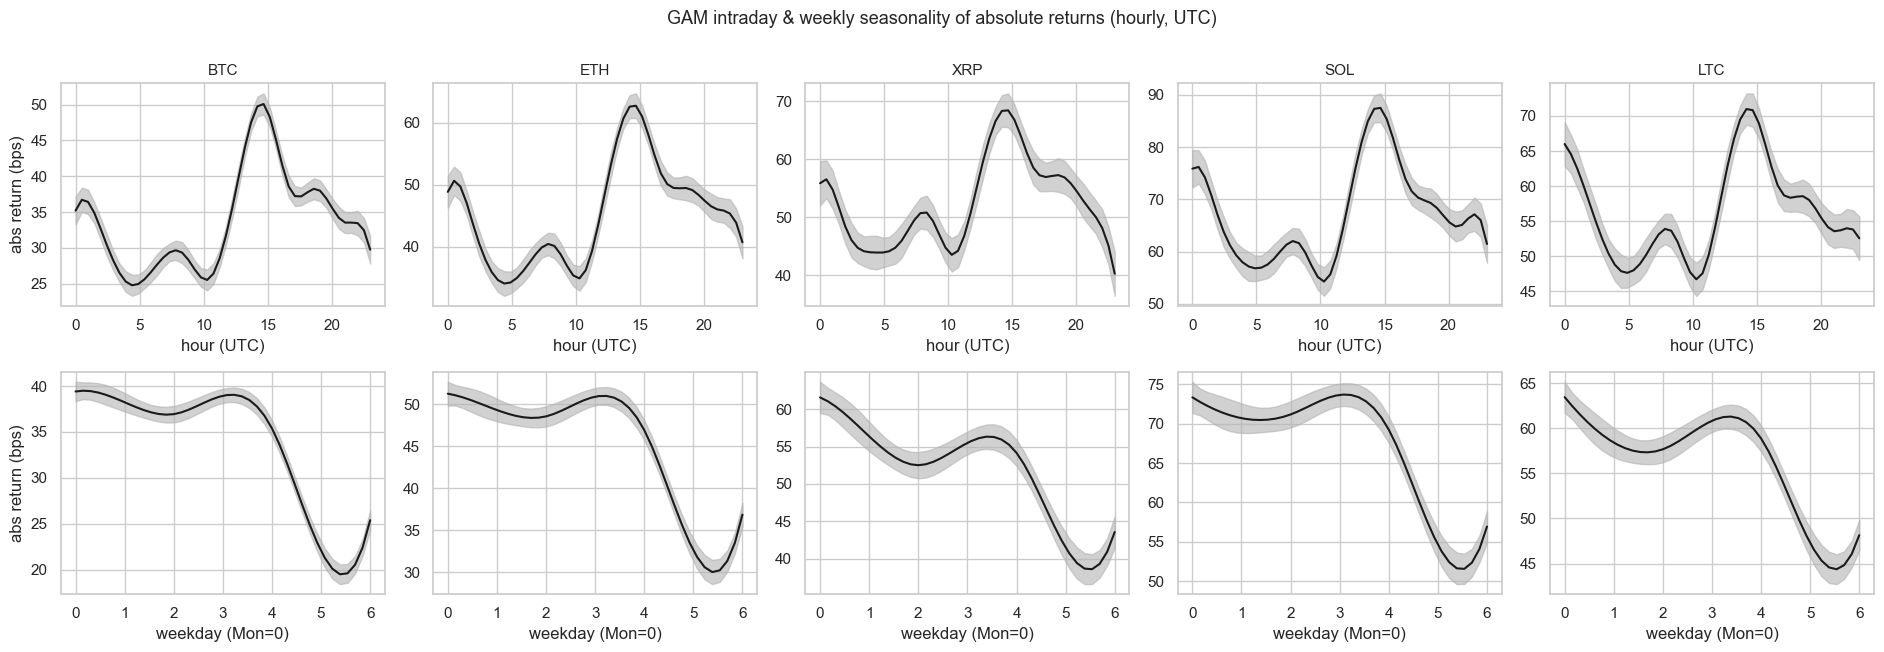

In [9]:
# --- GAM setup: per-coin hourly frame (returns / Parkinson vol / volume, hour, weekday) ---
import warnings; warnings.filterwarnings('ignore')
from pygam import LinearGAM, s, te
from matplotlib import cm

panel = pd.read_pickle(DATA_DIR / 'binance_us_hourly_ohlcv.pk')
GAM_COINS = ['BTC', 'ETH', 'XRP', 'SOL', 'LTC']

def coin_frame(tk):
    """Hourly OHLCV -> abs return, Parkinson range-vol, volume, plus hour & weekday coords."""
    d = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk') if tk == 'XRP'
         else panel.xs(tk + 'USDT', axis=1, level='Ticker')[['Open','High','Low','Close','Volume']])
    d = d.dropna(subset=['Close'])
    f = pd.DataFrame(index=d.index)
    f['abs_ret'] = np.log(d.Close).diff().abs()
    f['parkvol'] = np.sqrt((np.log(d.High / d.Low) ** 2) / (4 * np.log(2)))   # Parkinson HL vol
    f['volume']  = d.Volume
    f['hour']    = d.index.hour
    f['wday']    = d.index.dayofweek                                          # Mon=0 .. Sun=6
    return f.dropna()

gam_frames = {c: coin_frame(c) for c in GAM_COINS}
print({c: gam_frames[c].shape[0] for c in GAM_COINS}, 'hourly rows per coin')

# --- Fig 7/8: daily & weekly GAM seasonality of ABSOLUTE RETURNS (with CI bands) ---
fig, axes = plt.subplots(2, 5, figsize=(19, 6.5))
for j, c in enumerate(GAM_COINS):
    f = gam_frames[c]
    g = LinearGAM(s(0, n_splines=14)).fit(f[['hour']].values, f['abs_ret'].values * 1e4)
    xx = g.generate_X_grid(term=0, n=48); ci = g.confidence_intervals(xx)
    ax = axes[0, j]; ax.plot(xx[:, 0], g.predict(xx), 'k')
    ax.fill_between(xx[:, 0], ci[:, 0], ci[:, 1], color='0.7', alpha=.6)
    ax.set_title(c, fontsize=11); ax.set_xlabel('hour (UTC)')
    if j == 0: ax.set_ylabel('abs return (bps)')
    g2 = LinearGAM(s(0, n_splines=6)).fit(f[['wday']].values, f['abs_ret'].values * 1e4)
    xw = g2.generate_X_grid(term=0, n=40); cw = g2.confidence_intervals(xw)
    ax = axes[1, j]; ax.plot(xw[:, 0], g2.predict(xw), 'k')
    ax.fill_between(xw[:, 0], cw[:, 0], cw[:, 1], color='0.7', alpha=.6)
    ax.set_xlabel('weekday (Mon=0)'); ax.set_xticks(range(7))
    if j == 0: ax.set_ylabel('abs return (bps)')
fig.suptitle('GAM intraday & weekly seasonality of absolute returns (hourly, UTC)', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

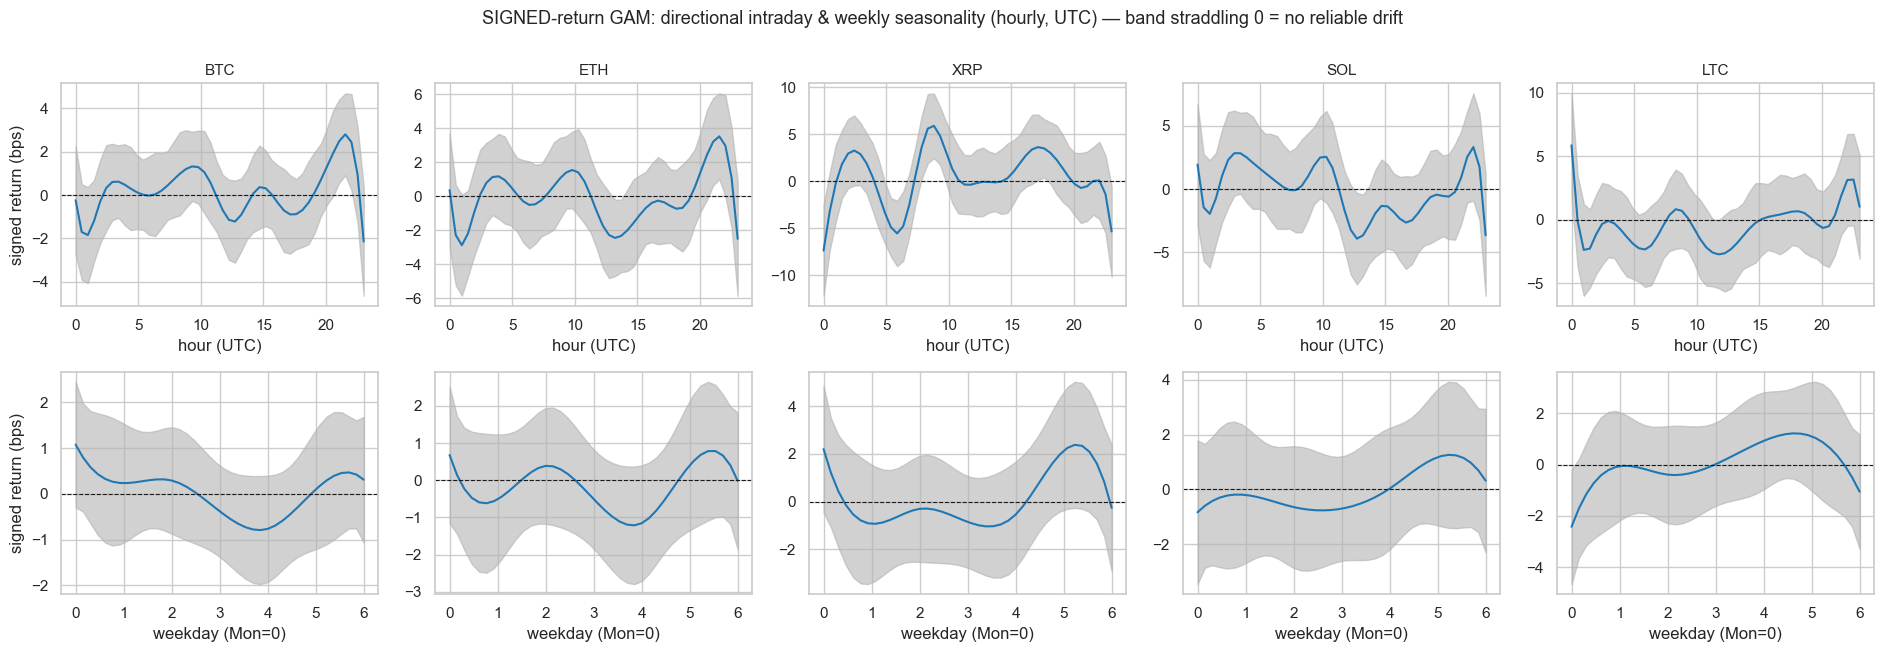

In [10]:
# --- Companion: SIGNED-return GAM (directional seasonality; unlike |ret|, this can cross zero) ---
# Same smooths, but on the raw signed log return: hours/days where the curve sits away from 0 with a
# CI that excludes 0 are a tradeable directional drift; where the band straddles 0 it's just noise.
def signed_frame(tk):
    d = (pd.read_pickle(DATA_DIR / 'xrp_hourly.pk') if tk == 'XRP'
         else panel.xs(tk + 'USDT', axis=1, level='Ticker')[['Close']])
    d = d.dropna(subset=['Close'])
    f = pd.DataFrame(index=d.index)
    f['ret']  = np.log(d.Close).diff()
    f['hour'] = d.index.hour
    f['wday'] = d.index.dayofweek
    return f.dropna()

signed_frames = {c: signed_frame(c) for c in GAM_COINS}

fig, axes = plt.subplots(2, 5, figsize=(19, 6.5))
for j, c in enumerate(GAM_COINS):
    f = signed_frames[c]
    g = LinearGAM(s(0, n_splines=14)).fit(f[['hour']].values, f['ret'].values * 1e4)
    xx = g.generate_X_grid(term=0, n=48); ci = g.confidence_intervals(xx)
    ax = axes[0, j]; ax.plot(xx[:, 0], g.predict(xx), 'tab:blue')
    ax.fill_between(xx[:, 0], ci[:, 0], ci[:, 1], color='0.7', alpha=.6)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_title(c, fontsize=11); ax.set_xlabel('hour (UTC)')
    if j == 0: ax.set_ylabel('signed return (bps)')
    g2 = LinearGAM(s(0, n_splines=6)).fit(f[['wday']].values, f['ret'].values * 1e4)
    xw = g2.generate_X_grid(term=0, n=40); cw = g2.confidence_intervals(xw)
    ax = axes[1, j]; ax.plot(xw[:, 0], g2.predict(xw), 'tab:blue')
    ax.fill_between(xw[:, 0], cw[:, 0], cw[:, 1], color='0.7', alpha=.6)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xlabel('weekday (Mon=0)'); ax.set_xticks(range(7))
    if j == 0: ax.set_ylabel('signed return (bps)')
fig.suptitle('SIGNED-return GAM: directional intraday & weekly seasonality (hourly, UTC) — '
             'band straddling 0 = no reliable drift', y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

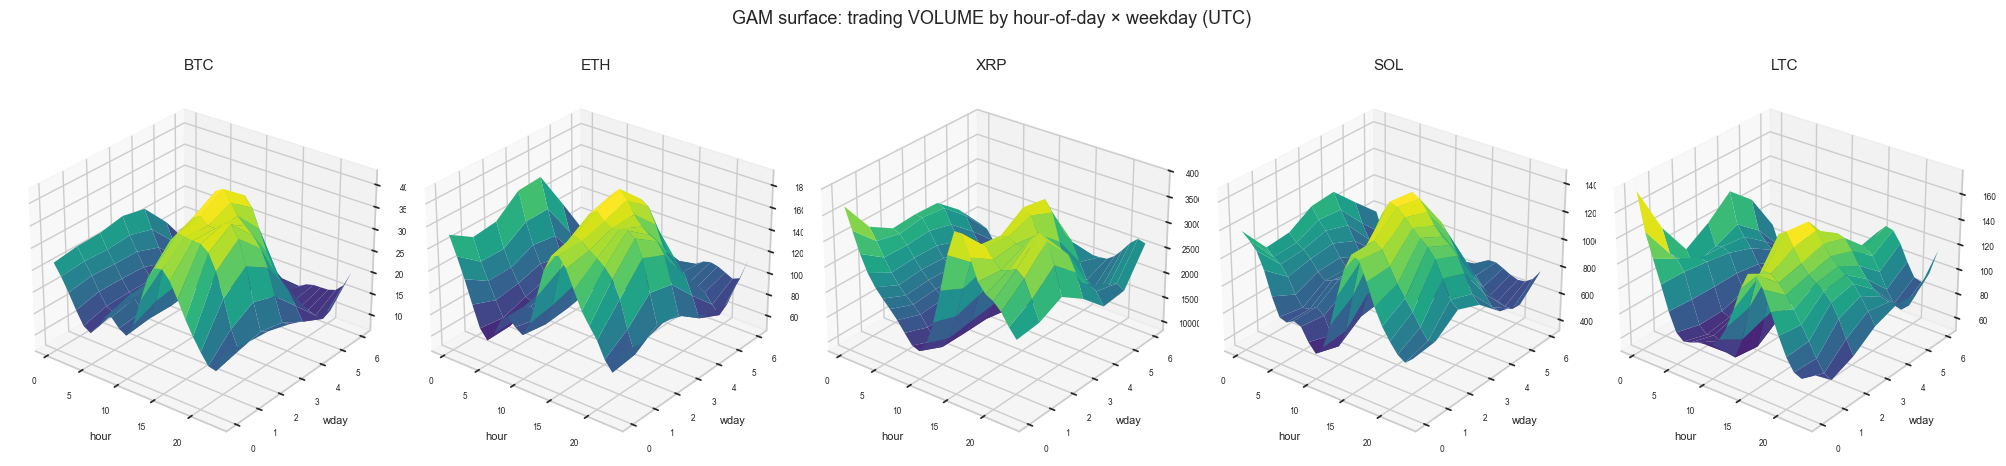

In [11]:
# --- Fig 9: trading VOLUME as a GAM surface over (hour-of-day x weekday) ---
Hgrid, Wgrid = np.meshgrid(np.linspace(0, 23, 24), np.linspace(0, 6, 7))

def gam_surface(field, scale, title):
    fig = plt.figure(figsize=(20, 4.6))
    for j, c in enumerate(GAM_COINS):
        f = gam_frames[c]
        g = LinearGAM(te(0, 1, n_splines=[12, 6])).fit(f[['hour', 'wday']].values, f[field].values * scale)
        Z = g.predict(np.c_[Hgrid.ravel(), Wgrid.ravel()]).reshape(Hgrid.shape)
        ax = fig.add_subplot(1, 5, j + 1, projection='3d')
        ax.plot_surface(Hgrid, Wgrid, Z, cmap=cm.viridis, antialiased=True, linewidth=0)
        ax.set_title(c, fontsize=11); ax.set_xlabel('hour', fontsize=8); ax.set_ylabel('wday', fontsize=8)
        ax.tick_params(labelsize=6); ax.view_init(elev=28, azim=-52)
    fig.suptitle(title, y=1.02, fontsize=13); fig.tight_layout(); plt.show()

gam_surface('volume', 1.0, 'GAM surface: trading VOLUME by hour-of-day × weekday (UTC)')

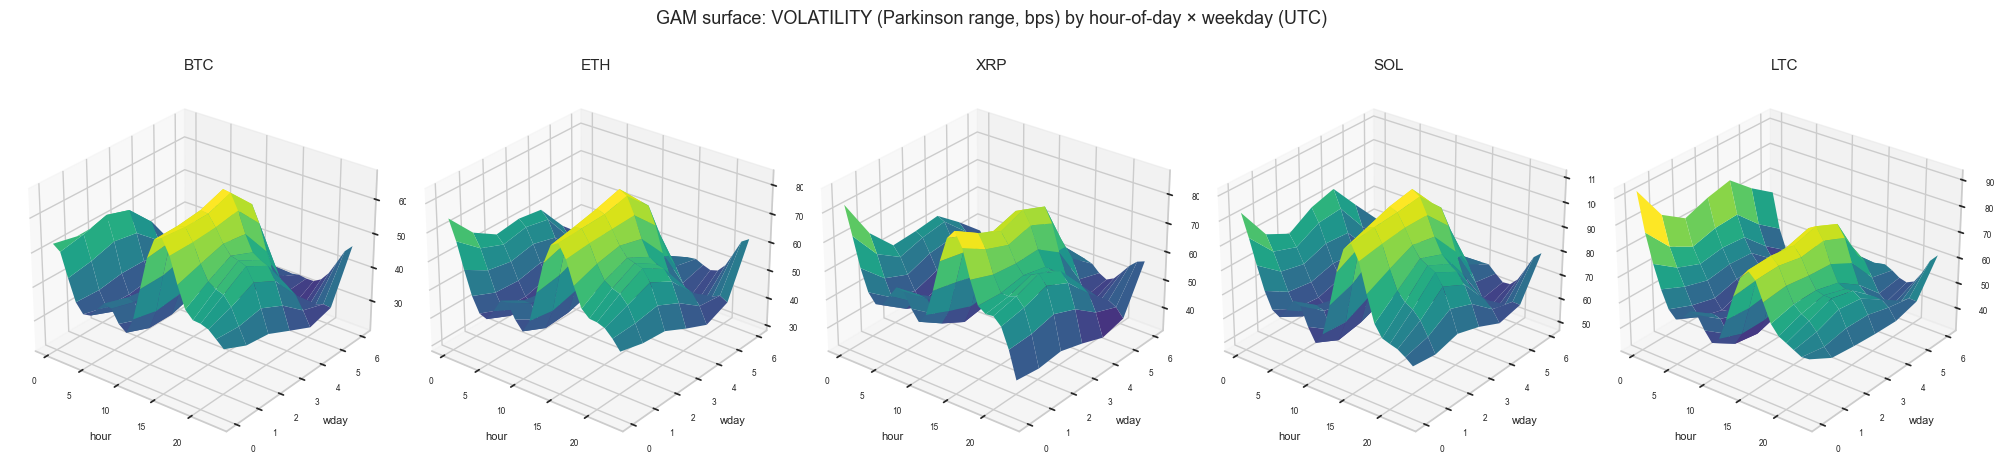

In [12]:
# --- Fig 10: VOLATILITY (Parkinson range) as a GAM surface over (hour-of-day x weekday) ---
gam_surface('parkvol', 1e4, 'GAM surface: VOLATILITY (Parkinson range, bps) by hour-of-day × weekday (UTC)')

## Real order-book spread & illiquidity (Binance.US quotes)

The klines carry no bid/ask, so we poll `get_orderbook_tickers()` for the **real** best bid/ask and
compute the true spread `(ask − bid)/mid`, plus **top-of-book depth** (`bid$`, `ask$`) as a second
illiquidity axis. Snapshots accumulate in `data/orderbook_spread_snapshots.csv` via
`collect_spreads.py` (a cron job polls every 15 min).

**Why real quotes, not an estimator:** OHLC-based spread estimators fail badly here. Corwin-Schultz and
Abdi-Ranaldo both correlate **≈ −0.19** with the real spread — they *overstate* liquid coins (their
high-low range is dominated by volatility) and *understate* dead coins (whose range collapses because
nothing trades). Reality: BTC/SOL/ETH ≈ **2 bps**, while dead microcaps run **hundreds to thousands** of bps.

**Limitation:** Binance has no free historical order book, so this is **live/forward** data — it measures
*current* tradability, not the 2022–2026 backtest window. Run the collector for a while to build real
intraday spread history.

In [13]:
# --- Real order-book spread & depth per coin (from accumulated snapshots; live fallback) ---
_snap = DATA_DIR / 'orderbook_spread_snapshots.csv'
if _snap.exists():
    snaps = pd.read_csv(_snap)
else:                                                    # fallback: one live snapshot
    from binance.client import Client
    snaps = pd.DataFrame(Client(tld='US').get_orderbook_tickers())
    snaps = snaps[snaps.symbol.str.endswith('USDT')].astype(
        {'bidPrice': float, 'askPrice': float, 'bidQty': float, 'askQty': float})
    snaps['mid'] = (snaps.bidPrice + snaps.askPrice) / 2
    snaps = snaps[snaps.mid > 0]
    snaps['spread_bps'] = (snaps.askPrice - snaps.bidPrice) / snaps.mid * 1e4
    snaps['bid_usd'] = snaps.bidPrice * snaps.bidQty
    snaps['ask_usd'] = snaps.askPrice * snaps.askQty

snaps = snaps[snaps.symbol.isin(logret.columns)]
g = snaps.groupby('symbol')
real = pd.DataFrame({'spread_bps': g['spread_bps'].median(),
                     'depth_usd':  (g['bid_usd'].median() + g['ask_usd'].median()) / 2})
real_spread = real['spread_bps'].copy()                  # per-symbol, for use as a cost input
real_spread.to_pickle(DATA_DIR / 'real_spread_bps.pk')
TRADEABLE = real_spread[real_spread < 10].index.tolist() # "cheap enough to trade" universe

n_snaps = snaps['ts_utc'].nunique() if 'ts_utc' in snaps else 1
real.index = [s[:-4] for s in real.index]
real = real.sort_values('spread_bps')
print(f'{n_snaps} snapshot(s), {len(real)} coins | median real spread = {real.spread_bps.median():.1f} bps')
print(f'tradeable (real spread < 10 bps): {len(TRADEABLE)} -> {sorted(s[:-4] for s in TRADEABLE)}')
display(real.round(1))

971 snapshot(s), 60 coins | median real spread = 85.0 bps
tradeable (real spread < 10 bps): 9 -> ['ADA', 'AVAX', 'BNB', 'BTC', 'DOGE', 'ETH', 'LTC', 'SOL', 'ZEC']


,spread_bps,depth_usd
BTC,0.5000,"1,472.3000"
ETH,0.7000,"1,753.1000"
SOL,1.9000,"1,500.0000"
BNB,3.2000,704.0000
DOGE,3.7000,"1,023.1000"
LTC,7.2000,893.8000
ADA,7.6000,500.0000
ZEC,8.0000,448.5000
AVAX,8.7000,124.8000
LINK,10.6000,199.9000


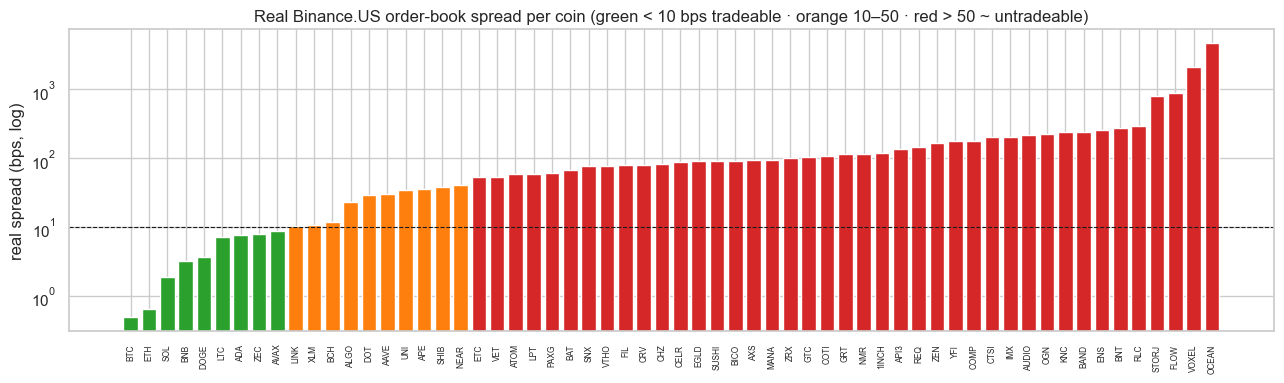

spread bands: <10bps 9 coins | 10-50bps 10 | >50bps 41 coins
=> only a handful are genuinely liquid on Binance.US; most of the 60 are costly-to-untradeable.


In [14]:
# --- Picture: real spread per coin (log), tradeable band highlighted ---
rs = real['spread_bps'].sort_values()
colors = ['tab:green' if v < 10 else ('tab:orange' if v < 50 else 'tab:red') for v in rs.values]
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(range(len(rs)), rs.values, color=colors)
ax.set_yscale('log'); ax.axhline(10, color='k', ls='--', lw=0.8)
ax.set_xticks(range(len(rs))); ax.set_xticklabels(rs.index, rotation=90, fontsize=6)
ax.set_ylabel('real spread (bps, log)')
ax.set_title('Real Binance.US order-book spread per coin '
             '(green < 10 bps tradeable · orange 10–50 · red > 50 ~ untradeable)')
fig.tight_layout(); plt.show()
print(f'spread bands: <10bps {int((rs<10).sum())} coins | 10-50bps {int(((rs>=10)&(rs<50)).sum())} | '
      f'>50bps {int((rs>=50).sum())} coins')
print('=> only a handful are genuinely liquid on Binance.US; most of the 60 are costly-to-untradeable.')

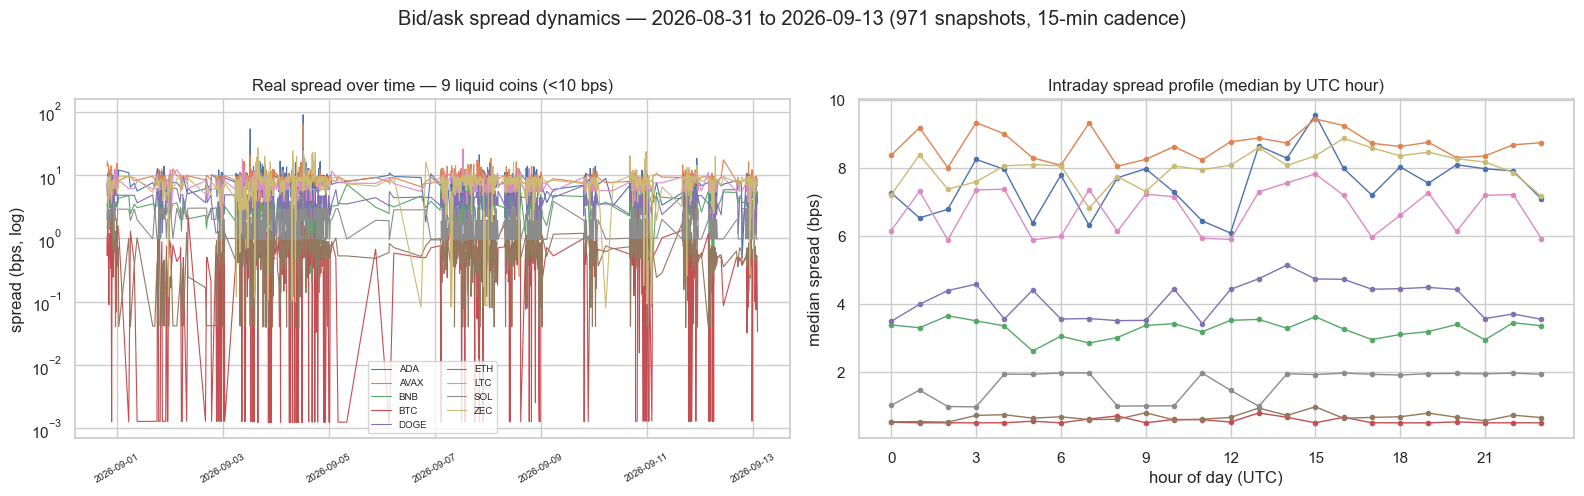

In [15]:
# --- Bid/ask spread OVER TIME: intraday dynamics from the accumulated snapshots ---
snaps_t = pd.read_csv(DATA_DIR / 'orderbook_spread_snapshots.csv', parse_dates=['ts_utc'])
snaps_t = snaps_t[snaps_t.symbol.isin(logret.columns)]
liquid  = real_spread[real_spread < 10].index.tolist()          # tradeable coins (from the loader above)
wide    = snaps_t.pivot_table(index='ts_utc', columns='symbol', values='spread_bps')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4.8))
# (left) spread time series for the liquid coins
for s in liquid:
    ax1.plot(wide.index, wide[s], lw=0.8, label=s[:-4])
ax1.set_yscale('log'); ax1.set_ylabel('spread (bps, log)')
ax1.set_title(f'Real spread over time — {len(liquid)} liquid coins (<10 bps)')
ax1.legend(ncol=2, fontsize=7); ax1.tick_params(axis='x', labelrotation=30, labelsize=7)
# (right) intraday profile: median spread by UTC hour (robust to the short sample)
byhour = (snaps_t.assign(hour=snaps_t.ts_utc.dt.hour)
                 .groupby(['hour', 'symbol'])['spread_bps'].median().unstack())
for s in liquid:
    ax2.plot(byhour.index, byhour[s], marker='o', ms=3, lw=1, label=s[:-4])
ax2.set_xlabel('hour of day (UTC)'); ax2.set_ylabel('median spread (bps)')
ax2.set_title('Intraday spread profile (median by UTC hour)'); ax2.set_xticks(range(0, 24, 3))
fig.suptitle(f'Bid/ask spread dynamics — {snaps_t.ts_utc.min():%Y-%m-%d} to {snaps_t.ts_utc.max():%Y-%m-%d} '
             f'({snaps_t.ts_utc.nunique()} snapshots, 15-min cadence)', y=1.03)
fig.tight_layout(); plt.show()

## Volatility dynamics & distributions (10 most liquid coins, past year)

Everything above characterises *structure* (correlation, seasonality, spread). This section
characterises the **shape of the data itself** on the only universe we could actually trade — the
**10 tightest-spread coins** — over the most recent **12 months**.

- **Rolling realized volatility of 4-hour returns.** Resample the hourly panel to 4h bars, take log
  returns, and run a rolling `std` annualized by `√(365·24/4)`. 4h is the sweet spot here: hourly bars
  are contaminated by bid-ask bounce (see the reversal post-mortem in
  [`docs/strategy_log.md`](docs/strategy_log.md)), daily bars give too few observations per window.
- **Four distributions** — price, return, volatility, spread. What we want out of them:
  - *Price*: each coin normalized to its own year-start, so 5 orders of magnitude become comparable.
  - *Return*: how far from Gaussian? Excess kurtosis and tail frequency set the realistic bar for any
    risk model or vol-scaled position sizing.
  - *Volatility*: right-skewed in levels but near-normal in logs — the standard argument for modelling
    **log-vol**, and for why a vol forecast should be multiplicative, not additive.
  - *Spread*: the actual cost distribution we pay, not its median — the tail is what kills a strategy.

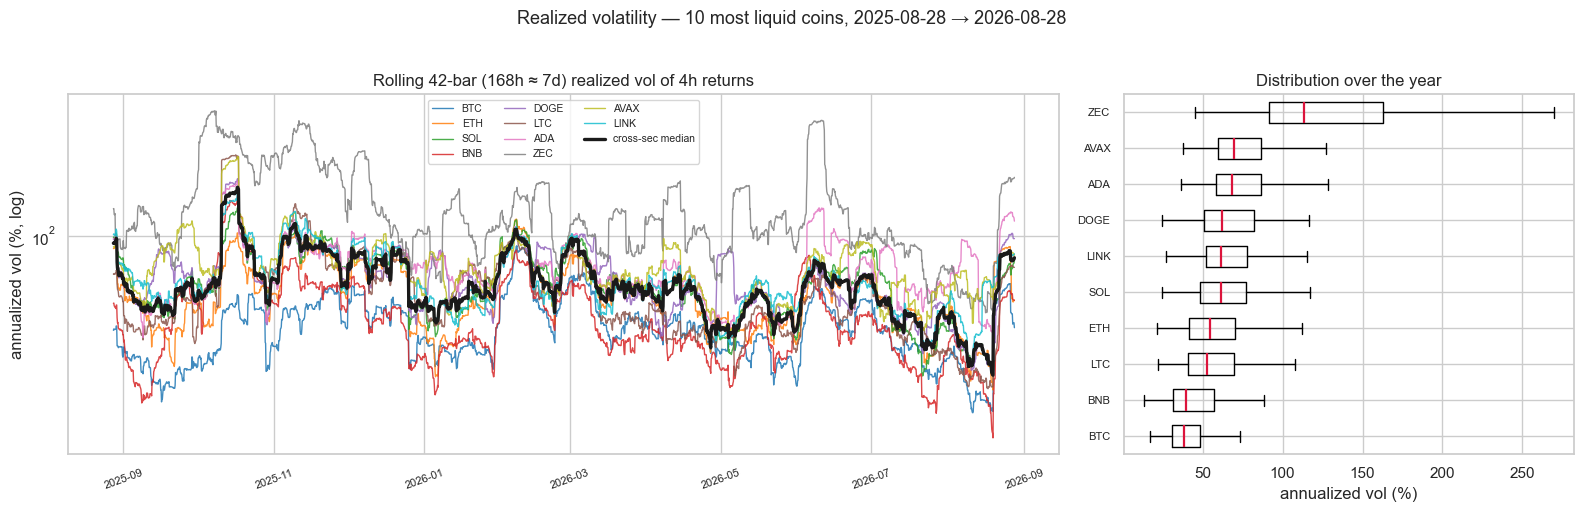

,median_vol_%,min_%,max_%,vol_of_vol,spread_bps
BTC,38.3500,17.1500,90.7400,0.3200,0.5000
BNB,39.4700,13.3500,147.6700,0.4600,3.2200
LTC,52.8000,21.8100,224.4900,0.5100,7.1900
ETH,54.3600,21.5400,118.3600,0.3300,0.6500
SOL,61.3600,24.7600,132.6100,0.3300,1.9300
LINK,61.4400,27.2100,152.6400,0.3200,10.5600
DOGE,62.0500,24.8800,177.1400,0.3500,3.6900
ADA,68.2600,36.3800,172.9000,0.3200,7.6200
AVAX,69.5200,37.5200,220.9600,0.3500,8.6800
ZEC,113.4700,45.3300,348.8000,0.4800,8.0100


avg pairwise correlation of the rolling vols = 0.69 => vol is largely a single common (market-wide) factor, not idiosyncratic.


In [16]:
# --- Rolling realized volatility of 4-HOUR returns, 10 most liquid coins, trailing 12 months ---
from scipy import stats

BAR, WIN = '4h', 42                       # 42 bars x 4h = 168h = 7 days of history per vol estimate
BARS_PER_YEAR = 365 * 24 / 4              # crypto trades 24/7, so no trading-day adjustment
LIQ10 = real_spread[real_spread.index.isin(close.columns)].sort_values().head(10).index.tolist()

px4  = close[LIQ10].resample(BAR).last()
r4   = np.log(px4).diff()
rvol = r4.rolling(WIN).std() * np.sqrt(BARS_PER_YEAR) * 100      # annualized vol in %

END   = r4.index.max().normalize()
START = END - pd.Timedelta(days=365)
rv, r4y = rvol.loc[START:END], r4.loc[START:END]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [2.2, 1]})
for col, c in zip(LIQ10, plt.cm.tab10(np.linspace(0, 1, 10))):
    ax1.plot(rv.index, rv[col], lw=1.0, color=c, alpha=.85, label=col[:-4])
ax1.plot(rv.index, rv.median(axis=1), color='k', lw=2.4, label='cross-sec median')
ax1.set_yscale('log'); ax1.set_ylabel('annualized vol (%, log)')
ax1.set_title(f'Rolling {WIN}-bar ({WIN * 4}h ≈ {WIN * 4 // 24}d) realized vol of {BAR} returns')
ax1.legend(ncol=3, fontsize=7.5); ax1.tick_params(axis='x', labelrotation=20, labelsize=8)

order = rv.median().sort_values().index                          # (right) same data as a distribution
ax2.boxplot([rv[c].dropna() for c in order], vert=False, widths=.6, showfliers=False,
            medianprops=dict(color='crimson', lw=1.6))
ax2.set_yticklabels([c[:-4] for c in order], fontsize=8)
ax2.set_xlabel('annualized vol (%)'); ax2.set_title('Distribution over the year')
fig.suptitle(f'Realized volatility — 10 most liquid coins, {START:%Y-%m-%d} → {END:%Y-%m-%d}',
             y=1.02, fontsize=13)
fig.tight_layout(); plt.show()

vsum = pd.DataFrame({'median_vol_%': rv.median(), 'min_%': rv.min(), 'max_%': rv.max(),
                     'vol_of_vol': rv.std() / rv.mean(), 'spread_bps': real_spread[LIQ10]})
vsum.index = [c[:-4] for c in vsum.index]
display(vsum.sort_values('median_vol_%').round(2))
_off = rv.corr().values[np.triu_indices(len(LIQ10), 1)]
print(f'avg pairwise correlation of the rolling vols = {_off.mean():.2f} '
      '=> vol is largely a single common (market-wide) factor, not idiosyncratic.')

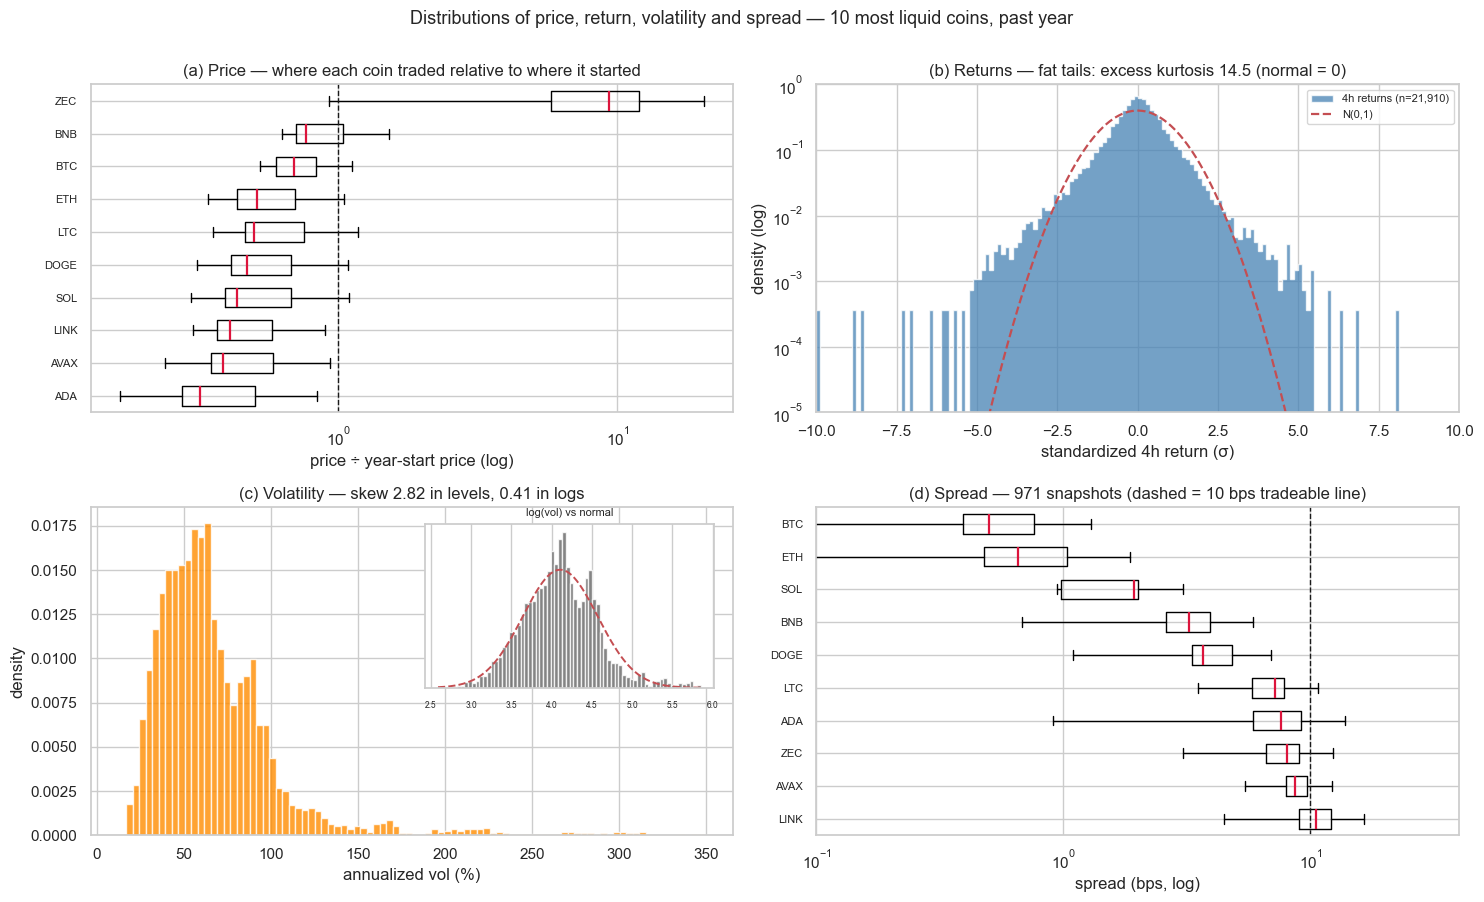

,mean_4h_bps,std_4h_bps,skew,excess_kurt,JB_p,worst_z
BTC,-1.5200,90.6000,-0.1500,4.5400,0.0000,-5.0800
ETH,-2.7100,128.4500,-0.2100,5.1600,0.0000,-6.4700
SOL,-2.9200,142.9900,-0.3500,3.9200,0.0000,-6.0000
BNB,-0.8700,107.0400,-0.8700,9.4700,0.0000,-9.9400
DOGE,-4.1600,150.2700,-0.8600,12.4400,0.0000,-11.9900
LTC,-3.7400,142.7300,-3.2400,60.5600,0.0000,-18.9100
ADA,-6.3700,164.1500,-0.6700,12.0400,0.0000,-11.5600
ZEC,13.3700,323.7200,0.5900,8.1900,0.0000,-8.5500
AVAX,-5.4500,167.7000,-1.4400,22.2600,0.0000,-14.4900
LINK,-3.2300,148.0700,-0.4500,6.2100,0.0000,-8.8700


pooled excess kurtosis 14.5 | |z| > 4 events: 129 (0.59% of bars, a normal predicts 0.006%)
=> Gaussian risk models understate crypto tail risk by ~100x; size positions on realized vol, and never trust a Sharpe computed as if returns were normal.


In [17]:
# --- Distributions: price, return, volatility, spread (same 10 coins, same 12 months) ---
snaps_d  = snaps_t[snaps_t.symbol.isin(LIQ10)]                      # order-book snapshots, liquid 10
px_norm  = px4.loc[START:END] / px4.loc[START:END].iloc[0]          # price relative to year-start

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# (a) PRICE — normalized to each coin's own year-start so 5 orders of magnitude are comparable
o = px_norm.median().sort_values().index
ax[0, 0].boxplot([px_norm[c].dropna() for c in o], vert=False, widths=.6, showfliers=False,
                 medianprops=dict(color='crimson', lw=1.6))
ax[0, 0].set_yticklabels([c[:-4] for c in o], fontsize=8)
ax[0, 0].axvline(1, color='k', ls='--', lw=1)
ax[0, 0].set_xscale('log'); ax[0, 0].set_xlabel('price ÷ year-start price (log)')
ax[0, 0].set_title('(a) Price — where each coin traded relative to where it started')

# (b) RETURNS — pooled 4h returns, standardized per coin, against the normal they are NOT
z = ((r4y - r4y.mean()) / r4y.std()).stack().dropna()
ax[0, 1].hist(z, bins=np.linspace(-10, 10, 161), density=True, histtype='stepfilled',
              color='steelblue', alpha=.75, label=f'4h returns (n={len(z):,})')
xx = np.linspace(-10, 10, 400)
ax[0, 1].plot(xx, stats.norm.pdf(xx), 'r--', lw=1.6, label='N(0,1)')
ax[0, 1].set_yscale('log'); ax[0, 1].set_xlim(-10, 10); ax[0, 1].set_ylim(1e-5, 1)
ax[0, 1].set_xlabel('standardized 4h return (σ)'); ax[0, 1].set_ylabel('density (log)')
ax[0, 1].set_title(f'(b) Returns — fat tails: excess kurtosis {stats.kurtosis(z):.1f} (normal = 0)')
ax[0, 1].legend(fontsize=8)

# (c) VOLATILITY — right-skewed in levels, near-normal in logs => model log-vol, not vol
v = rv.stack().dropna()
ax[1, 0].hist(v, bins=90, density=True, color='darkorange', alpha=.8)
ax[1, 0].set_xlabel('annualized vol (%)'); ax[1, 0].set_ylabel('density')
ax[1, 0].set_title(f'(c) Volatility — skew {stats.skew(v):.2f} in levels, '
                   f'{stats.skew(np.log(v)):.2f} in logs')
ins = ax[1, 0].inset_axes([.52, .45, .45, .5])
ins.hist(np.log(v), bins=70, density=True, color='0.4', alpha=.8)
lx = np.linspace(np.log(v).min(), np.log(v).max(), 200)
ins.plot(lx, stats.norm.pdf(lx, np.log(v).mean(), np.log(v).std()), 'r--', lw=1.4)
ins.set_title('log(vol) vs normal', fontsize=8); ins.tick_params(labelsize=6); ins.set_yticks([])

# (d) SPREAD — the full cost distribution per coin, not just the median we quote elsewhere
os_ = snaps_d.groupby('symbol')['spread_bps'].median().sort_values(ascending=False).index
ax[1, 1].boxplot([snaps_d.loc[snaps_d.symbol == c, 'spread_bps'].dropna() for c in os_],
                 vert=False, widths=.6, showfliers=False, medianprops=dict(color='crimson', lw=1.6))
ax[1, 1].set_yticklabels([c[:-4] for c in os_], fontsize=8)
ax[1, 1].set_xscale('log'); ax[1, 1].set_xlim(0.1, 40)
ax[1, 1].axvline(10, color='k', ls='--', lw=1)
ax[1, 1].set_xlabel('spread (bps, log)')
ax[1, 1].set_title(f'(d) Spread — {snaps_d.ts_utc.nunique()} snapshots (dashed = 10 bps tradeable line)')

fig.suptitle('Distributions of price, return, volatility and spread — 10 most liquid coins, past year',
             y=1.0, fontsize=13)
fig.tight_layout(); plt.show()

moments = pd.DataFrame({
    'mean_4h_bps': r4y.mean() * 1e4,
    'std_4h_bps':  r4y.std() * 1e4,
    'skew':        r4y.apply(stats.skew, nan_policy='omit'),
    'excess_kurt': r4y.apply(stats.kurtosis, nan_policy='omit'),
    'JB_p':        r4y.apply(lambda s: stats.jarque_bera(s.dropna()).pvalue),
    'worst_z':     ((r4y - r4y.mean()) / r4y.std()).min(),
})
moments.index = [c[:-4] for c in moments.index]
display(moments.round(2))
print(f'pooled excess kurtosis {stats.kurtosis(z):.1f} | |z| > 4 events: {(z.abs() > 4).sum()} '
      f'({(z.abs() > 4).mean() * 100:.2f}% of bars, a normal predicts {2 * stats.norm.sf(4) * 100:.3f}%)')
print('=> Gaussian risk models understate crypto tail risk by ~100x; size positions on realized vol, '
      'and never trust a Sharpe computed as if returns were normal.')

---
# Research protocol — train / validation discipline

Everything above is **descriptive EDA on the full sample**, which is fine: looking at the data is not
the same as fitting to it. Everything *below* this line is strategy research, and from here on it
obeys one rule:

> **Lookbacks, holding periods, thresholds and universe filters are chosen on TRAIN only.
> The validation window is scored once, at the end, and reported alongside train.**

## The sample window

We start at **2022-07-01**, dropping 2022-H1. That window is a genuine outlier regime: BTC annualized
**−183%** with a Sharpe of −2.1, driven by the LUNA/3AC collapse (−48% in two months).

That justification deserves scrutiny, and it gets it below. The argument is about **BTC's direction**,
and this strategy is dollar-neutral — it hedges direction out by construction. So the cut may be
solving a problem this book does not have. The robustness section re-runs the frozen specification with
2022-H1 **put back in**, and reports both. All nine universe coins have data from 2022-01-01 (ZEC from
01-13), so there is no data-availability reason for the cut either.

The cut is deliberately placed *before* the FTX leg, so **FTX stays inside the training set**. That's a
feature — we want a stress event in train so the parameters aren't tuned on calm data only.

## The split

| | window | days | share |
|---|---|---|---|
| dropped | 2022-01-01 → 2022-07-01 | 182 | — |
| **TRAIN** | 2022-07-01 → 2025-07-01 | 1,097 | 72% |
| **VALIDATION** | 2025-07-01 → 2026-08-28 | 424 | 28% |

## Why this is a *validation* set, not a sealed holdout

Nothing below this line computes, plots, or describes anything on that window — not even descriptive
statistics of the market itself, since merely knowing whether it is a bull or a bear market is enough
to bias design. `test_only()` is defined and **not called anywhere**.

But calling it *sealed* would overstate the case, and this is the honest correction. Earlier
exploratory work — the pairs, hourly-reversion and lookback × holding sweeps now living in
`research_failed.ipynb` — ran across the **full sample**, and the previous 80/20 boundary sat at
**2025-09-22**, *inside* this window. That history cannot be un-run. So:

- this is a **validation set that has been partially seen**, not a virgin holdout;
- the **walk-forward** results below are the stronger out-of-sample evidence, because every block is
  scored with parameters fit only on data preceding it;
- the single split is reported as one more cut, not as the verdict.

## Survivorship: a limitation we cannot fix here

All 60 coins in the panel have a first-valid date in 2022. That is not a coincidence — the download
took the **current** Binance.US symbol list, so any coin listed and then *delisted* between 2022 and
2026 is simply absent. Every backtest here is therefore run on a universe of known survivors.

The bias favours momentum: survivors are disproportionately coins that kept trending. It is weaker for
a dollar-neutral cross-sectional book than it would be for a long-only one — we are ranking *within*
the survivors, not betting on them collectively — but it is not zero, and it cannot be corrected
without a point-in-time listing history we do not have. Stated, not solved.

## Burn-in rule

Rolling normalizers (a 365-day mean/vol, an *n*-day trailing return) are computed on the **full price
history**, including the dropped period. This is **not lookahead** — a rolling window only ever looks
backward. Without it the first usable 365-day signal is 2023-07-02 and we lose a year of a three-year
training set.


In [18]:
# --- FROZEN split constants. Every strategy cell below inherits these. ---
TZ          = logret.index.tz
DATA_START  = pd.Timestamp('2022-07-01', tz=TZ)   # drop 2022-H1 (LUNA/3AC) -- tested, see robustness
FULL_START  = pd.Timestamp('2022-01-01', tz=TZ)   # the same data WITH 2022-H1, for that test
SPLIT_DATE  = pd.Timestamp('2025-07-01', tz=TZ)   # train | test boundary
DATA_END    = logret.index.max()

IDX_TRAIN = logret.loc[DATA_START:SPLIT_DATE].index
IDX_TEST  = logret.loc[SPLIT_DATE:].index

def train_only(obj):
    """Slice any time-indexed object to the TRAIN window. Use this for every fitting decision."""
    return obj.loc[DATA_START:SPLIT_DATE]

def test_only(obj):
    """Slice to the held-back VALIDATION window. NOT CALLED ANYWHERE YET.

    Deliberately NOT called 'sealed'. Earlier exploratory work -- the pairs and hourly-reversion
    tests now in research_failed.ipynb -- ran on the full sample, and the previous 80/20 boundary
    sat at 2025-09-22, inside this window. So this is a validation set that has been partially
    seen, not a virgin holdout. Walk-forward results (below) are the stronger OOS evidence."""
    return obj.loc[SPLIT_DATE:]

_n = len(logret.loc[DATA_START:])
print(f'dropped   {logret.index.min().date()} -> {DATA_START.date()}   '
      f'{len(logret.loc[:DATA_START]):5d} days')
print(f'TRAIN     {DATA_START.date()} -> {SPLIT_DATE.date()}   '
      f'{len(IDX_TRAIN):5d} days  ({len(IDX_TRAIN)/_n:.0%})')
print(f'VALIDATION{SPLIT_DATE.date()} -> {DATA_END.date()}   '
      f'{len(IDX_TEST):5d} days  ({len(IDX_TEST)/_n:.0%})  [held back, scored once]')

# --- regime character: what market are we fitting to? VALIDATION is deliberately EXCLUDED ---
# --- here: knowing whether it is a bull or bear market would itself bias design. ---
rows = {}
for lbl, w in [('dropped (22-H1)', logret.loc[:DATA_START]),
               ('TRAIN',           logret.loc[DATA_START:SPLIT_DATE])]:
    b, ew = w['BTCUSDT'].dropna(), w.mean(axis=1).dropna()
    rows[lbl] = {'BTC_ann_ret':     b.mean() * ANN_CRYPTO,
                 'BTC_ann_vol':     b.std() * np.sqrt(ANN_CRYPTO),
                 'BTC_sharpe':      sharpe(b, ANN_TRADING),
                 'BTC_total_ret':   np.exp(b.sum()) - 1,
                 'EWalt_sharpe':    sharpe(ew, ANN_TRADING),
                 'EWalt_total_ret': np.exp(ew.sum()) - 1}
display(pd.DataFrame(rows).T.round(3))
print('=> the dropped window is the outlier we are excluding: BTC ann -183%, Sharpe -2.1.')
print('   TRAIN is a rising BTC market in which the average alt still LOST money')
print('   (EW-alt Sharpe negative) -- so a dollar-neutral book has something real to sort out.')
print('   VALIDATION statistics are intentionally not shown.')

dropped   2022-01-01 -> 2022-07-01     182 days
TRAIN     2022-07-01 -> 2025-07-01    1097 days  (72%)
VALIDATION2025-07-01 -> 2026-08-28     424 days  (28%)  [held back, scored once]


,BTC_ann_ret,BTC_ann_vol,BTC_sharpe,BTC_total_ret,EWalt_sharpe,EWalt_total_ret
dropped (22-H1),-1.8290,0.7150,-2.1240,-0.5960,-2.2120,-0.7370
TRAIN,0.5550,0.4930,0.9360,4.2990,-0.1680,-0.3430


=> the dropped window is the outlier we are excluding: BTC ann -183%, Sharpe -2.1.
   TRAIN is a rising BTC market in which the average alt still LOST money
   (EW-alt Sharpe negative) -- so a dollar-neutral book has something real to sort out.
   VALIDATION statistics are intentionally not shown.


,from_$,to_$,return,in_train
LUNA / 3AC leg,"38,485.9000","19,940.1300",-0.4819,False
summer lull,"19,272.7300","20,492.7000",0.0633,True
FTX leg,"20,483.9400","17,164.9800",-0.1620,True
post-FTX recovery,"16,976.4900","23,128.2800",0.3624,True


BTC over the visible window: $111,699 peak -> $15,780 trough (2022-11-21, -67%)


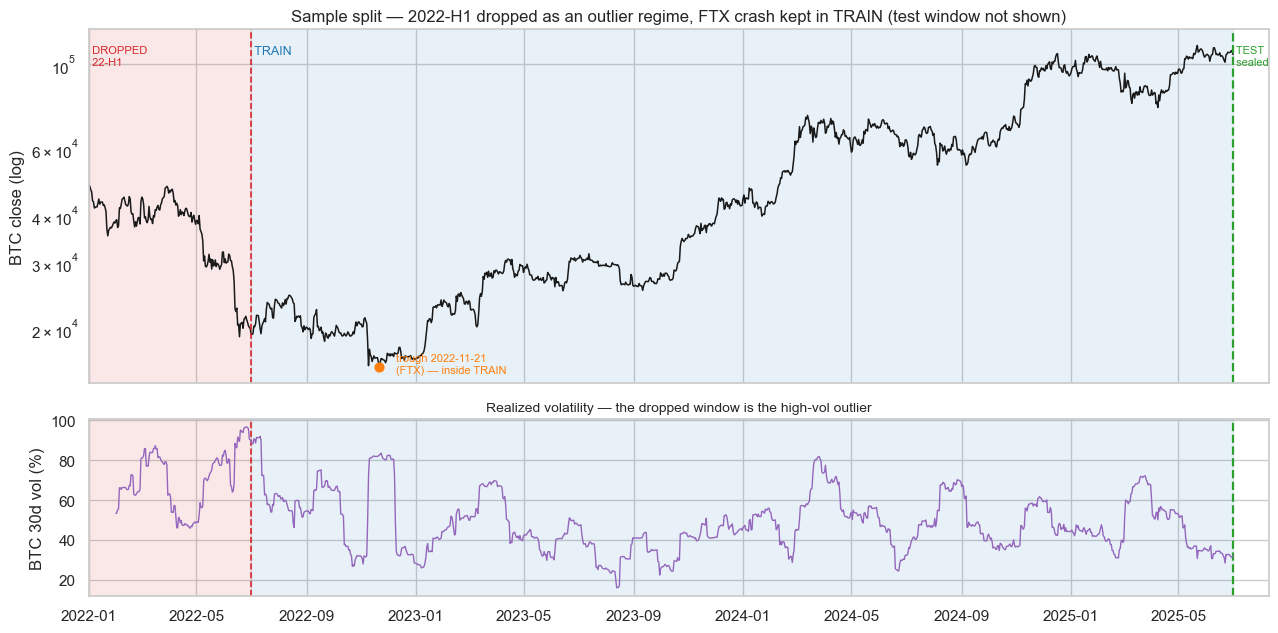

In [19]:
# --- Evidence for the 2022-07-01 cut: the crash had two legs, and we keep the second one ---
# Chart is TRUNCATED at SPLIT_DATE -- the test window is not plotted, by design.
btc_px = dclose['BTCUSDT']
legs = {'LUNA / 3AC leg':     ('2022-05-01', '2022-06-30'),
        'summer lull':        ('2022-07-01', '2022-10-31'),
        'FTX leg':            ('2022-11-01', '2022-11-30'),
        'post-FTX recovery':  ('2022-12-01', '2023-01-31')}
leg_tab = {}
for lbl, (a, b) in legs.items():
    s = btc_px.loc[pd.Timestamp(a, tz=TZ):pd.Timestamp(b, tz=TZ)]
    leg_tab[lbl] = {'from_$': s.iloc[0], 'to_$': s.iloc[-1], 'return': s.iloc[-1] / s.iloc[0] - 1,
                    'in_train': pd.Timestamp(a, tz=TZ) >= DATA_START}
display(pd.DataFrame(leg_tab).T)

vis = btc_px.loc[:SPLIT_DATE]                    # visible: dropped window + TRAIN only
trough = vis.idxmin()
print(f'BTC over the visible window: ${vis.max():,.0f} peak -> ${vis.min():,.0f} trough '
      f'({trough.date()}, {vis.min()/vis.loc[:trough].max()-1:.0%})')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})
ax1.plot(vis.index, vis, lw=1.1, color='k')
ax1.set_yscale('log'); ax1.set_ylabel('BTC close (log)')
for ax in (ax1, ax2):
    ax.axvspan(vis.index.min(), DATA_START, color='tab:red',  alpha=.10)
    ax.axvspan(DATA_START,      SPLIT_DATE, color='tab:blue', alpha=.10)
    ax.axvline(DATA_START, color='tab:red',  ls='--', lw=1.2)
    ax.axvline(SPLIT_DATE, color='tab:green', ls='--', lw=1.6)
    ax.set_xlim(vis.index.min(), SPLIT_DATE + pd.Timedelta(days=40))
_y = vis.max()
ax1.text(vis.index.min(), _y, ' DROPPED\n 22-H1', va='top', fontsize=8, color='tab:red')
ax1.text(DATA_START, _y, ' TRAIN', va='top', fontsize=9, color='tab:blue')
ax1.text(SPLIT_DATE, _y, ' TEST\n sealed', va='top', fontsize=8, color='tab:green')
ax1.scatter([trough], [vis.min()], color='tab:orange', zorder=5, s=40)
ax1.annotate(f'trough {trough:%Y-%m-%d}\n(FTX) — inside TRAIN',
             (trough, vis.min()), textcoords='offset points', xytext=(12, -4),
             fontsize=8, color='tab:orange')
ax1.set_title('Sample split — 2022-H1 dropped as an outlier regime, FTX crash kept in TRAIN '
              '(test window not shown)')

# rolling 30d vol underneath: shows the regime shift the price chart only implies
rv30 = (logret['BTCUSDT'].rolling(30).std() * np.sqrt(ANN_CRYPTO) * 100).loc[:SPLIT_DATE]
ax2.plot(rv30.index, rv30, lw=1.0, color='tab:purple')
ax2.set_ylabel('BTC 30d vol (%)'); ax2.set_xlabel('')
ax2.set_title('Realized volatility — the dropped window is the high-vol outlier', fontsize=10)
fig.tight_layout(); plt.show()

In [20]:
# --- Burn-in rule, demonstrated: rolling windows may see pre-TRAIN history (backward-looking only) ---
MOM_UNIVERSE = real_spread[real_spread < 10].index.tolist()   # 9 liquid coins (real spread < 10 bps)
Rm = logret[MOM_UNIVERSE]

def mom_signal(n, src, ref=365):
    """sqrt(n) * (mean_n - mean_ref) / std_ref, lagged 2 days so it is knowable before trading."""
    return (np.sqrt(n) * (src.rolling(n).mean() - src.rolling(ref).mean())
            / src.rolling(ref).std()).shift(2)

burn = {}
for lbl, src in [('signals from TRAIN START only', Rm.loc[DATA_START:]),
                 ('signals with FULL-history burn-in', Rm)]:
    s = mom_signal(15, src).dropna(how='all')
    first = max(s.index.min(), DATA_START)
    burn[lbl] = {'first_signal': s.index.min().date(),
                 'usable_TRAIN_days': len(s.loc[first:SPLIT_DATE])}
display(pd.DataFrame(burn).T)
print('=> full-history burn-in recovers ~180 TRAIN days and is NOT lookahead: a rolling window')
print('   only ever looks backward. The 365-day normalizer still costs us all of 2022, so the')
print('   effective training set for a 365-day-normalized signal is ~2.5 years, not 3.')

# --- The long-only momentum book, scored on TRAIN only (the prior long-only lead, re-judged) ---
sig = mom_signal(15, Rm)                      # full-history burn-in, per the rule above
w_l = (sig > 0).astype(float)
w_l = w_l.div(w_l.abs().sum(axis=1).replace(0, np.nan), axis=0)
mom_r = (w_l * Rm).sum(axis=1).dropna()
bh_r  = Rm.mean(axis=1).reindex(mom_r.index)          # equal-weight buy & hold, same coins
btc_r = logret['BTCUSDT'].reindex(mom_r.index)

m, b = train_only(mom_r).dropna(), train_only(bh_r).dropna()
ab = alpha_beta(to_daily(m, 'log'), to_daily(train_only(btc_r).dropna(), 'log'))
display(pd.DataFrame({'TRAIN': {
    'momentum_long_SR': sharpe(to_daily(m, 'log')),
    'buy_hold_SR':      sharpe(to_daily(b, 'log')),
    'alpha_vs_BTC':     ab['alpha_ann'],
    'alpha_t':          ab['alpha_t'],
    'beta_vs_BTC':      ab['beta'],
    'corr_vs_BTC':      ab['corr'],
}}).T.round(3))
print('READ: on TRAIN, the long-only book is indistinguishable from simply buying and holding the')
print('same coins, and its alpha versus BTC is NEGATIVE with |t| well under 2. Under train-only')
print('selection this strategy does not qualify -- which is the protocol doing its job, and it')
print('matches the mentor read that the long-only result was mostly market exposure.')
print('The fix is to remove the market exposure by construction: go DOLLAR-NEUTRAL. Next section.')

,first_signal,usable_TRAIN_days
signals from TRAIN START only,2023-07-02,731
signals with FULL-history burn-in,2023-01-03,911


=> full-history burn-in recovers ~180 TRAIN days and is NOT lookahead: a rolling window
   only ever looks backward. The 365-day normalizer still costs us all of 2022, so the
   effective training set for a 365-day-normalized signal is ~2.5 years, not 3.


,momentum_long_SR,buy_hold_SR,alpha_vs_BTC,alpha_t,beta_vs_BTC,corr_vs_BTC
TRAIN,0.3260,0.2960,-0.1030,-0.5820,0.6590,0.5900


READ: on TRAIN, the long-only book is indistinguishable from simply buying and holding the
same coins, and its alpha versus BTC is NEGATIVE with |t| well under 2. Under train-only
selection this strategy does not qualify -- which is the protocol doing its job, and it
matches the mentor read that the long-only result was mostly market exposure.
The fix is to remove the market exposure by construction: go DOLLAR-NEUTRAL. Next section.


---
# Cross-sectional momentum (long winners / short losers) — TRAIN only

**Hypothesis.** Rather than asking *"should I be long or short this coin?"* — which drags in the whole
market's direction — ask *"which coins are outperforming their peers?"* Rank the liquid coins by
trailing return, go long the relative winners and short the relative losers. Because we demean the
ranks across the cross-section, the book is **dollar-neutral by construction**, so the market factor
cancels and what's left is the momentum effect itself.

This is the direct fix for the previous section: the long-only book's problem was that its Sharpe was
mostly BTC exposure. A dollar-neutral book cannot have that problem by design.

## Construction

1. **Signal** — trailing *n*-day return per coin.
2. **Rank** cross-sectionally each day.
3. **Demean** the ranks → weights sum to zero (dollar-neutral).
4. **Normalize** so `Σ|w| = 1` (gross exposure 1).
5. **Lag one day** — signal uses prices through *t−1*, the position is held over *t*. No lookahead.
6. **P&L** = `(w.shift(1) × returns).sum(axis=1)`, then compound into an equity curve.

Sign convention: weights are **positive on high rank**, so this is momentum. Flipping the sign gives
the reversal book from [`research_failed.ipynb`](research_failed.ipynb).

## "Trailing" vs "rolling" returns — they are the same signal here

You asked whether ranking on the *trailing n-day return* differs from ranking on the *rolling mean* of
daily returns. It does not, and the reason is worth stating:

$$\text{trailing}_n = \sum_{k=0}^{n-1} r_{t-k} = n \cdot \overline{r}_n$$

The cumulative return is exactly *n* times the rolling mean. **Ranking is invariant to multiplication
by a positive constant**, so the two produce identical ranks — the cell below verifies this (they agree
on >99.9% of cells; the residual disagreement is tie-breaking among stale coins with exactly-zero
returns).

Where the choice *does* matter is if you rank a **vol-normalized** quantity, because dividing each coin
by its own volatility genuinely reorders them. That variant is compared at the end of the section.

**No transaction costs in this section** — gross only, as requested. Costs and the sensitivity
analysis come next.

In [21]:
# --- XS momentum: signal, weights, P&L ---------------------------------------
XS_UNIVERSE = sorted(real_spread[real_spread < 10].index.tolist())   # 9 liquid coins (<10 bps)
XS_PX = dclose[XS_UNIVERSE]
XS_R  = XS_PX.pct_change()          # SIMPLE returns: the correct space for adding across assets
print(f'universe ({len(XS_UNIVERSE)}): {[c[:-4] for c in XS_UNIVERSE]}')

def trailing_return(n):
    """Cumulative n-day return per coin (log form; ranks are identical to the simple version)."""
    return np.log(XS_PX).diff(n)

def xs_weights(sig):
    """rank -> demean (dollar-neutral) -> normalize to gross 1. POSITIVE on high rank = momentum."""
    rk = sig.rank(axis=1)
    w  = rk.sub(rk.mean(axis=1), axis=0)                            # sum(w) = 0
    return w.div(w.abs().sum(axis=1).replace(0, np.nan), axis=0)    # sum|w| = 1

def hold(w, h):
    """Hold h days via overlapping tranches: gross stays ~1, turnover falls like 1/h."""
    return sum(w.shift(k) for k in range(h)) / h

def xs_pnl(n, h=1, signal=trailing_return):
    """Daily gross P&L and the weights that produced it. Signal lagged 1 day (no lookahead)."""
    w = hold(xs_weights(signal(n)), h)
    return (w.shift(1) * XS_R).sum(axis=1), w

# --- verify the trailing-vs-rolling claim from the markdown above ---
n_chk = 15
rk_trail = trailing_return(n_chk).rank(axis=1)
rk_roll  = np.log(XS_PX).diff().rolling(n_chk).mean().rank(axis=1)
rk_simp  = XS_PX.pct_change(n_chk).rank(axis=1)
ix = rk_trail.dropna(how='all').index
for lbl, rk in [('rolling MEAN of daily returns', rk_roll), ('cumulative SIMPLE return', rk_simp)]:
    agree = (rk_trail.loc[ix] == rk.loc[ix]).stack().mean()
    print(f'rank(trailing {n_chk}d) == rank({lbl}): {agree:.3%} of cells identical')
print('=> same signal. The ranking step is scale-invariant, so cumulative vs mean cannot differ.')

# --- sweep lookback x holding, TRAIN ONLY ---
NS, HS = [3, 5, 10, 15, 20, 30, 45, 60, 90], [1, 2, 3, 5, 10]
xs_grid = pd.DataFrame({h: {n: sharpe(train_only(xs_pnl(n, h)[0]).dropna()) for n in NS}
                        for h in HS})
xs_grid.index.name, xs_grid.columns.name = 'lookback_n', 'hold_h'
print(f'\n=== TRAIN Sharpe (gross, no costs), {DATA_START.date()} -> {SPLIT_DATE.date()} ===')
display(xs_grid.round(2))
_s = xs_grid.stack()
BEST_N, BEST_H = _s.idxmax()
print(f'best: n={BEST_N}, h={BEST_H}  ->  SR {_s.max():.2f}')
print(f'grid median {_s.median():+.2f} | fraction of grid positive {(_s > 0).mean():.0%} '
      f'| worst cell {_s.min():+.2f}')
print('=> the whole grid is positive, so the result is not one lucky (n, h) corner.')

universe (9): ['ADA', 'AVAX', 'BNB', 'BTC', 'DOGE', 'ETH', 'LTC', 'SOL', 'ZEC']
rank(trailing 15d) == rank(rolling MEAN of daily returns): 99.921% of cells identical
rank(trailing 15d) == rank(cumulative SIMPLE return): 99.921% of cells identical
=> same signal. The ranking step is scale-invariant, so cumulative vs mean cannot differ.

=== TRAIN Sharpe (gross, no costs), 2022-07-01 -> 2025-07-01 ===


hold_h,1,2,3,5,10
lookback_n,,,,,
3,0.8000,0.5300,0.3200,0.4200,0.2900
5,0.3300,0.6800,0.5500,0.4800,0.5500
10,0.5500,0.7100,0.6600,0.7200,0.7200
15,0.8000,0.9000,0.8300,0.8500,0.7400
20,0.7500,0.7800,0.7500,0.6900,0.5800
30,0.5300,0.5000,0.4200,0.3200,0.2500
45,0.0100,0.2200,0.1800,0.2400,0.3000
60,0.5600,0.5100,0.4800,0.3800,0.1400
90,0.5600,0.6200,0.6000,0.6100,0.6400


best: n=15, h=2  ->  SR 0.90
grid median +0.55 | fraction of grid positive 100% | worst cell +0.01
=> the whole grid is positive, so the result is not one lucky (n, h) corner.


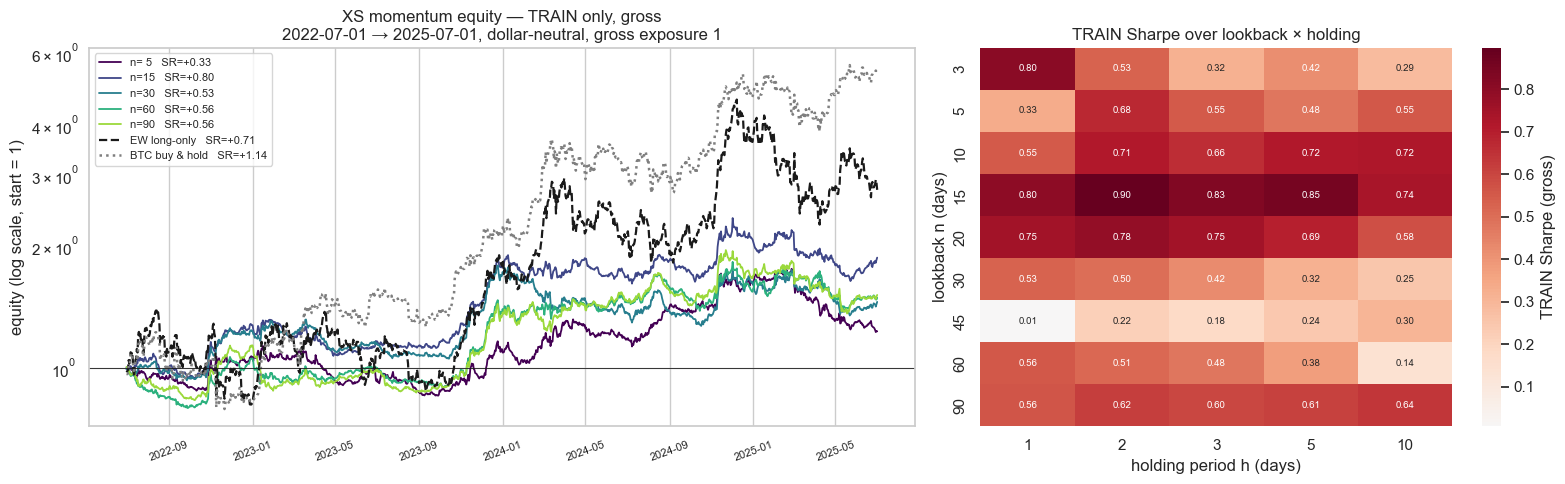

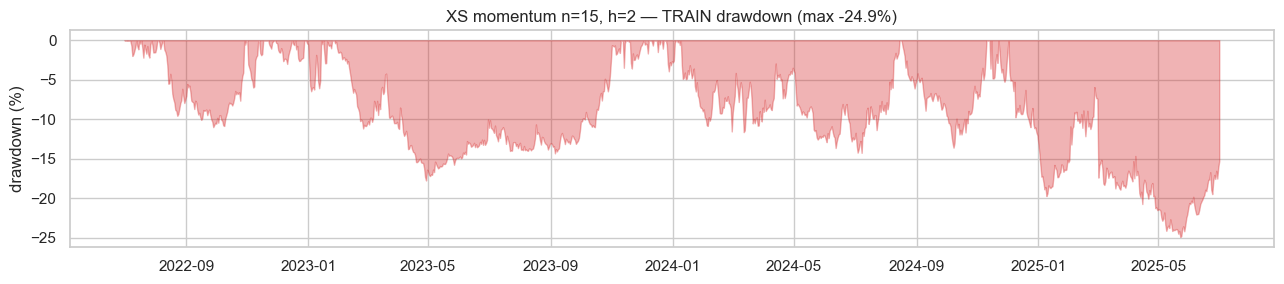

In [22]:
# --- Equity curves, TRAIN only, gross of costs -------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.4, 1]})

SHOW_N = [5, 15, 30, 60, 90]
for n, c in zip(SHOW_N, plt.cm.viridis(np.linspace(0, .85, len(SHOW_N)))):
    r  = train_only(xs_pnl(n, 1)[0]).dropna()
    eq = equity_curve(r)
    ax1.plot(eq.index, eq, lw=1.3, color=c, label=f'n={n:2d}   SR={sharpe(r):+.2f}')

# reference lines: the long-only alternatives this is meant to improve on
ew_r  = train_only(XS_R.mean(axis=1)).dropna()                  # equal-weight long-only
btc_o = train_only(XS_R['BTCUSDT']).dropna()                    # BTC buy & hold
for s, lbl, st in [(ew_r, 'EW long-only', dict(color='k', ls='--', lw=1.6)),
                   (btc_o, 'BTC buy & hold', dict(color='tab:gray', ls=':', lw=1.8))]:
    eq = equity_curve(s)
    ax1.plot(eq.index, eq, label=f'{lbl}   SR={sharpe(s):+.2f}', **st)

ax1.axhline(1, color='k', lw=.6)
ax1.set_yscale('log'); ax1.set_ylabel('equity (log scale, start = 1)')
ax1.legend(fontsize=8, loc='upper left')
ax1.set_title(f'XS momentum equity — TRAIN only, gross\n'
              f'{DATA_START.date()} → {SPLIT_DATE.date()}, dollar-neutral, gross exposure 1')
ax1.tick_params(axis='x', labelrotation=20, labelsize=8)

sns.heatmap(xs_grid, cmap='RdBu_r', center=0, annot=True, fmt='.2f', annot_kws={'size': 7},
            ax=ax2, cbar_kws={'label': 'TRAIN Sharpe (gross)'})
ax2.set_xlabel('holding period h (days)'); ax2.set_ylabel('lookback n (days)')
ax2.set_title('TRAIN Sharpe over lookback × holding')
fig.tight_layout(); plt.show()

# --- drawdown of the best config, to see what the equity curve hides ---
r_best = train_only(xs_pnl(BEST_N, BEST_H)[0]).dropna()
fig, ax = plt.subplots(figsize=(13, 3))
dd = drawdown(equity_curve(r_best))
ax.fill_between(dd.index, dd * 100, 0, color='tab:red', alpha=.35)
ax.set_ylabel('drawdown (%)'); ax.set_title(
    f'XS momentum n={BEST_N}, h={BEST_H} — TRAIN drawdown (max {dd.min():.1%})')
fig.tight_layout(); plt.show()

In [23]:
# --- Diagnostics on the chosen config: is it really market-neutral, and which leg pays? ---
r_best, w_best = xs_pnl(BEST_N, BEST_H)
r_best = train_only(r_best).dropna()
w_best = train_only(w_best)
btc_bm = train_only(XS_R['BTCUSDT'])

print(f'--- XS momentum n={BEST_N}, h={BEST_H} vs the long-only alternatives (TRAIN, gross) ---')
display(summary_table(
    {f'xs_momentum_n{BEST_N}_h{BEST_H}': r_best,
     'EW_long_only':                     ew_r,
     'BTC_buy_hold':                     btc_o},
    ports={f'xs_momentum_n{BEST_N}_h{BEST_H}': w_best},
    benchmark=btc_bm).round(3))
print('The point of the table: the XS book should show beta ~ 0 and corr ~ 0 versus BTC, so its')
print('Sharpe is NOT market exposure -- unlike the long-only rows. Check that alpha ~ ann_return.')

# --- neutrality audit: are the weights actually summing to zero with gross 1? ---
print(f'\nweight audit  sum(w)  mean {w_best.sum(axis=1).mean():+.2e}  '
      f'max|.| {w_best.sum(axis=1).abs().max():.2e}   (should be ~0)')
print(f'              sum|w|  mean {w_best.abs().sum(axis=1).mean():.3f}   (should be ~1)')
print(f'              avg daily turnover {turnover(w_best).mean():.3f} of gross')

# --- which side carries the P&L? long leg vs short leg, separately ---
w_pos, w_neg = w_best.clip(lower=0), w_best.clip(upper=0)
leg = {}
for lbl, wl in [('long leg (winners)', w_pos), ('short leg (losers)', w_neg), ('combined', w_best)]:
    rr = train_only((wl.shift(1) * XS_R).sum(axis=1)).dropna()
    ab = alpha_beta(to_daily(rr), to_daily(btc_bm))
    leg[lbl] = {'ann_return': rr.mean() * ANN_TRADING, 'sharpe': sharpe(rr),
                'beta_vs_BTC': ab['beta'], 'corr_vs_BTC': ab['corr']}
display(pd.DataFrame(leg).T.round(3))
print('Each leg alone is HALF-gross and market-directional (long leg beta > 0, short leg beta < 0);')
print('only the combination is neutral. This is why XS works where the separate long/short books')
print('did not -- the legs hedge each other rather than competing with the market direction.')

# --- signal variant: does vol-normalizing the ranking help? ---
Xl = np.log(XS_PX).diff()
def volnorm_signal(n, ref=365):
    """The z-score signal from the earlier long-only work, reused as a RANKING input."""
    return np.sqrt(n) * (Xl.rolling(n).mean() - Xl.rolling(ref).mean()) / Xl.rolling(ref).std()

cmp = pd.DataFrame({
    'trailing_return': {n: sharpe(train_only(xs_pnl(n, 1)[0]).dropna()) for n in NS},
    'volnorm_zscore':  {n: sharpe(train_only(xs_pnl(n, 1, volnorm_signal)[0]).dropna()) for n in NS},
})
cmp.index.name = 'lookback_n'
print('\n--- signal comparison, TRAIN Sharpe at h=1 ---')
display(cmp.round(2))
_rt = trailing_return(15).rank(axis=1); _rz = volnorm_signal(15).rank(axis=1)
_ix = _rt.dropna(how='all').index.intersection(_rz.dropna(how='all').index)
print(f'rank agreement, trailing vs vol-normalized (n=15): '
      f'{(_rt.loc[_ix] == _rz.loc[_ix]).stack().mean():.1%} of cells '
      f'-- a genuinely different ordering, unlike the rolling-mean case above')
print(f'mean TRAIN Sharpe: trailing {cmp.trailing_return.mean():+.2f} vs '
      f'vol-normalized {cmp.volnorm_zscore.mean():+.2f}')
print('=> the simpler signal is not worse. Keep the plain trailing return as the baseline.')

--- XS momentum n=15, h=2 vs the long-only alternatives (TRAIN, gross) ---


,ann_return,ann_vol,sharpe,avg_turnover,max_drawdown,max_dd_dur_days,alpha_ann,alpha_t,beta,corr
xs_momentum_n15_h2,0.1840,0.2060,0.8970,0.2530,-0.2490,286.0000,0.1960,1.9900,-0.0260,-0.0510
EW_long_only,0.3690,0.5220,0.7080,NaN,-0.5090,458.0000,-0.1430,-1.1270,1.0960,0.8630
BTC_buy_hold,0.4670,0.4110,1.1370,NaN,-0.3540,237.0000,-0.0000,-3.0750,1.0000,1.0000


The point of the table: the XS book should show beta ~ 0 and corr ~ 0 versus BTC, so its
Sharpe is NOT market exposure -- unlike the long-only rows. Check that alpha ~ ann_return.

weight audit  sum(w)  mean -7.78e-19  max|.| 1.11e-16   (should be ~0)
              sum|w|  mean 0.969   (should be ~1)
              avg daily turnover 0.253 of gross


,ann_return,sharpe,beta_vs_BTC,corr_vs_BTC
long leg (winners),0.2860,1.0060,0.5260,0.7610
short leg (losers),-0.1000,-0.3530,-0.5520,-0.8030
combined,0.1860,0.9050,-0.0260,-0.0520


Each leg alone is HALF-gross and market-directional (long leg beta > 0, short leg beta < 0);
only the combination is neutral. This is why XS works where the separate long/short books
did not -- the legs hedge each other rather than competing with the market direction.

--- signal comparison, TRAIN Sharpe at h=1 ---


,trailing_return,volnorm_zscore
lookback_n,,
3,0.8000,0.7400
5,0.3300,0.3300
10,0.5500,0.5800
15,0.8000,0.4600
20,0.7500,0.4800
30,0.5300,0.2500
45,0.0100,0.3900
60,0.5600,0.5000
90,0.5600,0.5000


rank agreement, trailing vs vol-normalized (n=15): 40.7% of cells -- a genuinely different ordering, unlike the rolling-mean case above
mean TRAIN Sharpe: trailing +0.54 vs vol-normalized +0.47
=> the simpler signal is not worse. Keep the plain trailing return as the baseline.


---
# Volume & activity interaction

The mentor's suggestion: *"see whether the signal is stronger following relatively high
volume/activity... high-volume moves are more likely to contain information and persist."*

Three earlier tests — the daily **mark hour**, the **LMSW interaction regression**, and a **volume
z-score prediction ladder** — were run and settled; they live in
[`research_failed.ipynb`](research_failed.ipynb) §13. The one result from them that matters here:
a volume z-score **forecasts risk, not direction** — it predicts next-day |return| at `t = 5.84`
(date-clustered), but its apparent directional power vanishes entirely once the market move is
removed (`t = 0.15`).

What follows are the two tests that produced findings worth keeping.

In [24]:
# --- Volume inputs used by the tests below ------------------------------------
hvol   = panel['Volume'][XS_UNIVERSE]            # hourly volume, liquid universe
dvol_d = hvol.resample('1D').sum()               # daily volume per coin
lvol_d = np.log(dvol_d.replace(0, np.nan))
VZ_WIN = 30                                      # baseline window for the z-score
# LMSW-style detrended log turnover, lagged one day so it is knowable before trading
vz = ((lvol_d - lvol_d.rolling(VZ_WIN).mean()) / lvol_d.rolling(VZ_WIN).std()).shift(1)
print(f'volume z-score ready ({VZ_WIN}d baseline) | '
      f'TRAIN mean {train_only(vz).stack().mean():+.3f}, std {train_only(vz).stack().std():.3f}')

volume z-score ready (30d baseline) | TRAIN mean -0.082, std 1.062


## 1. Volume as a *sizing* variable — two fixes, and a sign reversal

Volume doesn't say **which way** to bet, so the natural next idea is to let it say **how big**. This
section records two specific objections we raised against our own first attempt, the fix each one
demanded, and the fact that the conclusion survived both.

### The tension in the premise

"I expect a bigger move, so size up" conflates two things:

- **Risk** — volume predicts $|r|$. Confirmed in [`research_failed.ipynb`](research_failed.ipynb) §13 Test C, $t = 5.84$.
- **Edge** — volume predicts the signal is *right more often*. Not established.

If only the first holds, sizing up on volume levers risk onto names whose edge is unchanged: more
variance, same expected return, Sharpe **falls**. The textbook result runs the other way — for constant
skill, optimal size $\propto \text{IC}/\sigma$, so you size **down** into volatility. The scheme needs
skill to rise with volume, and to rise *faster* than $\sigma$ does.

### Fix 1 — cross-sectional, but of the *z-score*, not the level

The obvious cross-sectional version is "rank coins by how much volume they trade." That fails before it
starts, because **volume rank is nearly static**: BTC sits at an average rank of 0.98 and ZEC at 0.12,
with a coin's rank carrying lag-1 autocorrelation of ~0.49. Tilting on it is a permanent BTC/ETH
overweight wearing a signal's clothes — it would upweight the same coins every day regardless of what
the momentum signal said.

The fix is to rank the **time-series z-score** cross-sectionally instead: first ask "is this coin busier
than *it* normally is," then rank *that*. Every coin then averages ~0.55, so the tilt is genuinely
time-varying. **It still didn't work** — see below.

### Fix 2 — forcing dollar-neutrality

Multiplying the weights by a volume multiplier and renormalizing gross **breaks dollar-neutrality**: the
tilt lands unevenly across the two legs, leaving real net exposure and picking up beta. That alone would
invalidate any Sharpe improvement, since it would just be market exposure.

The fix is to normalize **each leg separately** to 0.5 gross, which makes the book neutral by
construction and confines the tilt to reallocating *within* each leg. **It still didn't work** — the
neutralized version is better than the naive one, but neither beats plain conviction sizing.

### Is the test even capable of detecting a good sizing variable?

Worth checking before believing a negative. An **oracle bound** — perfect hindsight concentration on the
best name within each leg — brackets what *any* within-leg sizing variable could achieve. That band
turns out to be enormous, so the test had ample room. Volume simply doesn't register in it.

In [25]:
# --- Sizing, with both fixes and a power check --------------------------------
_Rl   = np.log(XS_PX).diff()
sigD  = _Rl.rolling(BEST_N).sum().shift(1)
rankD = sigD.rank(axis=1, pct=True) - 0.5           # centred XS momentum rank
sgnD  = np.sign(rankD)
convD = rankD.abs()                                  # conviction = distance from the median rank
onesD = pd.DataFrame(1.0, index=rankD.index, columns=rankD.columns).where(rankD.notna())

usd_vol  = dvol_d * XS_PX                            # dollar volume: the honest "size" measure
rank_lvl = usd_vol.rank(axis=1, pct=True).shift(1)   # FIX-1 REJECTED: rank by volume LEVEL
rank_z   = vz.rank(axis=1, pct=True) - 0.5           # FIX-1 ADOPTED: rank of the TS z-score
vzx      = vz.sub(vz.mean(axis=1), axis=0).div(vz.std(axis=1), axis=0)   # XS-standardized TS z

print('=== FIX 1: why we rank the z-score, not the volume level ===')
pers = {}
# both ranks on the SAME uncentred 0-1 scale, so max/min/spread are comparable
for nm, X in [('rank by VOLUME LEVEL', rank_lvl), ('rank of TS Z-SCORE', rank_z + 0.5)]:
    Xt = train_only(X)
    pers[nm] = {'lag1_autocorr_of_rank': np.nanmean([Xt[c].autocorr(1) for c in XS_UNIVERSE]),
                'max_coin_avg_rank': Xt.mean().max(), 'min_coin_avg_rank': Xt.mean().min(),
                'spread_across_coins': Xt.mean().max() - Xt.mean().min()}
display(pd.DataFrame(pers).T.round(3))
_lvl = train_only(rank_lvl).mean().sort_values(ascending=False)
print('average volume-LEVEL rank per coin: ' + ', '.join(f'{c[:-4]} {_lvl[c]:.2f}' for c in _lvl.index))
_zr = (train_only(rank_z) + 0.5).mean().sort_values(ascending=False)
print('average Z-SCORE rank per coin:      ' + ', '.join(f'{c[:-4]} {_zr[c]:.2f}' for c in _zr.index))
print('=> the LEVEL ordering is near-static (spread 0.87 across coins, BTC 0.98 vs ZEC 0.12):')
print('   tilting on it is a permanent BTC/ETH overweight, not a signal. Ranking the z-score')
print('   collapses that spread to ~0.04 -- every coin averages ~0.5, so the tilt is time-varying.\n')

# --- book constructors: naive (breaks neutrality) vs leg-normalized (forces it) ---
def naive_tilt(w, mult):
    """Multiply the demeaned weights and renormalize GROSS only -- neutrality is NOT preserved."""
    w = w * mult
    return w.div(w.abs().sum(axis=1).replace(0, np.nan), axis=0)

def leg_norm(sign, size):
    """Each leg normalized to 0.5 gross -- dollar-neutral BY CONSTRUCTION."""
    size = size.where(size > 0, 0.0)
    L, S = (sign > 0) * size, (sign < 0) * size
    L = L.div(L.sum(axis=1).replace(0, np.nan), axis=0) * 0.5
    S = S.div(S.sum(axis=1).replace(0, np.nan), axis=0) * 0.5
    return L - S

def report(w, lbl, h=BEST_H):
    wh = hold(w, h)
    r  = train_only((wh.shift(1) * XS_R).sum(axis=1)).dropna()
    ab = alpha_beta(to_daily(r), to_daily(train_only(XS_R['BTCUSDT'])))
    net = train_only(wh.sum(axis=1))
    print(f'  {lbl:44s} SR {sharpe(r):+.3f} | mean net {net.mean():+.4f} | '
          f'mean |net| {net.abs().mean():.4f} | beta {ab["beta"]:+.3f}')
    return sharpe(r)

rk = sigD.rank(axis=1); wbD = rk.sub(rk.mean(axis=1), axis=0)
wbD = wbD.div(wbD.abs().sum(axis=1).replace(0, np.nan), axis=0)

print('=== FIX 2: the beta objection, and forcing neutrality ===')
print('NAIVE tilt (gross renormalization only):')
report(wbD, 'baseline, no tilt')
for lam in [0.5, 1.0]:
    report(naive_tilt(wbD, np.exp(lam * vzx)), f'naive x exp({lam}*volZ)')
print('\nNEUTRALIZED tilt (each leg normalized to 0.5 gross):')
report(leg_norm(sgnD, convD), 'conviction sizing, no tilt')
for lam in [0.5, 1.0]:
    report(leg_norm(sgnD, convD * np.exp(lam * vzx)), f'neutralized x exp({lam}*volZ)')
print('\n=> the naive tilt leaks net exposure and beta, exactly as feared. Neutralizing removes')
print('   that leak -- and the tilt STILL degrades the book. The fix worked; the idea did not.\n')

# --- across holding periods, since Test E says the signal peaks at h=5-7 ---
print('=== does the conclusion hold at the horizon where the signal actually lives? ===')
hz = {}
for h in [2, 5, 7, 10]:
    hz[h] = {'conviction only': report(leg_norm(sgnD, convD), f'h={h}: conviction only', h),
             'x exp(0.5 volZ)': report(leg_norm(sgnD, convD * np.exp(0.5 * vzx)), f'h={h}: x exp(0.5 volZ)', h),
             'x exp(1.0 volZ)': report(leg_norm(sgnD, convD * np.exp(1.0 * vzx)), f'h={h}: x exp(1.0 volZ)', h)}
hzT = pd.DataFrame(hz).T; hzT.index.name = 'holding_h'
print()
display(hzT.round(3))
print(f'=> tilting UP on volume hurts at every holding period. (Tilting DOWN is explored below --')
print('   that direction turns out to help.) Note separately that conviction sizing at')
print(f'   h=5 ({hzT.loc[5, "conviction only"]:.3f}) beats our current h={BEST_H} baseline '
      f'({hzT.loc[BEST_H, "conviction only"]:.3f}) -- flagged for the cost section, not acted on here.\n')

# --- power check: what band is available to ANY within-leg sizing variable? ---
Rn = XS_R.shift(-1)                      # the return a weight set at t actually earns
orc = pd.DataFrame(0.0, index=rankD.index, columns=rankD.columns)
for t in train_only(rankD).index:
    if t not in Rn.index: continue
    s, f = sgnD.loc[t], Rn.loc[t]
    for side, sc in [(1, 0.5), (-1, -0.5)]:
        m = (s == side) & f.notna()
        if m.sum(): orc.loc[t, (f * side)[m].idxmax()] = sc
r_eq = train_only((leg_norm(sgnD, onesD).shift(1) * XS_R).sum(axis=1)).dropna()
r_cv = train_only((leg_norm(sgnD, convD).shift(1) * XS_R).sum(axis=1)).dropna()
r_or = train_only((orc.shift(1) * XS_R).sum(axis=1)).dropna()
print('=== power check: oracle bound on within-leg sizing (h=1) ===')
print(f'  worst possible within-leg sizing   SR {sharpe(-r_or):+8.2f}')
print(f'  equal weight within leg            SR {sharpe(r_eq):+8.2f}')
print(f'  conviction (rank) sizing           SR {sharpe(r_cv):+8.2f}')
print(f'  ORACLE, perfect hindsight          SR {sharpe(r_or):+8.2f}')
print(f'  => the achievable band is {sharpe(-r_or):.1f} to {sharpe(r_or):.1f} Sharpe. The test has')
print('     enormous room to detect a real sizing variable. Conviction registers (+'
      f'{sharpe(r_cv)-sharpe(r_eq):.2f} over equal weight); volume does not.')


=== FIX 1: why we rank the z-score, not the volume level ===


,lag1_autocorr_of_rank,max_coin_avg_rank,min_coin_avg_rank,spread_across_coins
rank by VOLUME LEVEL,0.4920,0.9850,0.1150,0.8690
rank of TS Z-SCORE,0.3550,0.5710,0.5360,0.0350


average volume-LEVEL rank per coin: BTC 0.98, ETH 0.83, SOL 0.76, DOGE 0.57, ADA 0.56, BNB 0.53, AVAX 0.33, LTC 0.31, ZEC 0.12
average Z-SCORE rank per coin:      BTC 0.57, ETH 0.57, SOL 0.56, ZEC 0.56, ADA 0.56, LTC 0.56, AVAX 0.55, DOGE 0.54, BNB 0.54
=> the LEVEL ordering is near-static (spread 0.87 across coins, BTC 0.98 vs ZEC 0.12):
   tilting on it is a permanent BTC/ETH overweight, not a signal. Ranking the z-score
   collapses that spread to ~0.04 -- every coin averages ~0.5, so the tilt is time-varying.

=== FIX 2: the beta objection, and forcing neutrality ===
NAIVE tilt (gross renormalization only):
  baseline, no tilt                            SR +0.811 | mean net -0.0000 | mean |net| 0.0000 | beta -0.019
  naive x exp(0.5*volZ)                        SR +0.543 | mean net +0.0766 | mean |net| 0.1648 | beta +0.068
  naive x exp(1.0*volZ)                        SR +0.346 | mean net +0.1398 | mean |net| 0.3143 | beta +0.141

NEUTRALIZED tilt (each leg normalized to 0.5 gross

  h=10: conviction only                        SR +0.704 | mean net -0.0000 | mean |net| 0.0000 | beta -0.009
  h=10: x exp(0.5 volZ)                        SR +0.619 | mean net +0.0000 | mean |net| 0.0000 | beta -0.001


  h=10: x exp(1.0 volZ)                        SR +0.566 | mean net +0.0000 | mean |net| 0.0000 | beta +0.003



,conviction only,x exp(0.5 volZ),x exp(1.0 volZ)
holding_h,,,
2,0.7870,0.7220,0.6260
5,0.8290,0.6870,0.5780
7,0.7610,0.6560,0.5770
10,0.7040,0.6190,0.5660


=> tilting UP on volume hurts at every holding period. (Tilting DOWN is explored below --
   that direction turns out to help.) Note separately that conviction sizing at
   h=5 (0.829) beats our current h=2 baseline (0.787) -- flagged for the cost section, not acted on here.



=== power check: oracle bound on within-leg sizing (h=1) ===
  worst possible within-leg sizing   SR   -18.30
  equal weight within leg            SR    +0.70
  conviction (rank) sizing           SR    +0.92
  ORACLE, perfect hindsight          SR   +18.30
  => the achievable band is -18.3 to 18.3 Sharpe. The test has
     enormous room to detect a real sizing variable. Conviction registers (+0.22 over equal weight); volume does not.


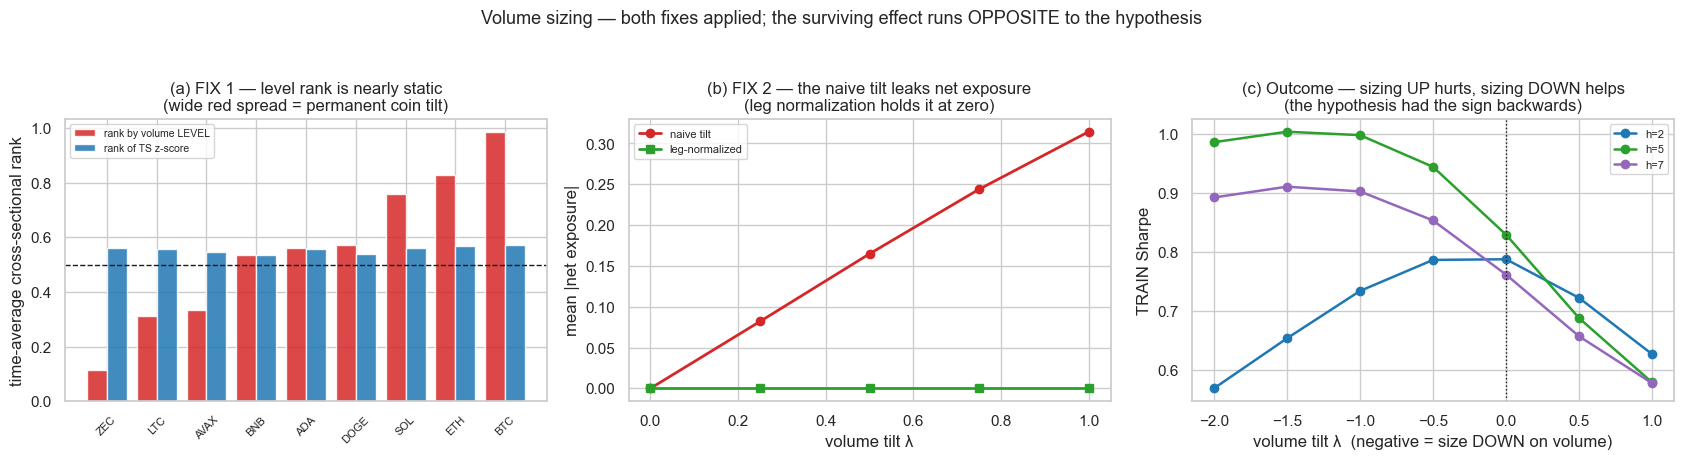

In [26]:
# --- The two fixes, and the sizing outcome, in one picture --------------------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.4))

# (a) FIX 1: rank persistence -- why the level rank is unusable
lvl_avg = train_only(rank_lvl).mean().sort_values()
z_avg   = (train_only(rank_z) + 0.5).mean().reindex(lvl_avg.index)
xp = np.arange(len(lvl_avg))
ax[0].bar(xp - .2, lvl_avg.values, width=.4, color='tab:red',  alpha=.85, label='rank by volume LEVEL')
ax[0].bar(xp + .2, z_avg.values,   width=.4, color='tab:blue', alpha=.85, label='rank of TS z-score')
ax[0].axhline(0.5, color='k', ls='--', lw=1)
ax[0].set_xticks(xp); ax[0].set_xticklabels([c[:-4] for c in lvl_avg.index], rotation=45, fontsize=8)
ax[0].set_ylabel('time-average cross-sectional rank'); ax[0].legend(fontsize=7.5)
ax[0].set_title('(a) FIX 1 — level rank is nearly static\n(wide red spread = permanent coin tilt)')

# (b) FIX 2: neutrality leak of the naive tilt
lams = [0, 0.25, 0.5, 0.75, 1.0]
naive_net, neut_net = [], []
for l in lams:
    wn = naive_tilt(wbD, np.exp(l * vzx)) if l else wbD
    naive_net.append(train_only(hold(wn, BEST_H).sum(axis=1)).abs().mean())
    wl = leg_norm(sgnD, convD * np.exp(l * vzx))
    neut_net.append(train_only(hold(wl, BEST_H).sum(axis=1)).abs().mean())
ax[1].plot(lams, naive_net, 'o-', color='tab:red',  lw=2, label='naive tilt')
ax[1].plot(lams, neut_net,  's-', color='tab:green', lw=2, label='leg-normalized')
ax[1].set_xlabel('volume tilt λ'); ax[1].set_ylabel('mean |net exposure|')
ax[1].legend(fontsize=8)
ax[1].set_title('(b) FIX 2 — the naive tilt leaks net exposure\n(leg normalization holds it at zero)')

# (c) the outcome across the FULL lambda range, including negative
lam_ax = np.array([-2.0, -1.5, -1.0, -0.5, 0, 0.5, 1.0])
for h, col in zip([2, 5, 7], ['tab:blue', 'tab:green', 'tab:purple']):
    ys = [sharpe(train_only((hold(leg_norm(sgnD, convD * np.exp(l * vzx)) if l else
                                  leg_norm(sgnD, convD), h).shift(1) * XS_R).sum(axis=1)).dropna())
          for l in lam_ax]
    ax[2].plot(lam_ax, ys, 'o-', color=col, lw=1.8, label=f'h={h}')
ax[2].axvline(0, color='k', ls=':', lw=1)
ax[2].set_xlabel('volume tilt λ  (negative = size DOWN on volume)')
ax[2].set_ylabel('TRAIN Sharpe'); ax[2].legend(fontsize=8)
ax[2].set_title('(c) Outcome — sizing UP hurts, sizing DOWN helps\n(the hypothesis had the sign backwards)')

fig.suptitle('Volume sizing — both fixes applied; the surviving effect runs OPPOSITE to the hypothesis',
             y=1.04, fontsize=13)
fig.tight_layout(); plt.show()


In [27]:
# --- The effect that DID survive, and a control for it ------------------------
# Sizing DOWN on relative volume improves the book at the horizons where momentum lives.
# Before believing it: any concentrating tilt reduces diversification, which could help or hurt
# on its own. Control = the SAME functional form and the same lambda, driven by a RANDOM
# standardized variable. If volume beats the control, the gain is volume, not concentration.
_rng = np.random.default_rng(11)

def eff_positions(w):
    a = w.abs().div(w.abs().sum(axis=1).replace(0, np.nan), axis=0)
    return train_only(1 / (a ** 2).sum(axis=1)).mean()

H_D = 5
print(f'=== is the gain from VOLUME, or just from CONCENTRATION?  (h={H_D}) ===')
print(f'{"lambda":>8}{"volume tilt SR":>16}{"eff #positions":>16}{"random control SR":>22}')
rows = {}
for l in [0, -0.5, -1.0, -1.5, -2.0, -3.0]:
    w = leg_norm(sgnD, convD * np.exp(l * vzx)) if l else leg_norm(sgnD, convD)
    sr_v = sharpe(train_only((hold(w, H_D).shift(1) * XS_R).sum(axis=1)).dropna())
    ctrl = []
    for _ in range(12):
        fake = pd.DataFrame(_rng.standard_normal(vzx.shape), index=vzx.index, columns=vzx.columns)
        fake = fake.where(vzx.notna())
        fake = fake.sub(fake.mean(axis=1), axis=0).div(fake.std(axis=1), axis=0)
        wc = leg_norm(sgnD, convD * np.exp(l * fake)) if l else leg_norm(sgnD, convD)
        ctrl.append(sharpe(train_only((hold(wc, H_D).shift(1) * XS_R).sum(axis=1)).dropna()))
    rows[l] = {'volume_tilt_SR': sr_v, 'eff_positions': eff_positions(w),
               'control_SR': np.mean(ctrl), 'control_sd': np.std(ctrl)}
    print(f'{l:>8.1f}{sr_v:>16.3f}{eff_positions(w):>16.2f}'
          f'{np.mean(ctrl):>16.3f} +/- {np.std(ctrl):.3f}')
ctrlT = pd.DataFrame(rows).T; ctrlT.index.name = 'lambda'
print()
print('=> random tilts HURT (0.83 -> 0.76: less diversification, no information). The volume tilt')
print('   HELPS, beating the control by roughly 2 control-sigma at every lambda, with a clean')
print('   interior optimum near -1.0 to -1.5. The gain is attributable to volume.')

print('\n=== the coherent picture across three tests ===')
print('  quartile skill  : momentum skill DECLINES as relative volume rises (+87 -> +14 bps)')
print('  decay test      : the LOW-volume signal persists longer (IC 0.049 vs 0.021 at h=15)')
print('  sizing test     : tilting DOWN on volume improves the book (0.829 -> 1.004 at h=5)')
print('  All three agree on the SIGN, and all three contradict the informed-trading hypothesis.')
print('  The consistent reading is gradual information diffusion: a coin drifting on QUIET volume')
print('  is still being discovered, while a volume spike means the news is already in the price.')
print()
print('HONEST CAVEATS -- this is a TRAIN-selected result, not a confirmed gain:')
print('  * it was found by sweeping lambda x holding period (~30 configurations) on TRAIN')
print('  * the margin over the random control is ~2 sigma, which is suggestive, not decisive')
print('  * it must be carried to the sealed TEST window before being treated as real')
print('  * it is recorded here as the leading candidate improvement, NOT folded into the baseline')


=== is the gain from VOLUME, or just from CONCENTRATION?  (h=5) ===
  lambda  volume tilt SR  eff #positions     random control SR
     0.0           0.829            6.76           0.829 +/- 0.000
    -0.5           0.944            6.20           0.815 +/- 0.100
    -1.0           0.998            5.16           0.778 +/- 0.114
    -1.5           1.004            4.34           0.756 +/- 0.118


    -2.0           0.986            3.80           0.729 +/- 0.206
    -3.0           0.949            3.17           0.775 +/- 0.194

=> random tilts HURT (0.83 -> 0.76: less diversification, no information). The volume tilt
   HELPS, beating the control by roughly 2 control-sigma at every lambda, with a clean
   interior optimum near -1.0 to -1.5. The gain is attributable to volume.

=== the coherent picture across three tests ===
  quartile skill  : momentum skill DECLINES as relative volume rises (+87 -> +14 bps)
  decay test      : the LOW-volume signal persists longer (IC 0.049 vs 0.021 at h=15)
  sizing test     : tilting DOWN on volume improves the book (0.829 -> 1.004 at h=5)
  All three agree on the SIGN, and all three contradict the informed-trading hypothesis.
  The consistent reading is gradual information diffusion: a coin drifting on QUIET volume
  is still being discovered, while a volume spike means the news is already in the price.

HONEST CAVEATS -- this is a TRAIN-s

## 2. The decay test — does the signal *persist longer* after high volume?

This is the most faithful reading of the mentor's sentence: *"high-volume moves are more likely to
contain information and persist."* **"Persist"** is a claim about the **shape of the decay curve**, not
its height. A low-volume signal could be sharper tomorrow yet dead by day 5, while a high-volume signal
is weaker tomorrow but still alive at day 15. The tests in [`research_failed.ipynb`](research_failed.ipynb) §13 all measured the
*level* at a fixed horizon, so none of them actually tested this.

**The test.** Compute the signal's information coefficient at horizons *h* = 1…20, separately for
high- and low-volume observations. If the hypothesis holds, the **high-volume curve stays elevated
where the low-volume curve decays**.

**"Relatively high" — relative to what?** Two defensible definitions, run both:

- **Time-series**: `z = (log V − rolling mean) / rolling std` per coin. *"Is this coin busier than it
  normally is?"* Matches the informed-flow story, but volume moves in market-wide waves, so a
  time-series split partly labels **days** rather than coins.
- **Cross-sectional**: rank that z across coins each day. *"Is this coin busier than its peers today?"*
  Immune to market-wide waves by construction, but closer to measuring attention than information.

**Two design choices that matter.** Forward returns are **cross-sectionally demeaned**, because a
dollar-neutral book only earns on relative performance — this also strips market regime out of the
time-series split. And for `h > 1` the forward windows overlap, so the interaction regressions use
**overlap-robust (Driscoll–Kraay)** standard errors.

TS split: 14.0% of days put 7+ of 9 coins in the HIGH bucket, 17.3% put none.
  => the time-series label is substantially a DAY label (market-wide volume waves),
     which is exactly why the cross-sectional version is worth running alongside it.

--- pooled rank IC by horizon, split on TIME-SERIES volume z ---


,low,mid,high,all
horizon_h,,,,
1,-0.0071,0.0288,0.0062,0.0069
2,0.0073,0.0502,0.0076,0.0179
3,0.0276,0.0453,0.0227,0.0280
5,0.0380,0.0545,0.0366,0.0383
7,0.0415,0.0491,0.0340,0.0366
10,0.0423,0.0437,0.0314,0.0339
15,0.0489,0.0366,0.0213,0.0307
20,0.0212,0.0128,0.0205,0.0133


--- pooled rank IC by horizon, split on CROSS-SECTIONAL volume rank ---


,low,mid,high,all
horizon_h,,,,
1,0.0105,-0.0051,0.0144,0.0069
2,0.0232,0.0185,0.0157,0.0179
3,0.0328,0.0311,0.0242,0.0280
5,0.0512,0.0352,0.0322,0.0383
7,0.0424,0.0402,0.0326,0.0366
10,0.0269,0.0461,0.0312,0.0339
15,0.0365,0.0256,0.0267,0.0307
20,0.0150,0.0025,0.0203,0.0133



interaction regression, TIME-SERIES (overlap-robust SEs):


,b1_momentum,t_b1,b2_interaction,t_b2
h,,,,
1,23.8000,2.0300,18.0100,1.6900
2,38.7100,1.8500,14.5300,0.8500
3,53.9300,1.8100,18.5800,0.8100
5,90.3700,2.0200,28.5400,0.8600
7,108.0300,1.8500,41.5500,1.0400
10,132.4400,1.6400,34.0000,0.6500
15,174.1900,1.4100,23.5500,0.3200
20,159.6500,1.0000,60.4000,0.7100



interaction regression, CROSS-SECTIONAL (overlap-robust SEs):


,b1_momentum,t_b1,b2_interaction,t_b2
h,,,,
1,23.7400,2.0300,-1.7200,-0.0500
2,40.4400,1.9300,-24.1700,-0.4600
3,56.8900,1.9100,-40.5500,-0.5900
5,99.0700,2.2400,-115.5000,-1.2400
7,115.9700,1.9900,-107.6300,-0.9600
10,142.8600,1.7600,-138.1800,-0.9600
15,189.3200,1.5500,-197.0200,-1.0300
20,166.7900,1.0600,-99.9400,-0.4300


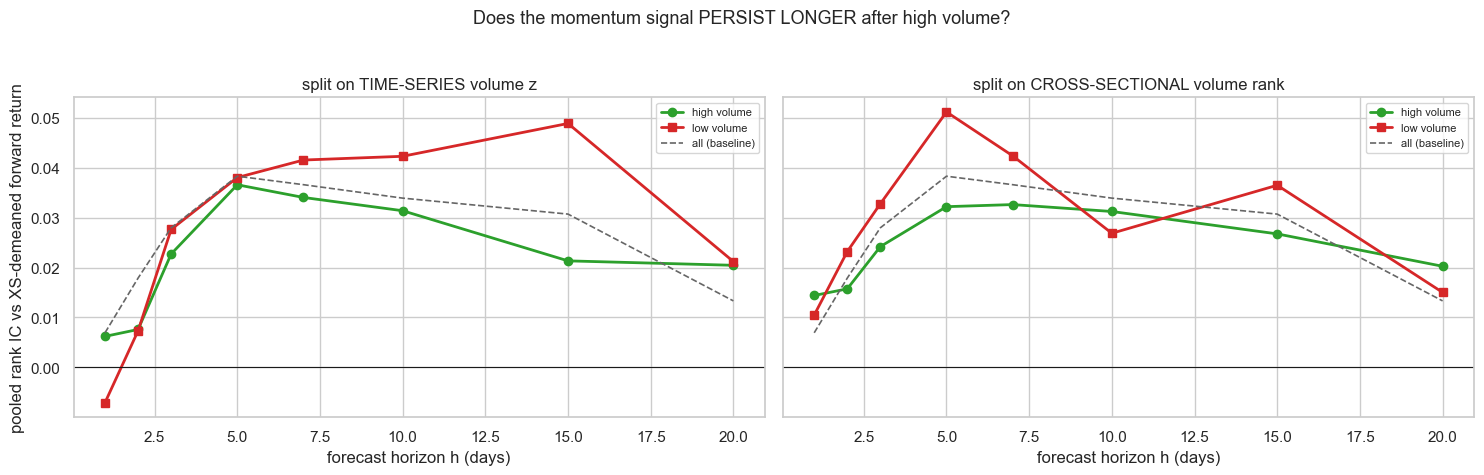

VERDICT: the persistence hypothesis is NOT supported.
  * TIME-SERIES split: at h=15 the LOW-volume IC is 0.0489 versus 0.0213 for high volume -- the low-volume signal persists LONGER,
    the opposite of the prediction.
  * CROSS-SECTIONAL split: the two curves are tangled; b2 is negative at every horizon
    past h=1 and never significant (best |t| = 1.24).
  * The two definitions disagree in SIGN (TS interaction positive, XS negative) and neither
    clears significance. A result that flips with a reasonable redefinition of the
    conditioning variable is not a result.
  * The relationship is also NON-MONOTONE: under the TS split the MID bucket has the highest
    IC at short horizons (h=5: mid 0.0545 vs low 0.0380, high 0.0366).
    That is why a linear interaction term and a tercile split disagree -- and why the earlier
    positive LMSW coefficient should not be over-read.

WHAT DOES SURVIVE: the momentum signal's OWN decay profile, which is robust across both
  panels -- IC bui

In [28]:
# --- Signal decay, split by volume, both definitions ---------------------------
N_E  = BEST_N
sigE = np.log(XS_PX).diff().rolling(N_E).sum().shift(1)
srkE = sigE.rank(axis=1, pct=True) - 0.5              # the signal we actually trade
vz_ts = vz                                            # time-series z (already lagged)
vz_xs = vz_ts.rank(axis=1, pct=True) - 0.5            # cross-sectional rank of it

# how coin-specific is the time-series label, really?
_hi = train_only(vz_ts) > train_only(vz_ts).stack().quantile(2/3)
print(f'TS split: {(_hi.sum(axis=1) >= 7).mean():.1%} of days put 7+ of 9 coins in the HIGH bucket, '
      f'{(_hi.sum(axis=1) == 0).mean():.1%} put none.')
print('  => the time-series label is substantially a DAY label (market-wide volume waves),')
print('     which is exactly why the cross-sectional version is worth running alongside it.\n')

HS_E = [1, 2, 3, 5, 7, 10, 15, 20]

def decay_curve(cond, label):
    c = train_only(cond)
    lo_t, hi_t = c.stack().quantile([1/3, 2/3])
    out = {}
    for h in HS_E:
        fwd = XS_R.rolling(h).sum().shift(-h)
        fwd = fwd.sub(fwd.mean(axis=1), axis=0)       # XS-demeaned: what a neutral book earns on
        d = pd.concat([train_only(srkE).stack().rename('s'),
                       train_only(fwd).stack().rename('f'),
                       c.stack().rename('v')], axis=1).dropna()
        d['g'] = np.where(d.v > hi_t, 'high', np.where(d.v < lo_t, 'low', 'mid'))
        out[h] = {g: d[d.g == g].s.corr(d[d.g == g].f, method='spearman') for g in ['low', 'mid', 'high']}
        out[h]['all'] = d.s.corr(d.f, method='spearman')
    T = pd.DataFrame(out).T; T.index.name = 'horizon_h'
    print(f'--- pooled rank IC by horizon, split on {label} ---')
    display(T.round(4))
    return T

T_ts = decay_curve(vz_ts, 'TIME-SERIES volume z')
T_xs = decay_curve(vz_xs, 'CROSS-SECTIONAL volume rank')

def interaction(cond, label):
    rows = {}
    for h in HS_E:
        fwd = XS_R.rolling(h).sum().shift(-h); fwd = fwd.sub(fwd.mean(axis=1), axis=0)
        d = pd.concat([train_only(srkE).stack().rename('s'),
                       train_only(fwd).stack().rename('f'),
                       train_only(cond).stack().rename('v')], axis=1).dropna()
        d['sv'] = d.s * d.v; d['date'] = d.index.get_level_values(0)
        d = d.sort_values('date')
        f = sm.OLS(d.f * 1e4, sm.add_constant(d[['s', 'sv']])).fit(
            cov_type='hac-groupsum', cov_kwds={'time': pd.factorize(d.date)[0], 'maxlags': max(h, 1)})
        rows[h] = {'b1_momentum': f.params['s'], 't_b1': f.tvalues['s'],
                   'b2_interaction': f.params['sv'], 't_b2': f.tvalues['sv']}
    T = pd.DataFrame(rows).T; T.index.name = 'h'
    print(f'\ninteraction regression, {label} (overlap-robust SEs):')
    display(T.round(2))
    return T

I_ts = interaction(vz_ts, 'TIME-SERIES')
I_xs = interaction(vz_xs, 'CROSS-SECTIONAL')

fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), sharey=True)
for a, (T, lbl) in zip(ax, [(T_ts, 'TIME-SERIES volume z'), (T_xs, 'CROSS-SECTIONAL volume rank')]):
    for g, col, mk_ in [('high', 'tab:green', 'o'), ('low', 'tab:red', 's')]:
        a.plot(T.index, T[g], marker=mk_, color=col, lw=2, label=f'{g} volume')
    a.plot(T.index, T['all'], color='0.4', ls='--', lw=1.2, label='all (baseline)')
    a.axhline(0, color='k', lw=.8); a.set_xlabel('forecast horizon h (days)')
    a.set_title(f'split on {lbl}'); a.legend(fontsize=8)
ax[0].set_ylabel('pooled rank IC vs XS-demeaned forward return')
fig.suptitle('Does the momentum signal PERSIST LONGER after high volume?', y=1.03, fontsize=13)
fig.tight_layout(); plt.show()

print('VERDICT: the persistence hypothesis is NOT supported.')
print(f'  * TIME-SERIES split: at h=15 the LOW-volume IC is {T_ts.loc[15,"low"]:.4f} versus '
      f'{T_ts.loc[15,"high"]:.4f} for high volume -- the low-volume signal persists LONGER,')
print('    the opposite of the prediction.')
print(f'  * CROSS-SECTIONAL split: the two curves are tangled; b2 is negative at every horizon')
print(f'    past h=1 and never significant (best |t| = {I_xs.t_b2.abs().max():.2f}).')
print('  * The two definitions disagree in SIGN (TS interaction positive, XS negative) and neither')
print('    clears significance. A result that flips with a reasonable redefinition of the')
print('    conditioning variable is not a result.')
print(f'  * The relationship is also NON-MONOTONE: under the TS split the MID bucket has the highest')
print(f'    IC at short horizons (h=5: mid {T_ts.loc[5,"mid"]:.4f} vs low {T_ts.loc[5,"low"]:.4f}, '
      f'high {T_ts.loc[5,"high"]:.4f}).')
print('    That is why a linear interaction term and a tercile split disagree -- and why the earlier')
print('    positive LMSW coefficient should not be over-read.')
print()
print('WHAT DOES SURVIVE: the momentum signal\'s OWN decay profile, which is robust across both')
print(f'  panels -- IC builds to a peak around h=5-7 (b1 t-stat peaks at {I_ts.t_b1.max():.2f}) and')
print('  fades after h~15. That is the third independent measurement pointing at a multi-day hold,')
print('  and it is the part worth carrying into the cost analysis.')


---
# Transaction costs — and the holding period they select

Everything above is **gross**. That is the right way to research a signal (costs are a property of the
*implementation*, not of the edge) but it is not a result. A dollar-neutral book with 25% daily turnover
pays for that turnover every single day, and at the course's cost assumption the bill is large enough to
change which configuration we should actually run.

**Cost model.** The course brief assumes a market order costs **20 bps all-in** (7 bps commission +
13 bps assumed slippage). That is charged *per dollar traded*, so the daily drag is

$$\text{cost}_t = c \times \text{turnover}_t = c \sum_i |w_{i,t} - w_{i,t-1}|$$

with $c = 0.0020$. This is deliberately pessimistic for our universe: the nine coins here have measured
**real spreads under 10 bps**, so a patient limit order would pay closer to the 7 bps commission-only
figure. We report 20 bps as the headline anyway — it is the course convention and it is the number a
skeptic would insist on — and then show the whole cost curve so the result does not live or die on one
assumption.

**Timing.** P&L is `w.shift(1) * r`, i.e. the position held into day *t* was set at the close of *t−1*.
The trade that established it is therefore $|w_{t-1} - w_{t-2}|$, so the cost charged against day *t*
is `turnover(w).shift(1)`. Getting this off by one day would flatter the result at exactly the horizons
where turnover is highest.

**What we are deciding.** Only the holding period *h*. The lookback **n = 15 stays fixed at the value
selected on gross TRAIN Sharpe** — re-optimizing both parameters against a cost-aware objective would be
a second selection pass over the same 45 cells, and every bit of that is extra overfitting. Costs enter
as a *penalty on a decision already made*, not as a new search.

**The honest framing: break-even cost.** Rather than only asking "does it survive 20 bps?", ask "what
cost would it survive?" — $c^* = \bar{r}_{\text{gross}} / \overline{\text{turnover}}$. That single number
is the cost-robustness of the strategy, and it is the number worth quoting, because it does not depend on
believing any particular slippage assumption.


In [29]:
# --- Net-of-cost P&L at the course baseline -----------------------------------
COST_BPS = PROJECT_COST_ASSUMPTION['market_all_in_bps']      # 20 = 7 commission + 13 slippage

def cost_series(w, cost_bps=COST_BPS):
    """Cost charged on day t for the rebalance that established the position earning r_t.

    P&L is w.shift(1) * r, so the trade being priced here is |w_{t-1} - w_{t-2}|, hence the
    extra .shift(1) on turnover. Off-by-one here would under-charge the fastest configs most.
    """
    return turnover(w).shift(1) * bps(cost_bps)

def xs_net(n, h=1, cost_bps=COST_BPS, signal=trailing_return):
    """TRAIN gross returns, cost drag and weights for one (n, h), on a common index."""
    g, w = xs_pnl(n, h, signal)
    g = train_only(g).dropna()
    return g, cost_series(w, cost_bps).reindex(g.index).fillna(0), train_only(w)

# --- the decision: holding period, with n fixed at the gross-selected value ---
rows = {}
for h in HS:
    g, c, w = xs_net(BEST_N, h)
    net = g - c
    rows[h] = {'gross_SR':      sharpe(g),
               'net_SR':        sharpe(net),
               'turnover':      turnover(w).mean(),
               'gross_ann':     g.mean() * ANN_TRADING,
               'cost_ann':      c.mean() * ANN_TRADING,
               'net_ann':       net.mean() * ANN_TRADING,
               'breakeven_bps': g.mean() / c.mean() * COST_BPS,
               'net_maxdd':     max_drawdown(net)}
h_ladder = pd.DataFrame(rows).T
h_ladder.index.name = 'hold_h'
print(f'=== n={BEST_N}, cost = {COST_BPS:.0f} bps per dollar traded, TRAIN ===')
display(h_ladder.round(3))

NET_H = int(h_ladder['net_SR'].idxmax())
print(f'gross-best h = {BEST_H} (SR {h_ladder.loc[BEST_H, "gross_SR"]:.2f}) '
      f'-> net SR {h_ladder.loc[BEST_H, "net_SR"]:.2f}')
print(f'net-best   h = {NET_H} (SR {h_ladder.loc[NET_H, "net_SR"]:.2f}), '
      f'gross SR {h_ladder.loc[NET_H, "gross_SR"]:.2f}')
print(f'\nTurnover falls roughly like 1/h ({turnover(xs_net(BEST_N, 1)[2]).mean():.3f} at h=1 -> '
      f'{turnover(xs_net(BEST_N, 10)[2]).mean():.3f} at h=10) while gross Sharpe is nearly flat')
print(f'across h=2..10. That asymmetry is the whole argument: holding longer costs almost no')
print(f'signal and saves most of the bill. Concretely, choosing h={BEST_H} over h={NET_H} buys')
print(f'{h_ladder.loc[BEST_H, "gross_ann"] - h_ladder.loc[NET_H, "gross_ann"]:+.1%}/yr of extra GROSS '
      f'return and pays {h_ladder.loc[BEST_H, "cost_ann"] - h_ladder.loc[NET_H, "cost_ann"]:+.1%}/yr of '
      f'extra COST -- a net loss of '
      f'{h_ladder.loc[NET_H, "net_ann"] - h_ladder.loc[BEST_H, "net_ann"]:.1%}/yr.')
print(f'\nh=1 is the cautionary case: gross SR {h_ladder.loc[1, "gross_SR"]:.2f} but net '
      f'{h_ladder.loc[1, "net_SR"]:+.2f} -- the edge is entirely a rebate to the exchange.')


=== n=15, cost = 20 bps per dollar traded, TRAIN ===


,gross_SR,net_SR,turnover,gross_ann,cost_ann,net_ann,breakeven_bps,net_maxdd
hold_h,,,,,,,,
1,0.8000,-0.1030,0.3710,0.1650,0.1870,-0.0210,17.7200,-0.4090
2,0.8970,0.2780,0.2530,0.1840,0.1270,0.0570,28.9730,-0.3110
3,0.8280,0.3260,0.2020,0.1670,0.1010,0.0660,33.0080,-0.2650
5,0.8550,0.4600,0.1510,0.1640,0.0760,0.0880,43.2890,-0.2310
10,0.7400,0.4260,0.1060,0.1240,0.0530,0.0720,47.0850,-0.2580


gross-best h = 2 (SR 0.90) -> net SR 0.28
net-best   h = 5 (SR 0.46), gross SR 0.85

Turnover falls roughly like 1/h (0.371 at h=1 -> 0.106 at h=10) while gross Sharpe is nearly flat
across h=2..10. That asymmetry is the whole argument: holding longer costs almost no
signal and saves most of the bill. Concretely, choosing h=2 over h=5 buys
+2.0%/yr of extra GROSS return and pays +5.1%/yr of extra COST -- a net loss of 3.1%/yr.

h=1 is the cautionary case: gross SR 0.80 but net -0.10 -- the edge is entirely a rebate to the exchange.


In [30]:
# --- Does the cost assumption itself change the answer? ------------------------
# The h choice is only meaningful if it survives disagreement about the cost number.
COST_LADDER = [0, 7, 20, 35, 50, 100]
sens = {}
for cb in COST_LADDER:
    sens[cb] = {h: sharpe(xs_net(BEST_N, h, cb)[0] - xs_net(BEST_N, h, cb)[1]) for h in HS}
sens = pd.DataFrame(sens).T
sens.index.name, sens.columns.name = 'cost_bps', 'hold_h'
print(f'=== net TRAIN Sharpe, n={BEST_N}: cost assumption x holding period ===')
display(sens.round(2))
print(f'Each row picks a different winner only at the extremes: h={sens.loc[0].idxmax()} at 0 bps '
      f'(no reason to hold), h={sens.loc[20].idxmax()} at 20, h={sens.loc[50].idxmax()} at 50.')
print(f'Between 7 and 50 bps the answer is stable at h={NET_H} or longer, so the choice is not an')
print('artifact of believing exactly 20 bps. Below ~7 bps the ranking flips toward fast trading,')
print('which is the regime a maker-only implementation would actually live in -- worth remembering')
print('if execution is ever built out, but not something to design the backtest around.')

# --- the full (n x h) net grid: where does the cost penalty move the optimum? ---
net_grid = pd.DataFrame({h: {n: sharpe(xs_net(n, h)[0] - xs_net(n, h)[1]) for n in NS} for h in HS})
net_grid.index.name, net_grid.columns.name = 'lookback_n', 'hold_h'
print(f'\n=== net TRAIN Sharpe at {COST_BPS:.0f} bps, full grid (NOT a selection -- see note) ===')
display(net_grid.round(2))
_nb_n, _nb_h = net_grid.stack().idxmax()
print(f'net argmax over all 45 cells: n={_nb_n}, h={_nb_h} (SR {net_grid.stack().max():.2f}) '
      f'vs our chosen n={BEST_N}, h={NET_H} (SR {net_grid.loc[BEST_N, NET_H]:.2f}).')
print(f'We are NOT taking that cell. A cost penalty is monotone in turnover, so the net-optimal')
print(f'config always drifts toward longer lookbacks and longer holds -- the grid corner is partly')
print(f'mechanical, not evidence that n={_nb_n} is a better signal. Re-picking n here would also mean')
print(f'a second optimization pass over cells we already mined once. Logged as an observation.')
print(f'\nfraction of grid still positive net of {COST_BPS:.0f} bps: '
      f'{(net_grid.stack() > 0).mean():.0%} (was {(xs_grid.stack() > 0).mean():.0%} gross)')


=== net TRAIN Sharpe, n=15: cost assumption x holding period ===


hold_h,1,2,3,5,10
cost_bps,,,,,
0,0.8000,0.9000,0.8300,0.8500,0.7400
7,0.4800,0.6800,0.6500,0.7200,0.6300
20,-0.1000,0.2800,0.3300,0.4600,0.4300
35,-0.7800,-0.1900,-0.0500,0.1600,0.1900
50,-1.4500,-0.6500,-0.4300,-0.1300,-0.0500
100,-3.6400,-2.1800,-1.6700,-1.1200,-0.8300


Each row picks a different winner only at the extremes: h=2 at 0 bps (no reason to hold), h=5 at 20, h=10 at 50.
Between 7 and 50 bps the answer is stable at h=5 or longer, so the choice is not an
artifact of believing exactly 20 bps. Below ~7 bps the ranking flips toward fast trading,
which is the regime a maker-only implementation would actually live in -- worth remembering
if execution is ever built out, but not something to design the backtest around.



=== net TRAIN Sharpe at 20 bps, full grid (NOT a selection -- see note) ===


hold_h,1,2,3,5,10
lookback_n,,,,,
3,-1.1000,-0.9700,-1.0400,-0.5600,-0.3400
5,-1.1700,-0.4000,-0.3700,-0.3000,0.0800
10,-0.5400,-0.0400,0.0400,0.2200,0.3300
15,-0.1000,0.2800,0.3300,0.4600,0.4300
20,-0.0300,0.2300,0.3000,0.3300,0.3100
30,-0.1300,0.0600,0.0600,0.0300,0.0400
45,-0.5700,-0.1700,-0.1200,0.0000,0.1300
60,0.0900,0.1900,0.2100,0.1700,-0.0100
90,0.2100,0.3800,0.4000,0.4500,0.5300


net argmax over all 45 cells: n=90, h=10 (SR 0.53) vs our chosen n=15, h=5 (SR 0.46).
We are NOT taking that cell. A cost penalty is monotone in turnover, so the net-optimal
config always drifts toward longer lookbacks and longer holds -- the grid corner is partly
mechanical, not evidence that n=90 is a better signal. Re-picking n here would also mean
a second optimization pass over cells we already mined once. Logged as an observation.

fraction of grid still positive net of 20 bps: 60% (was 100% gross)


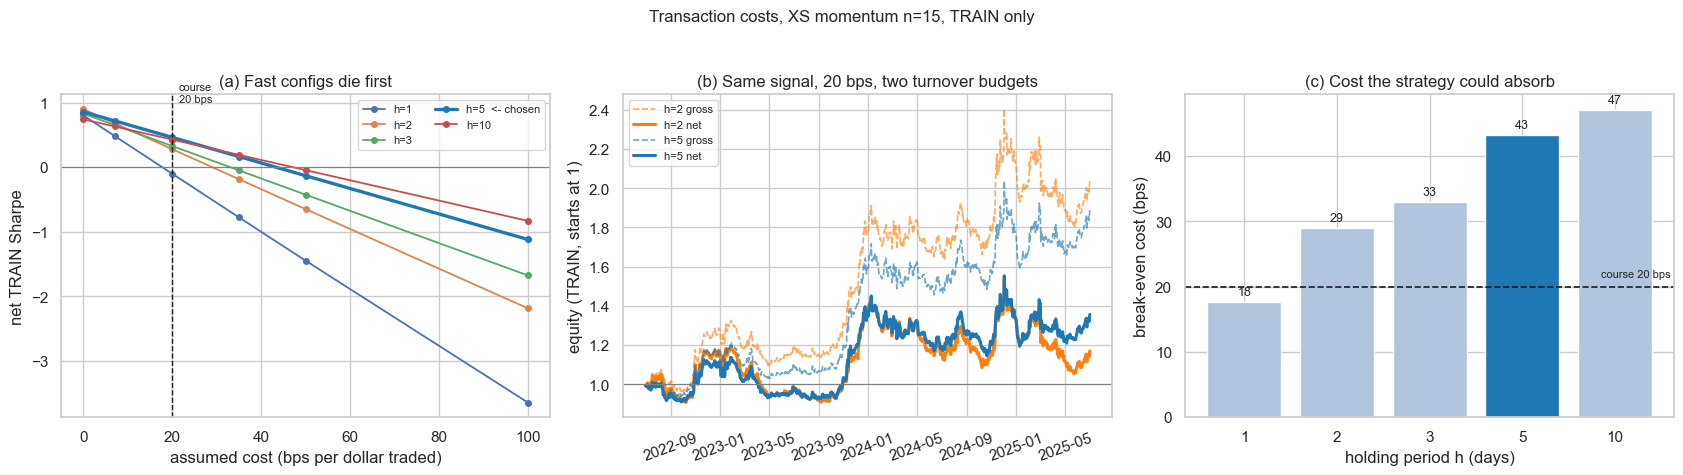

In [31]:
# --- The cost picture in three panels -----------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))

# (a) net Sharpe as a function of the cost assumption, one line per holding period
for h in HS:
    ax[0].plot(COST_LADDER, sens[h].values, marker='o', ms=4,
               lw=2.4 if h == NET_H else 1.3,
               color='tab:blue' if h == NET_H else None,
               label=f'h={h}' + ('  <- chosen' if h == NET_H else ''))
ax[0].axvline(COST_BPS, color='k', ls='--', lw=1)
ax[0].text(COST_BPS + 1.5, ax[0].get_ylim()[1] * 0.9, 'course\n20 bps', fontsize=8)
ax[0].axhline(0, color='grey', lw=0.8)
ax[0].set(xlabel='assumed cost (bps per dollar traded)', ylabel='net TRAIN Sharpe',
          title='(a) Fast configs die first')
ax[0].legend(fontsize=8, ncol=2)

# (b) what 20 bps does to the equity curve, at the two candidate holding periods
for h, col in [(BEST_H, 'tab:orange'), (NET_H, 'tab:blue')]:
    g, c, _ = xs_net(BEST_N, h)
    ax[1].plot(equity_curve(g),     color=col, ls='--', lw=1.2, alpha=.65, label=f'h={h} gross')
    ax[1].plot(equity_curve(g - c), color=col, lw=2.2,             label=f'h={h} net')
ax[1].axhline(1, color='grey', lw=0.8)
ax[1].set(ylabel='equity (TRAIN, starts at 1)',
          title=f'(b) Same signal, {COST_BPS:.0f} bps, two turnover budgets')
ax[1].legend(fontsize=8)
ax[1].tick_params(axis='x', rotation=20)

# (c) break-even cost: how wrong can the 20 bps assumption be?
be = h_ladder['breakeven_bps']
bars = ax[2].bar([str(h) for h in be.index], be.values,
                 color=['tab:blue' if h == NET_H else 'lightsteelblue' for h in be.index])
ax[2].axhline(COST_BPS, color='k', ls='--', lw=1.2)
ax[2].text(len(be) - 0.4, COST_BPS + 1.5, 'course 20 bps', fontsize=8, ha='right')
for b, v in zip(bars, be.values):
    ax[2].text(b.get_x() + b.get_width() / 2, v + 1, f'{v:.0f}', ha='center', fontsize=9)
ax[2].set(xlabel='holding period h (days)', ylabel='break-even cost (bps)',
          title='(c) Cost the strategy could absorb')

fig.suptitle(f'Transaction costs, XS momentum n={BEST_N}, TRAIN only', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()


In [32]:
# --- Final TRAIN specification, reported the way the project asks for it -------
btc_bm = train_only(XS_R['BTCUSDT'])

strats, ports = {}, {}
for h in [BEST_H, NET_H]:
    g, c, w = xs_net(BEST_N, h)
    strats[f'n{BEST_N}_h{h}_gross'] = g
    strats[f'n{BEST_N}_h{h}_net']   = g - c
    ports[f'n{BEST_N}_h{h}_gross']  = w
    ports[f'n{BEST_N}_h{h}_net']    = w

final = summary_table(strats, ports=ports, benchmark=btc_bm)
print(f'=== TRAIN {DATA_START.date()} -> {SPLIT_DATE.date()}, cost = {COST_BPS:.0f} bps ===')
display(final.round(3))

print(f'Cost is close to deterministic, so it moves the mean and barely touches the vol: the net')
print(f'Sharpe drop is almost entirely a return effect. Max drawdown improves at h={NET_H} '
      f'({h_ladder.loc[NET_H, "net_maxdd"]:.1%} vs {h_ladder.loc[BEST_H, "net_maxdd"]:.1%} at '
      f'h={BEST_H}) for the same reason: fewer, smaller rebalances.')
print(f'\nThe cost that matters for interpretation: alpha_t falls from '
      f'{final.loc[final.index[2], "alpha_t"]:.2f} gross to '
      f'{final.loc[final.index[3], "alpha_t"]:.2f} net at h={NET_H}. Net of the course cost')
print(f'assumption this is a POSITIVE but NOT statistically significant alpha on TRAIN. That is the')
print(f'honest headline, and it is the number to carry into validation rather than the gross 0.9.')

print(f'\n--- FROZEN SPECIFICATION ---')
print(f'  universe   {len(XS_UNIVERSE)} coins, real spread < 10 bps')
print(f'  signal     rank({BEST_N}d trailing return) -> demean -> normalize to gross 1')
print(f'  holding    h = {NET_H} days, overlapping tranches')
print(f'  cost       {COST_BPS:.0f} bps per dollar traded (break-even '
      f'{h_ladder.loc[NET_H, "breakeven_bps"]:.0f} bps)')
print(f'  TRAIN      gross SR {h_ladder.loc[NET_H, "gross_SR"]:.2f} | '
      f'net SR {h_ladder.loc[NET_H, "net_SR"]:.2f} | turnover '
      f'{h_ladder.loc[NET_H, "turnover"]:.3f}/day | beta {final.loc[final.index[3], "beta"]:+.3f}')
print(f'  h was the ONLY parameter chosen with costs in view; n stayed at its gross-selected value.')
print(f'\nNote on the volume section above: it was run at the gross-selected h={BEST_H}. Its one')
print(f'surviving result -- conviction sizing preferring h=5 over h=2 -- now agrees with the cost')
print(f'analysis for a completely independent reason. Two separate arguments land on the same h.')


=== TRAIN 2022-07-01 -> 2025-07-01, cost = 20 bps ===


,ann_return,ann_vol,sharpe,avg_turnover,max_drawdown,max_dd_dur_days,alpha_ann,alpha_t,beta,corr
n15_h2_gross,0.1840,0.2060,0.8970,0.2530,-0.2490,286.0000,0.1960,1.9900,-0.0260,-0.0510
n15_h2_net,0.0570,0.2060,0.2780,0.2530,-0.3110,327.0000,0.0690,0.6970,-0.0250,-0.0500
n15_h5_gross,0.1640,0.1920,0.8550,0.1510,-0.2210,286.0000,0.1710,1.8550,-0.0150,-0.0320
n15_h5_net,0.0880,0.1920,0.4600,0.1510,-0.2310,317.0000,0.0950,1.0310,-0.0150,-0.0310


Cost is close to deterministic, so it moves the mean and barely touches the vol: the net
Sharpe drop is almost entirely a return effect. Max drawdown improves at h=5 (-23.1% vs -31.1% at h=2) for the same reason: fewer, smaller rebalances.

The cost that matters for interpretation: alpha_t falls from 1.85 gross to 1.03 net at h=5. Net of the course cost
assumption this is a POSITIVE but NOT statistically significant alpha on TRAIN. That is the
honest headline, and it is the number to carry into validation rather than the gross 0.9.

--- FROZEN SPECIFICATION ---
  universe   9 coins, real spread < 10 bps
  signal     rank(15d trailing return) -> demean -> normalize to gross 1
  holding    h = 5 days, overlapping tranches
  cost       20 bps per dollar traded (break-even 43 bps)
  TRAIN      gross SR 0.85 | net SR 0.46 | turnover 0.151/day | beta -0.015
  h was the ONLY parameter chosen with costs in view; n stayed at its gross-selected value.

Note on the volume section above: it was ru

### What this section changed

| | before costs | after costs |
|---|---|---|
| holding period | h = 2 (gross argmax) | **h = 5** |
| headline Sharpe | 0.90 gross | **0.46 net** at 20 bps |
| alpha t-stat | ~2 | ~1 — positive, **not significant** |
| turnover | 0.25 / day | 0.15 / day |

This is the outcome the mentor pre-authorised: *"If the strategy ends up with a lower net Sharpe after
realistic costs, that's completely fine."* A 0.46 net Sharpe on a dollar-neutral book with ~0 BTC beta is
a real, defensible result; a 0.90 that quietly ignores a 12%/yr trading bill is not.

Three things this does **not** yet establish, all still open:

1. **h = 5 was chosen on TRAIN.** It is a train-selected parameter like any other and has to be carried
   into validation as-is, not re-tuned there.
2. **The cost model is flat.** 20 bps per dollar traded takes no view on which coin is being traded, even
   though our own measured spreads run from ~1 bp on BTC to ~10 bps at the edge of the universe. A
   per-symbol cost using `real_spread` would be more realistic — and would also inherit the
   look-ahead problem flagged in the universe-selection note, since those spreads were measured in 2026.
3. **Turnover is measured, not managed.** Nothing here tries to *reduce* turnover at a given h (no
   no-trade band, no trade-size threshold). That is the obvious lever if net Sharpe needs rescuing, and
   it is a much cheaper improvement than a new signal.


---
# Robustness: sampling and universe

Two ingredients of the frozen specification were choices made with information we would not have had at
the time:

1. **The sample starts at 2022-07-01**, dropping 2022-H1 because BTC crashed. But this book is
   dollar-neutral — BTC's *direction* is exactly what it hedges out — so that reason is suspect.
2. **The universe is the nine coins whose order-book spread measured under 10 bps** — measured in
   **2026**, then applied back to 2022. That is a look-ahead.

A third problem cannot be fixed here: **survivorship**. All 60 coins first list in 2022, so the panel is
the *current* Binance.US listing set and any coin delisted between 2022 and 2026 is simply absent. The
bias favours momentum. It is weaker for a dollar-neutral book that ranks *within* the survivors than for a
long-only one, but it is not zero. Stated, not solved.

**The test for (1) and (2):** re-run the frozen spec (n=15, h=5, 20 bps) **unchanged** on a different
slice, and see whether the Sharpe moves. Nothing is re-optimized. For (2) the alternative is a
point-in-time universe — each day, the top nine coins by **trailing 90-day median dollar volume**, lagged
one day, so it uses only information available at the time.


=== frozen spec n=15, h=5, NET of 20 bps, through 2025-07-01 ===


,sharpe,ann_return,ann_vol,avg_turnover,max_drawdown,beta,corr
"headline (spread < 10 bps, from 2022-07)",0.4600,0.0880,0.1920,0.1510,-0.2310,-0.0150,-0.0310
+ 2022-H1 (from 2022-01),0.4020,0.0770,0.1910,0.1480,-0.2310,-0.0290,-0.0670
point-in-time top-9 by $ volume,0.4740,0.0820,0.1720,0.1550,-0.2170,0.0050,0.0120


Sharpe moves by -0.06 with 2022-H1 put back, and by +0.01 under the point-in-time universe.
Both are an order of magnitude below the ~0.48 standard error of either estimate, so
neither choice is doing the work. (Descriptive only -- no formal test is being claimed.)
  PIT top-9 on 2022-07-01: ['ADA', 'APE', 'AVAX', 'BNB', 'BTC', 'ETH', 'SHIB', 'SOL', 'VET']
  PIT top-9 on 2025-06-01: ['ADA', 'BNB', 'BTC', 'DOGE', 'ETH', 'LINK', 'LTC', 'SOL', 'XLM']
  spread < 10 bps set : ['ADA', 'AVAX', 'BNB', 'BTC', 'DOGE', 'ETH', 'LTC', 'SOL', 'ZEC']


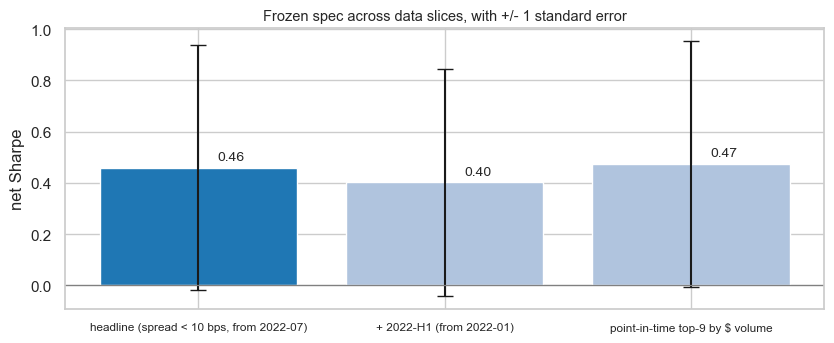

In [33]:
# --- Same frozen spec, three data slices: does the Sharpe move? ---------------
_dvol = (close * panel['Volume']).resample('1D').sum()          # dollar volume, all 60 coins
_med  = _dvol.rolling(90, min_periods=60).median().shift(1)     # trailing AND lagged: no lookahead

def pit_members(k):
    """Top-k by trailing 90d median dollar volume, re-formed daily. Point-in-time by construction."""
    return _med.rank(axis=1, ascending=False) <= k

def spec_run(cols, n, h, start, members=None, cost_bps=COST_BPS, end=SPLIT_DATE):
    """The frozen spec on an arbitrary universe/window. Returns (gross, cost, weights)."""
    PX  = dclose[cols]
    sig = np.log(PX).diff(n)
    if members is not None:
        sig = sig.where(members.reindex_like(sig).fillna(False))   # mask BEFORE ranking
    w = hold(xs_weights(sig).fillna(0.0), h)     # fillna BEFORE hold: departing coins decay out
    g = (w.shift(1) * PX.pct_change()).sum(axis=1).loc[start:end].dropna()
    c = (turnover(w).shift(1) * bps(cost_bps)).reindex(g.index).fillna(0)
    return g, c, w.loc[start:end]

SLICES = {
    'headline (spread < 10 bps, from 2022-07)': (XS_UNIVERSE,          DATA_START, None),
    '+ 2022-H1 (from 2022-01)':                 (XS_UNIVERSE,          FULL_START, None),
    'point-in-time top-9 by $ volume':          (list(dclose.columns), DATA_START, pit_members(9)),
}
strats, ports = {}, {}
for lbl, (cols, st, mem) in SLICES.items():
    g, c, w = spec_run(cols, BEST_N, NET_H, st, mem)
    assert w.sum(axis=1).abs().max() < 1e-9, f'{lbl}: book is not dollar-neutral'
    strats[lbl], ports[lbl] = g - c, w

rob_tab = summary_table(strats, ports=ports, benchmark=dclose['BTCUSDT'].pct_change())
print(f'=== frozen spec n={BEST_N}, h={NET_H}, NET of {COST_BPS:.0f} bps, through {SPLIT_DATE.date()} ===')
display(rob_tab[['sharpe', 'ann_return', 'ann_vol', 'avg_turnover', 'max_drawdown', 'beta', 'corr']].round(3))

_se  = {lbl: np.sqrt(ANN_TRADING / len(s)) for lbl, s in strats.items()}
_sr  = rob_tab['sharpe']
_hd  = _sr.index[0]
print(f'Sharpe moves by {_sr.iloc[1] - _sr.iloc[0]:+.2f} with 2022-H1 put back, and by '
      f'{_sr.iloc[2] - _sr.iloc[0]:+.2f} under the point-in-time universe.')
print(f'Both are an order of magnitude below the ~{_se[_hd]:.2f} standard error of either estimate, so')
print('neither choice is doing the work. (Descriptive only -- no formal test is being claimed.)')
_m9 = pit_members(9)
for _t in ['2022-07-01', '2025-06-01']:
    _ts = pd.Timestamp(_t, tz=TZ)
    print(f'  PIT top-9 on {_t}: {sorted(c[:-4] for c in _m9.columns[_m9.loc[_ts]])}')
print(f'  spread < 10 bps set : {sorted(c[:-4] for c in XS_UNIVERSE)}')

fig, ax = plt.subplots(figsize=(8.5, 3.6))
_lbls = list(strats)
ax.bar(range(len(_lbls)), _sr.values, yerr=[_se[l] for l in _lbls], capsize=6,
       color=['tab:blue', 'lightsteelblue', 'lightsteelblue'], edgecolor='white')
for i, v in enumerate(_sr.values):
    ax.text(i + 0.08, v + 0.03, f'{v:.2f}', fontsize=10)
ax.axhline(0, color='grey', lw=.9)
ax.set_xticks(range(len(_lbls))); ax.set_xticklabels(_lbls, fontsize=8.5)
ax.set(ylabel='net Sharpe', title='Frozen spec across data slices, with +/- 1 standard error')
ax.title.set_fontsize(10.5)
plt.tight_layout(); plt.show()


---
# Testing the tilt hypothesis: the (λ × h) surface

**Hypothesis** (from Tests D and E above): sizing **down** on relative volume improves the momentum book.
Size = conviction × exp(λ · volZ); λ < 0 tilts away from high-volume names. The book goes through
`leg_norm`, so each leg stays at 0.5 gross and the book stays dollar-neutral.

The lookback is held at **n = 15**. Only the tilt λ and the holding period h vary, on TRAIN, net of the
20 bps course cost. The four panels read left to right as an accounting identity:

| panel | shows |
|---|---|
| (a) gross Sharpe | what the tilt does before trading costs |
| (b) Sharpe lost to costs | (a) − (c) |
| (c) net Sharpe | what is left after costs |
| (d) edge over no tilt | (c) minus the λ = 0 row at the same h |

(b) is a clean subtraction because the cost is close to deterministic: it shifts the mean return and
barely moves the volatility.

**Two construction notes.** First, **λ = 0 here is the conviction-sized `leg_norm` book**, not the
rank-demean headline from the cost section (≈0.44 vs 0.46 net at h=5). Every λ has to share one
construction, or a difference between rows would not be the tilt. Second, the signal uses a **single
lag**, matching `xs_pnl`. The Test D/E cells above lag one extra day, so their Sharpes run ~0.02 lower and
are not directly comparable to these.

The heatmaps also set the range of λ carried into the walk-forward.


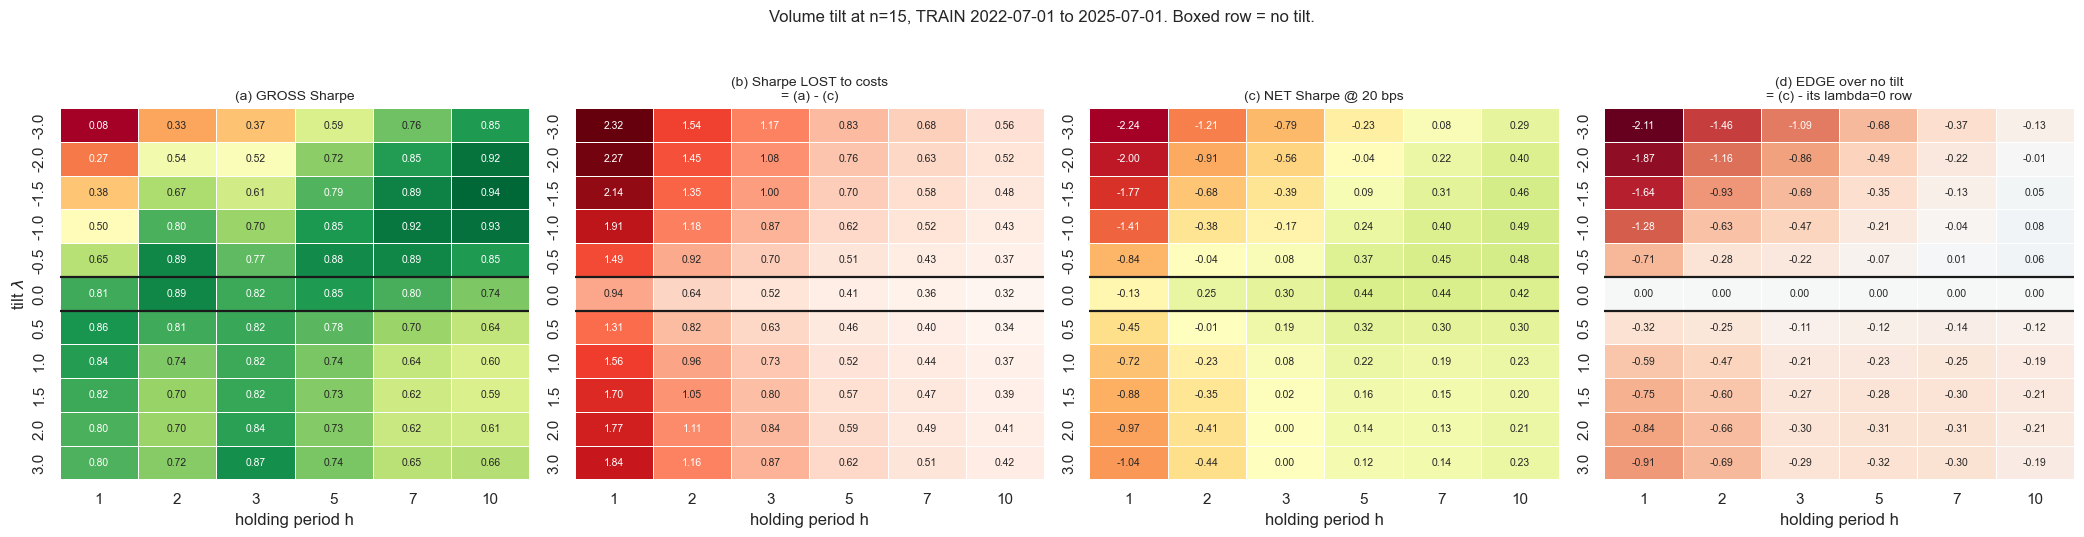

gross argmax  lambda=-1.5, h=10  SR 0.94
net   argmax  lambda=-1.0, h=10  SR 0.49   | no tilt at h=5: 0.44
edge  argmax  lambda=-1.0, h=10  edge +0.08   | edge at h=5, best lambda: -0.07

The mechanism behind (b): turnover is symmetric in |lambda| -- at h=1, lambda=-1 turns over 0.809/day and lambda=+1 turns over 0.778/day. The cost tracks how HARD
you lean on the volume z-score, not which way, because the churn comes from the z-score moving.

=== lambda range for the walk-forward: [-1, -0.5, 0, 0.5, 1] ===
net Sharpe at the frozen h=5:
  lambda=-2.0  net -0.04  lost to costs 0.76   excluded
  lambda=-1.5  net +0.09  lost to costs 0.70   excluded
  lambda=-1.0  net +0.24  lost to costs 0.62   carried
  lambda=-0.5  net +0.37  lost to costs 0.51   carried
  lambda=+0.0  net +0.44  lost to costs 0.41   carried
  lambda=+0.5  net +0.32  lost to costs 0.46   carried
  lambda=+1.0  net +0.22  lost to costs 0.52   carried
  lambda=+1.5  net +0.16  lost to costs 0.57   excluded
  lambda=+2.0 

In [34]:
# --- The (lambda x h) surface at n=15: gross, cost, net, edge -----------------
_sig1  = np.log(XS_PX).diff(BEST_N)                 # SINGLE lag, matching xs_pnl
_rk1   = _sig1.rank(axis=1, pct=True) - 0.5
_sgn1, _conv1 = np.sign(_rk1), _rk1.abs()

def tilt_book(l):
    """Daily conviction-sized book with volume tilt lambda. l=0 is the untilted conviction book."""
    return leg_norm(_sgn1, _conv1) if l == 0 else leg_norm(_sgn1, _conv1 * np.exp(l * vzx))

def tilt_series(l, h):
    """Full-history daily (gross, net, weights) for tilt l held h days. Shared with the walk-forward."""
    w = hold(tilt_book(l), h)
    g = (w.shift(1) * XS_R).sum(axis=1)
    return g, g - turnover(w).shift(1) * bps(COST_BPS), w

LAM_GRID = [-3, -2, -1.5, -1, -0.5, 0, 0.5, 1, 1.5, 2, 3]
H_GRID   = [1, 2, 3, 5, 7, 10]
_S = {}
for l in LAM_GRID:
    assert tilt_book(l).sum(axis=1).abs().max() < 1e-9, f'lambda={l}: book is not dollar-neutral'
    for h in H_GRID:
        g, net, w = tilt_series(l, h)
        _S[(l, h)] = (sharpe(train_only(g).dropna()), sharpe(train_only(net).dropna()),
                      train_only(turnover(w)).mean())
GR = pd.DataFrame({h: {l: _S[(l, h)][0] for l in LAM_GRID} for h in H_GRID})
NE = pd.DataFrame({h: {l: _S[(l, h)][1] for l in LAM_GRID} for h in H_GRID})
TU = pd.DataFrame({h: {l: _S[(l, h)][2] for l in LAM_GRID} for h in H_GRID})
CO = GR - NE                                   # Sharpe lost to costs
ED = NE - NE.loc[0]                            # edge over no tilt, at the same h
for _d in (GR, NE, TU, CO, ED):
    _d.index.name, _d.columns.name = 'lambda', 'hold_h'

fig, ax = plt.subplots(1, 4, figsize=(21, 5.2))
_panels = [(GR, '(a) GROSS Sharpe',                 'RdYlGn', None),
           (CO, '(b) Sharpe LOST to costs\n= (a) - (c)', 'Reds', None),
           (NE, f'(c) NET Sharpe @ {COST_BPS:.0f} bps',  'RdYlGn', 0),
           (ED, '(d) EDGE over no tilt\n= (c) - its lambda=0 row', 'RdBu', 0)]
for a, (d, ttl, cm, ctr) in zip(ax, _panels):
    sns.heatmap(d, annot=True, fmt='.2f', cmap=cm, center=ctr, ax=a, cbar=False,
                annot_kws={'size': 7.5}, linewidths=.4, linecolor='white')
    a.set_title(ttl, fontsize=10)
    a.set_xlabel('holding period h')
    a.set_ylabel('tilt $\\lambda$' if a is ax[0] else '')
    _r = LAM_GRID.index(0)
    a.axhline(_r, color='k', lw=1.6); a.axhline(_r + 1, color='k', lw=1.6)
fig.suptitle(f'Volume tilt at n={BEST_N}, TRAIN {DATA_START.date()} to {SPLIT_DATE.date()}. '
             'Boxed row = no tilt.', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()

print(f'gross argmax  lambda={GR.stack().idxmax()[0]:+.1f}, h={GR.stack().idxmax()[1]:<3} SR {GR.stack().max():.2f}')
print(f'net   argmax  lambda={NE.stack().idxmax()[0]:+.1f}, h={NE.stack().idxmax()[1]:<3} SR {NE.stack().max():.2f}'
      f'   | no tilt at h={NET_H}: {NE.loc[0, NET_H]:.2f}')
print(f'edge  argmax  lambda={ED.stack().idxmax()[0]:+.1f}, h={ED.stack().idxmax()[1]:<3} edge {ED.stack().max():+.2f}'
      f'   | edge at h={NET_H}, best lambda: {ED[NET_H].drop(0).max():+.2f}')
print(f'\nThe mechanism behind (b): turnover is symmetric in |lambda| -- at h=1, lambda=-1 turns over '
      f'{TU.loc[-1, 1]:.3f}/day and lambda=+1 turns over {TU.loc[1, 1]:.3f}/day. The cost tracks how HARD')
print('you lean on the volume z-score, not which way, because the churn comes from the z-score moving.')

# --- the lambda range carried into the walk-forward ---
WF_LAMBDAS = [-1, -0.5, 0, 0.5, 1]
print(f'\n=== lambda range for the walk-forward: {WF_LAMBDAS} ===')
print(f'net Sharpe at the frozen h={NET_H}:')
for l in [-2, -1.5] + WF_LAMBDAS + [1.5, 2]:
    tag = 'carried' if l in WF_LAMBDAS else 'excluded'
    print(f'  lambda={l:+.1f}  net {NE.loc[l, NET_H]:+.2f}  lost to costs {CO.loc[l, NET_H]:.2f}   {tag}')
print('Beyond |lambda| = 1 the cost panel keeps climbing and net Sharpe falls toward zero on both sides,')
print('so those tilts are not worth carrying. This is a JUDGMENT made on TRAIN data, which overlaps')
print('most walk-forward windows -- listed as a bias in the walk-forward section.')


---
# Rolling walk-forward validation

**Why walk-forward only.** The old train/validation split at 2025-07-01 is **retired**. Earlier
exploratory work ran on the full sample, and a previous boundary sat inside that window, so it was never a
clean holdout. Rather than score a compromised holdout once, every configuration is scored across a
rolling sequence of windows through the end of the data. **This supersedes the "scored once" plan
described in the research protocol and cost sections above.**

| | |
|---|---|
| strategy | fixed **n = 15, h = 5**, 20 bps, conviction sizing × exp(λ · volZ) |
| tilts compared | **λ ∈ {−1, −0.5, 0, +0.5, +1}**, the range set by the heatmaps |
| window length | 12 months |
| step | 7 days |
| first window | 2023-01-01 (2022 gives the signals their history) |
| windows | **139**, the last running 2025-08-24 → 2026-08-24 |

Nothing is re-estimated inside a window — n, h and λ are all fixed — so unlike the textbook diagram there
is no train segment: each window is simply scored. This is a **rolling stability test of five fixed
strategies**.

**Three biases, stated before looking at the results.**

1. **n and h are in-sample for most windows.** They were chosen on 2022-07 → 2025-07, so only data after
   2025-07-01 is out-of-sample for them. The table reports that stretch in its own column.
2. **The λ range was chosen from the TRAIN heatmaps**, which overlap most of these windows.
3. **The windows are not independent.** Consecutive windows share 51 of 52 weeks. About 3.7 years of data
   holds roughly 3–4 *independent* 12-month windows, not 139. Per-window statistics such as "% of windows
   positive" describe stability over time; they are not a count of independent successes. A single
   window's Sharpe carries a standard error of about 0.83.


In [35]:
# --- Rolling windows: 12 months, stepped 7 days, fixed n=15 / h=5 ---------------
WF_START = pd.Timestamp('2023-01-01', tz=TZ)
WF_END   = dclose.index.max()
WF_SPAN  = pd.DateOffset(months=12)
WF_STEP  = pd.Timedelta(days=7)

WF_WINDOWS, _s = [], WF_START
while _s + WF_SPAN <= WF_END:
    WF_WINDOWS.append((_s, _s + WF_SPAN)); _s += WF_STEP
assert len(WF_WINDOWS) == 139, f'expected 139 windows, got {len(WF_WINDOWS)}'
assert WF_WINDOWS[0][0] == WF_START and all(e <= WF_END for _, e in WF_WINDOWS)

WF_NET, WF_W = {}, {}
for l in WF_LAMBDAS:
    _, WF_NET[l], WF_W[l] = tilt_series(l, NET_H)

# INVARIANT: this section and the heatmaps must be measuring the same book.
assert np.isclose(sharpe(train_only(WF_NET[0]).dropna()), NE.loc[0, NET_H], atol=1e-12), \
    'walk-forward lambda=0 book does not reproduce the heatmap -- constructions have drifted'

def _in(series, s, e):
    return series[(series.index >= s) & (series.index < e)].dropna()

for s, e in WF_WINDOWS:
    assert len(_in(WF_NET[0], s, e)) >= 360, f'window {s.date()} has too few days'

WIN_SR = pd.DataFrame({l: [sharpe(_in(WF_NET[l], s, e)) for s, e in WF_WINDOWS] for l in WF_LAMBDAS},
                      index=[s for s, _ in WF_WINDOWS])
WIN_SR.index.name, WIN_SR.columns.name = 'window_start', 'lambda'
print(f'{len(WF_WINDOWS)} windows, {WF_WINDOWS[0][0].date()} -> {WF_WINDOWS[-1][1].date()}; '
      f'invariant OK (lambda=0 reproduces the heatmap\'s h={NET_H} net Sharpe of {NE.loc[0, NET_H]:.3f})\n')

_btc = XS_R['BTCUSDT']
rows = {}
for l in WF_LAMBDAS:
    full = WF_NET[l].loc[WF_START:WF_END].dropna()
    post = WF_NET[l].loc[SPLIT_DATE:WF_END].dropna()
    ws   = WIN_SR[l]
    rows[f'{l:+.1f}'] = {
        'SR full span':          sharpe(full),
        'SR after 2025-07-01':   sharpe(post),
        'window SR mean':        ws.mean(),
        'window SR median':      ws.median(),
        'window SR std':         ws.std(),
        'window SR min':         ws.min(),
        'window SR max':         ws.max(),
        '% windows > 0':         (ws > 0).mean(),
        '% windows beat l=0':    np.nan if l == 0 else (ws > WIN_SR[0]).mean(),
        'turnover':              turnover(WF_W[l]).loc[WF_START:WF_END].mean(),
        'max drawdown':          max_drawdown(full),
        'beta vs BTC':           alpha_beta(full, _btc.reindex(full.index))['beta'],
    }
WF_TABLE = pd.DataFrame(rows).T
WF_TABLE.index.name = 'lambda'
print(f'=== n={BEST_N}, h={NET_H}, net of {COST_BPS:.0f} bps, {WF_START.date()} -> {WF_END.date()} ===')
display(WF_TABLE.round(3))
print(f'"SR after 2025-07-01" covers {len(WF_NET[0].loc[SPLIT_DATE:WF_END].dropna())} days -- the only stretch '
      f'out-of-sample for n and h (SE ~{np.sqrt(ANN_TRADING / len(WF_NET[0].loc[SPLIT_DATE:WF_END].dropna())):.2f}).')
print('Window statistics come from 139 heavily overlapping windows: read them as a picture of stability,')
print('not as 139 independent trials.')


139 windows, 2023-01-01 -> 2026-08-24; invariant OK (lambda=0 reproduces the heatmap's h=5 net Sharpe of 0.444)

=== n=15, h=5, net of 20 bps, 2023-01-01 -> 2026-08-28 ===


,SR full span,SR after 2025-07-01,window SR mean,window SR median,window SR std,window SR min,window SR max,% windows > 0,% windows beat l=0,turnover,max drawdown,beta vs BTC
lambda,,,,,,,,,,,,
-1.0,0.1270,-0.0620,0.5330,0.4030,0.4350,-0.3200,1.5420,0.9420,0.3310,0.2210,-0.3610,-0.0610
-0.5,0.3720,0.5020,0.7280,0.8050,0.4420,-0.2020,1.5440,0.9420,0.3960,0.1840,-0.3220,-0.0510
+0.0,0.5820,1.0730,0.8590,1.0350,0.5720,-0.3860,1.8300,0.9210,NaN,0.1500,-0.3080,-0.0360
+0.5,0.5740,1.3170,0.7640,0.8030,0.7240,-0.7490,1.9470,0.8060,0.3170,0.1830,-0.3200,-0.0210
+1.0,0.5290,1.3990,0.6600,0.6240,0.8180,-0.9820,2.0390,0.7270,0.3090,0.2220,-0.3670,-0.0080


"SR after 2025-07-01" covers 424 days -- the only stretch out-of-sample for n and h (SE ~0.77).
Window statistics come from 139 heavily overlapping windows: read them as a picture of stability,
not as 139 independent trials.


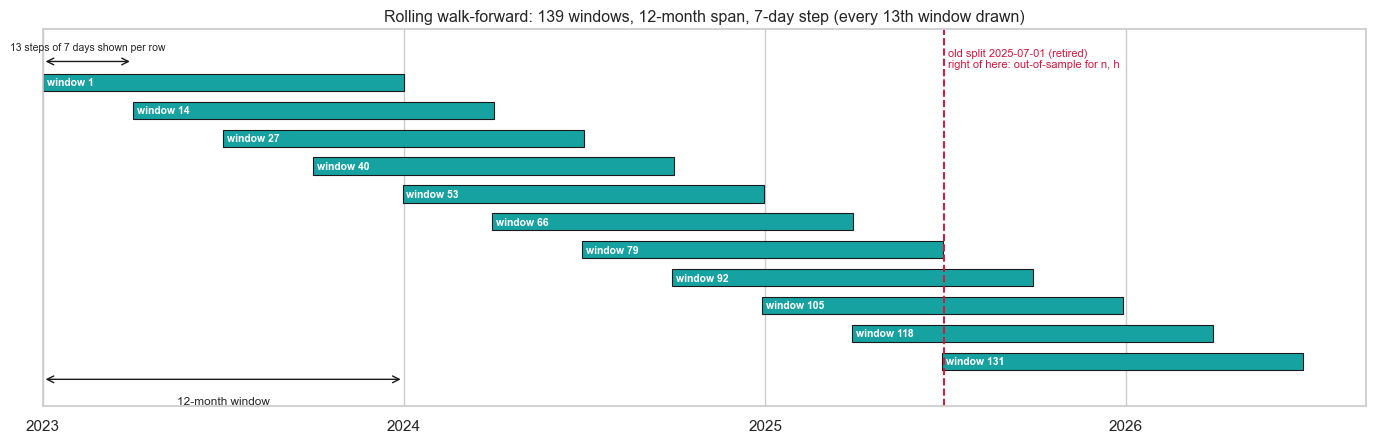

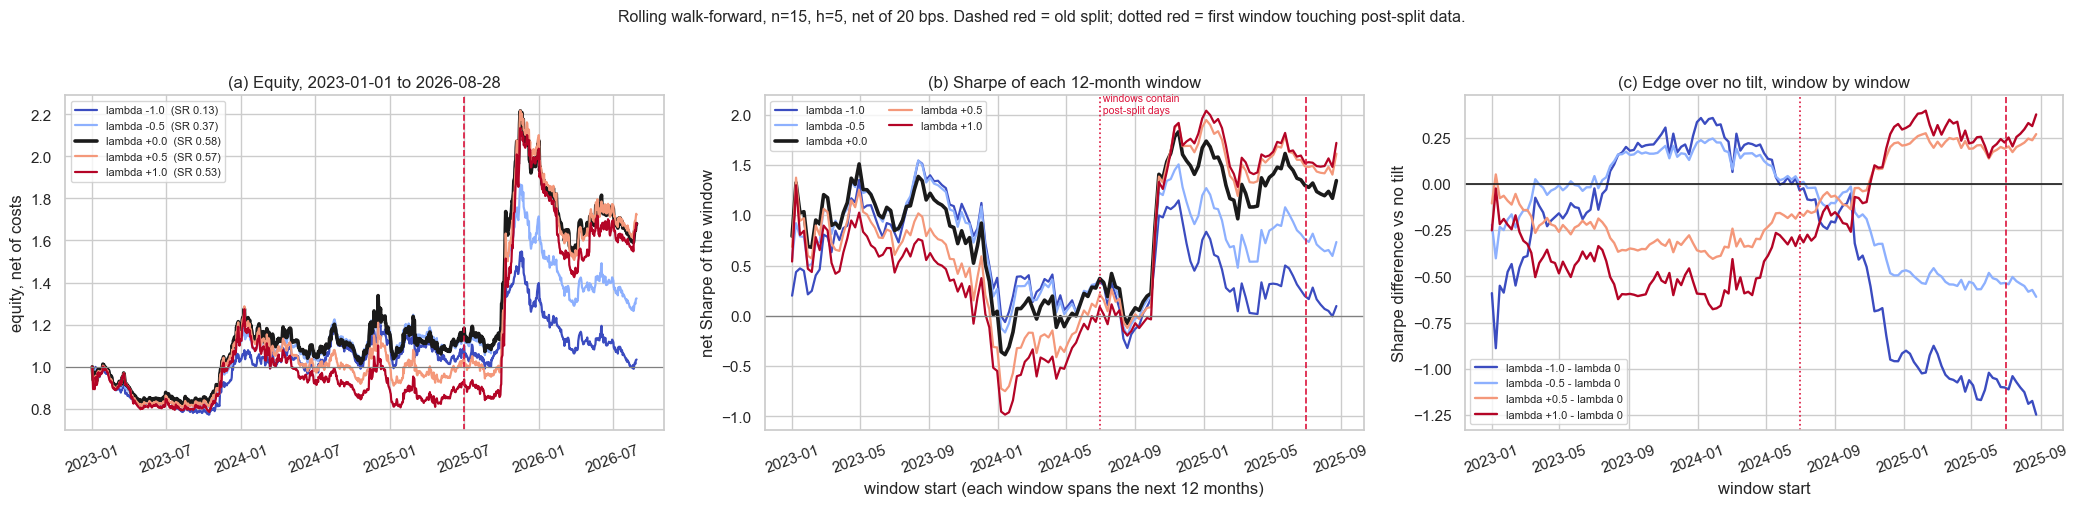

In [36]:
# --- The windows, drawn like a walk-forward diagram ---------------------------
import matplotlib.dates as mdates
_naive = lambda t: t.tz_convert(None).to_pydatetime()

fig, ax = plt.subplots(figsize=(14, 4.6))
_shown = list(range(0, len(WF_WINDOWS), 13))
for y, i in enumerate(_shown):
    s, e = WF_WINDOWS[i]
    left = mdates.date2num(_naive(s))
    ax.barh(y, mdates.date2num(_naive(e)) - left, left=left, height=0.62,
            color='#17a2a2', edgecolor='k', lw=0.8)
    ax.text(left + 4, y, f'window {i + 1}', va='center', fontsize=7.5, color='white', fontweight='bold')
_sp = mdates.date2num(_naive(SPLIT_DATE))
ax.axvline(_sp, color='crimson', ls='--', lw=1.4)
ax.text(_sp + 4, -1.25, 'old split 2025-07-01 (retired)\nright of here: out-of-sample for n, h',
        color='crimson', fontsize=8, va='top')
# step-size bracket between the first two drawn windows' starts, like the diagram
_s0 = mdates.date2num(_naive(WF_WINDOWS[0][0])); _s1 = mdates.date2num(_naive(WF_WINDOWS[1][0]))
ax.annotate('', xy=(_s0, -0.75), xytext=(_s0 + 13 * 7, -0.75),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1))
ax.text(_s0 + 6.5 * 7, -1.15, '13 steps of 7 days shown per row', ha='center', fontsize=7.5)
ax.annotate('', xy=(_s0, len(_shown) - 0.35), xytext=(mdates.date2num(_naive(WF_WINDOWS[0][1])), len(_shown) - 0.35),
            arrowprops=dict(arrowstyle='<->', color='k', lw=1))
ax.text((_s0 + mdates.date2num(_naive(WF_WINDOWS[0][1]))) / 2, len(_shown) + 0.25, '12-month window',
        ha='center', va='top', fontsize=8.5)
ax.set_yticks([]); ax.set_ylim(-1.9, len(_shown) + 0.6); ax.invert_yaxis()
ax.xaxis_date(); ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title(f'Rolling walk-forward: {len(WF_WINDOWS)} windows, 12-month span, 7-day step '
             f'(every 13th window drawn)', fontsize=11.5)
plt.tight_layout(); plt.show()

# --- Results: equity, per-window Sharpe, per-window edge over no tilt ----------
_cmap = plt.get_cmap('coolwarm')
_col  = {l: ('k' if l == 0 else _cmap((l + 1) / 2)) for l in WF_LAMBDAS}
_lw   = {l: (2.6 if l == 0 else 1.6) for l in WF_LAMBDAS}
_half = SPLIT_DATE - pd.DateOffset(months=12)        # windows starting after this contain post-split days

fig, ax = plt.subplots(1, 3, figsize=(21, 4.9))
for l in WF_LAMBDAS:
    eq = equity_curve(WF_NET[l].loc[WF_START:WF_END])
    ax[0].plot(eq, color=_col[l], lw=_lw[l], label=f'lambda {l:+.1f}  (SR {WF_TABLE.loc[f"{l:+.1f}", "SR full span"]:.2f})')
ax[0].axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.2)
ax[0].axhline(1, color='grey', lw=.8)
ax[0].set(ylabel='equity, net of costs', title=f'(a) Equity, {WF_START.date()} to {WF_END.date()}')
ax[0].legend(fontsize=8); ax[0].tick_params(axis='x', rotation=20)

for l in WF_LAMBDAS:
    ax[1].plot(WIN_SR.index, WIN_SR[l], color=_col[l], lw=_lw[l], label=f'lambda {l:+.1f}')
ax[1].axhline(0, color='grey', lw=.9)
ax[1].axvline(_half, color='crimson', ls=':', lw=1.2)
ax[1].axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.2)
ax[1].text(_half, ax[1].get_ylim()[1] * 0.92, ' windows contain\n post-split days', color='crimson', fontsize=7.5)
ax[1].set(xlabel='window start (each window spans the next 12 months)', ylabel='net Sharpe of the window',
          title='(b) Sharpe of each 12-month window')
ax[1].legend(fontsize=8, ncol=2); ax[1].tick_params(axis='x', rotation=20)

for l in WF_LAMBDAS:
    if l == 0:
        continue
    ax[2].plot(WIN_SR.index, WIN_SR[l] - WIN_SR[0], color=_col[l], lw=1.7, label=f'lambda {l:+.1f} - lambda 0')
ax[2].axhline(0, color='k', lw=1.2)
ax[2].axvline(_half, color='crimson', ls=':', lw=1.2)
ax[2].axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.2)
ax[2].set(xlabel='window start', ylabel='Sharpe difference vs no tilt',
          title='(c) Edge over no tilt, window by window')
ax[2].legend(fontsize=8); ax[2].tick_params(axis='x', rotation=20)

fig.suptitle(f'Rolling walk-forward, n={BEST_N}, h={NET_H}, net of {COST_BPS:.0f} bps. '
             'Dashed red = old split; dotted red = first window touching post-split data.', y=1.03, fontsize=11.5)
plt.tight_layout(); plt.show()


largest 45-day stretch after the split (lambda=0): 2025-09-26 -> 2025-11-09, +82% cumulative
  ZEC price over it: 56 -> 614 (+996%)
  per-coin P&L of the lambda=0 book over it: ZEC +50.8%, AVAX +11.0%, BNB +3.9%, ADA +2.2%, LTC -0.0%, BTC -0.2%, DOGE -1.0%, ETH -1.9%, SOL -2.2%
  ZEC relative-volume z during it: +1.07 (unusually HIGH volume)



,SR after split,"after split, ex-burst",SR full span,"full span, ex-burst",avg ZEC weight in burst,ZEC P&L in burst
lambda,,,,,,
-1.0,-0.0620,-1.1540,0.1270,-0.1820,0.0700,0.2340
-0.5,0.5020,-0.9800,0.3720,-0.0620,0.1150,0.3530
+0.0,1.0730,-0.7720,0.5820,0.0120,0.1770,0.5080
+0.5,1.3170,-0.7450,0.5740,-0.1000,0.2380,0.6540
+1.0,1.3990,-0.7590,0.5290,-0.2000,0.2770,0.7480


The burst was chosen as the LARGEST 45-day stretch, so "ex-burst" is a deliberate stress test, not a
fair estimate -- removing any strategy's best stretch lowers its Sharpe. The point is narrower:
the post-split column rests on one trade, so it cannot discriminate between tilts. Its ranking of
lambda is the ranking of ZEC weight, because ZEC's volume was high and a positive tilt leans into it.


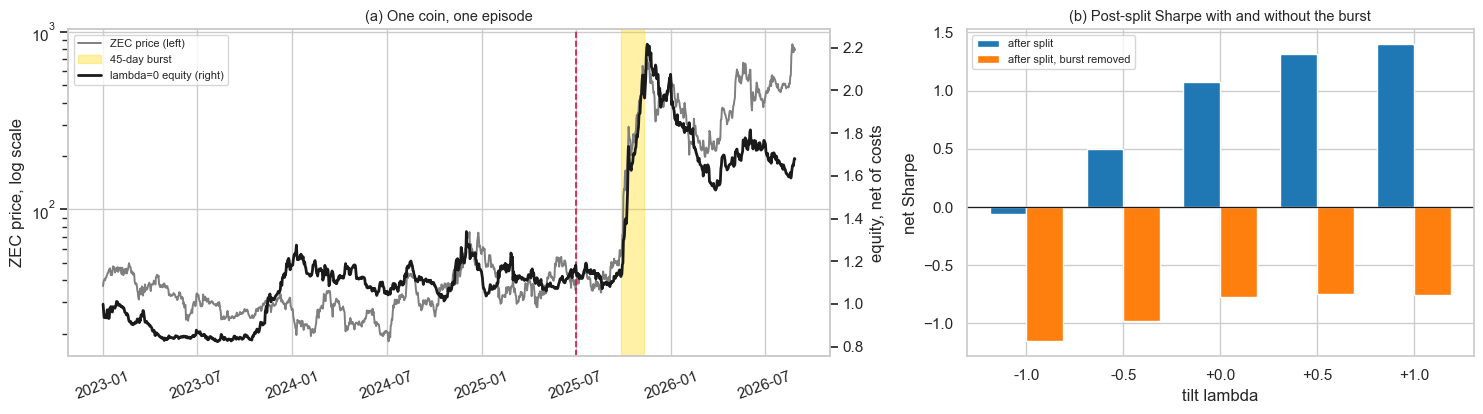


ZEC rank by trailing $ volume: 32 of 60 at the burst start, 19 at its end
  days in the point-in-time top-9 during the burst: 0 of 45
  first date in the point-in-time top-9 after the split: 2025-11-15
  ZEC is in the universe because its spread measured under 10 bps in 2026, after the run made it
  liquid. A SLOW (90-day median) real-time screen would not have held it for any of the run -- but
  ZEC's volume rose early in the run, so faster screens admit it within days. See the screen sweep.


In [37]:
# --- Where did the post-split Sharpe come from? --------------------------------
# The equity panel shows every book roughly doubling in a few weeks of late 2025. Before reading the
# "SR after 2025-07-01" column as evidence, find that stretch and attribute it.
_c45 = np.log1p(WF_NET[0].loc[SPLIT_DATE:WF_END]).rolling(45).sum()
BURST_END   = _c45.idxmax()
BURST_START = BURST_END - pd.Timedelta(days=44)
_pnl0 = (WF_W[0].shift(1) * XS_R).loc[BURST_START:BURST_END].sum().sort_values(ascending=False)
ZEC = 'ZECUSDT'
print(f'largest 45-day stretch after the split (lambda=0): {BURST_START.date()} -> {BURST_END.date()}, '
      f'{np.expm1(_c45.max()):+.0%} cumulative')
print(f'  ZEC price over it: {XS_PX[ZEC].loc[BURST_START]:.0f} -> {XS_PX[ZEC].loc[BURST_END]:.0f} '
      f'({XS_PX[ZEC].loc[BURST_END] / XS_PX[ZEC].loc[BURST_START] - 1:+.0%})')
print('  per-coin P&L of the lambda=0 book over it: '
      + ', '.join(f'{c[:-4]} {v:+.1%}' for c, v in _pnl0.items()))
print(f'  ZEC relative-volume z during it: {vzx[ZEC].loc[BURST_START:BURST_END].mean():+.2f} (unusually HIGH volume)\n')

def _ex(s):
    return s.drop(s.loc[BURST_START:BURST_END].index)

rows = {}
for l in WF_LAMBDAS:
    post = WF_NET[l].loc[SPLIT_DATE:WF_END].dropna()
    full = WF_NET[l].loc[WF_START:WF_END].dropna()
    rows[f'{l:+.1f}'] = {'SR after split':           sharpe(post),
                         'after split, ex-burst':    sharpe(_ex(post)),
                         'SR full span':             sharpe(full),
                         'full span, ex-burst':      sharpe(_ex(full)),
                         'avg ZEC weight in burst':  WF_W[l][ZEC].loc[BURST_START:BURST_END].mean(),
                         'ZEC P&L in burst':         (WF_W[l].shift(1) * XS_R)[ZEC].loc[BURST_START:BURST_END].sum()}
BURST_TABLE = pd.DataFrame(rows).T
BURST_TABLE.index.name = 'lambda'
display(BURST_TABLE.round(3))
print('The burst was chosen as the LARGEST 45-day stretch, so "ex-burst" is a deliberate stress test, not a')
print('fair estimate -- removing any strategy\'s best stretch lowers its Sharpe. The point is narrower:')
print('the post-split column rests on one trade, so it cannot discriminate between tilts. Its ranking of')
print('lambda is the ranking of ZEC weight, because ZEC\'s volume was high and a positive tilt leans into it.')

fig, ax = plt.subplots(1, 2, figsize=(15, 4.3), gridspec_kw={'width_ratios': [1.5, 1]})
_z = XS_PX[ZEC].loc[WF_START:WF_END]
ax[0].plot(_z, color='tab:gray', lw=1.4, label='ZEC price (left)')
ax[0].set_yscale('log'); ax[0].set_ylabel('ZEC price, log scale')
ax[0].axvspan(BURST_START, BURST_END, color='gold', alpha=.35, label='45-day burst')
ax[0].axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.2)
_ax2 = ax[0].twinx()
_ax2.plot(equity_curve(WF_NET[0].loc[WF_START:WF_END]), color='k', lw=2, label='lambda=0 equity (right)')
_ax2.set_ylabel('equity, net of costs'); _ax2.grid(False)
_h1, _l1 = ax[0].get_legend_handles_labels(); _h2, _l2 = _ax2.get_legend_handles_labels()
ax[0].legend(_h1 + _h2, _l1 + _l2, fontsize=8, loc='upper left')
ax[0].set_title('(a) One coin, one episode', fontsize=10.5); ax[0].tick_params(axis='x', rotation=20)

_xp = np.arange(len(WF_LAMBDAS)); _wd = 0.38
ax[1].bar(_xp - _wd/2, BURST_TABLE['SR after split'], _wd, label='after split', color='tab:blue')
ax[1].bar(_xp + _wd/2, BURST_TABLE['after split, ex-burst'], _wd, label='after split, burst removed', color='tab:orange')
ax[1].axhline(0, color='k', lw=.9)
ax[1].set_xticks(_xp); ax[1].set_xticklabels([f'{l:+.1f}' for l in WF_LAMBDAS])
ax[1].set(xlabel='tilt lambda', ylabel='net Sharpe', title='(b) Post-split Sharpe with and without the burst')
ax[1].title.set_fontsize(10.5); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


# --- was ZEC even in a point-in-time universe during the burst? ---
_rk_dv = _med.rank(axis=1, ascending=False)[ZEC]           # rank by trailing 90d median $ volume (rob1)
_in9   = pit_members(9)[ZEC]
_after = _in9.loc[SPLIT_DATE:]
print(f'\nZEC rank by trailing $ volume: {int(_rk_dv.loc[BURST_START])} of {_med.shape[1]} at the burst start, '
      f'{int(_rk_dv.loc[BURST_END])} at its end')
print(f'  days in the point-in-time top-9 during the burst: {int(_in9.loc[BURST_START:BURST_END].sum())} of '
      f'{len(_in9.loc[BURST_START:BURST_END])}')
print(f'  first date in the point-in-time top-9 after the split: {_after[_after].index.min().date()}')
print('  ZEC is in the universe because its spread measured under 10 bps in 2026, after the run made it')
print('  liquid. A SLOW (90-day median) real-time screen would not have held it for any of the run -- but')
print('  ZEC\'s volume rose early in the run, so faster screens admit it within days. See the screen sweep.')


### Conclusion

**1. Carry no volume tilt.** Over the full span, λ = 0 has the highest net Sharpe (0.58) and the highest
mean (0.86) and median (1.04) window Sharpe, and every tilt fails to beat it in 60–69% of windows. Tilting
in the hypothesised direction — sizing *down* on volume — is monotonically the worst (λ = −1: 0.13). This
matches the TRAIN heatmaps: at the frozen h = 5, no tilt already had the best net Sharpe of any λ. The frozen
specification stays **n = 15, h = 5, 20 bps, no volume layer**.

**2. The post-split column cannot rank the tilts.** It rests on one trade. ZEC rose roughly 11× between
2025-09-26 and 2025-11-09, and the untilted book made +51% on ZEC alone over that stretch. After the split,
the ranking of λ is just the ranking of ZEC weight: ZEC's volume was unusually high, so the positive tilts
leaned into it. The late-2024 sign flip in panel (c) is this episode entering the rolling windows.

**3. More important than the tilt: that trade leaned on the universe choice.** ZEC is in the universe because
its spread measured under 10 bps in **2026**, after the run had made it liquid. It was genuinely illiquid
before the run. How much of the run a real-time trader could have held depends on how fast the liquidity
screen reacts: a 90-day median screen admits ZEC only on 2025-11-15, after the run ended, but ZEC's volume
jumped in early October and faster screens admit it within days. The robustness section found the universe
choice was not load-bearing through 2025-07; after 2025-07 it matters, by an amount the screen-speed sweep
below measures.

**4. Without that episode, the strategy has no demonstrated out-of-sample edge.** Remove those 45 days and
every book's post-split Sharpe is about −0.8, while λ = 0's full-span Sharpe from 2023-01 falls to 0.01.
Because the largest stretch was removed on purpose, this is a stress test rather than a fair estimate.
Together with point 3, though, it means the evidence for XS momentum on this universe beyond TRAIN rests on
one trade, part of which depended on look-ahead. The TRAIN result (net ≈ 0.46) is not contradicted — but it is not
confirmed either.

**Next:** the section below re-runs this walk-forward on the point-in-time universe, where the ZEC episode cannot
enter. That is the test that decides whether the strategy survives out of sample.


---
# Walk-forward on a point-in-time universe

The walk-forward above found that the whole post-2025-07 gain is one ZEC trade, and that ZEC was only in the
universe because its spread was measured in 2026, after the run. This section re-runs the **same** walk-forward
— 139 windows, n = 15, h = 5, 20 bps, λ = 0 — on a universe built only from information available at the time:
each day, the **top 9 coins by trailing 90-day median dollar volume**, lagged one day. It is the same membership
rule as the robustness section.

Both books go through **one builder**, which takes a membership mask and nothing else. The first check is that
this builder, given the spread-9 mask, reproduces the walk-forward above exactly. If it does, any gap between the
two universes comes from *which coins are held*, and not from the code.

**Is dollar volume a fair stand-in for liquidity?** We have no historical spreads to check it against, only the
order-book snapshots collected in Aug–Sep 2026. Against those, the cell below shows that trailing dollar volume
ranks coins almost exactly as the real spread does.

**Four limitations, stated before the results:**

1. **The panel is a survivor set.** `download_data.ipynb` kept coins listed on Binance.US *and* Coinbase on the
   download date, with ≥90% hourly coverage through 2026. So this universe is point-in-time *among survivors*: a
   coin delisted between 2022 and 2026 can never enter it.
2. **The proxy is validated in 2026 only.** Using it for 2022–2025 assumes the volume–spread relationship held.
3. **The venue changed.** Binance.US dollar volume across these coins fell by roughly 90% from mid-2023, so
   "most liquid on Binance.US" means something different before and after.
4. **The cost is a flat 20 bps for both universes.** Coins such as APE, SHIB or VET may have traded at different
   spreads, which cannot be known without historical quotes.


In [38]:
# --- Point-in-time universe: validate the proxy, build both books, walk forward ---
# 1. Is trailing dollar volume a fair liquidity proxy? Check against the REAL 2026 spreads.
_hv   = panel['Volume']
_dv_d = (close * _hv).resample('1D').sum()
LIQ = pd.DataFrame({
    'real_spread_bps':   real_spread,
    'dollar_volume_90d': _dv_d.tail(90).median(),
    'frac_hours_traded': (_hv > 0).resample('1D').mean().tail(90).mean(),
    'amihud_90d':        (dclose.pct_change().abs() / _dv_d.replace(0, np.nan)).tail(90).median(),
}).dropna()
print(f'=== proxy check: trailing 90 days to {_dv_d.index.max().date()} vs spreads measured Aug-Sep 2026 '
      f'({len(LIQ)} coins) ===')
for c in ['dollar_volume_90d', 'frac_hours_traded', 'amihud_90d']:
    print(f'  Spearman rank correlation with real spread: {c:18s} {LIQ["real_spread_bps"].corr(LIQ[c], method="spearman"):+.2f}')
_top9_today = set(LIQ['dollar_volume_90d'].nlargest(9).index)
print(f'  top-9 by dollar volume today vs spread < 10 bps set: {len(_top9_today & set(XS_UNIVERSE))} of 9 in common')
VENUE_Q = _dv_d.sum(axis=1).resample('QE').mean()
print(f'  Binance.US daily $ volume across the 60 coins: ${VENUE_Q.loc[:"2023-06-30"].mean()/1e6:.0f}M/day before '
      f'Q3 2023, ${VENUE_Q.loc["2023-07-01":].mean()/1e6:.0f}M/day after\n')

# 2. One builder: the two books differ ONLY in their membership mask.
def conviction_net(members):
    """Conviction-sized XS momentum (n=BEST_N, h=NET_H, net of costs) on a membership mask over all coins."""
    m     = members.reindex_like(dclose).fillna(False).astype(bool)
    sig   = np.log(dclose).diff(BEST_N).where(m)
    rk    = sig.rank(axis=1, pct=True) - 0.5                         # mask BEFORE ranking
    daily = leg_norm(np.sign(rk), rk.abs()).fillna(0.0)              # fillna BEFORE hold: leavers decay out
    w     = hold(daily, NET_H)
    net   = (w.shift(1) * dclose.pct_change()).sum(axis=1) - turnover(w).shift(1) * bps(COST_BPS)
    return net, w, daily

MEM_SPREAD = pd.DataFrame(False, index=dclose.index, columns=dclose.columns)
MEM_SPREAD[XS_UNIVERSE] = True
MEM_PIT = pit_members(9)
NET_S9, W_S9, _ = conviction_net(MEM_SPREAD)
NET_P9, W_P9, D_P9 = conviction_net(MEM_PIT)

# INVARIANT: with the spread-9 mask the new builder must reproduce the walk-forward above.
_gap = NET_S9.loc[WF_START:WF_END].sub(WF_NET[0].loc[WF_START:WF_END]).abs().max()
assert _gap < 1e-12, f'builder does not reproduce WF_NET[0] (max gap {_gap:.2e})'
_wp = W_P9.loc[WF_START:WF_END]
assert _wp.sum(axis=1).abs().max() < 1e-9, 'PIT book is not dollar-neutral'
assert _wp.abs().sum(axis=1).max() < 1 + 1e-9, 'PIT book gross exceeds 1'
assert (D_P9.loc[WF_START:WF_END].abs() > 1e-12).sum(axis=1).max() <= 9, 'PIT daily book holds more than 9 coins'
print(f'invariant OK: the builder reproduces the spread-9 walk-forward (max gap {_gap:.1e}); '
      f'PIT book is dollar-neutral, gross <= 1, <= 9 coins\n')

# 3. Who was actually in the point-in-time top-9?
_mp   = MEM_PIT.loc[WF_START:WF_END]
EVER  = _mp.sum().loc[lambda s: s > 0].sort_values(ascending=False)
print(f'=== point-in-time top-9, {WF_START.date()} -> {WF_END.date()} ===')
print(f'  average overlap with the spread < 10 bps set: {_mp[XS_UNIVERSE].sum(axis=1).mean():.2f} of 9')
print(f'  membership changes (entries + exits): {int(_mp.astype(int).diff().abs().sum().sum())}')
print(f'  {len(EVER)} coins were ever in it; days held:')
print('   ' + ', '.join(f'{c[:-4]}{"*" if c in XS_UNIVERSE else ""} {int(d)}' for c, d in EVER.items()))
print('   (* = also in the spread < 10 bps set)\n')

# 4. Walk-forward, same 139 windows, both universes.
BOOKS = {'spread < 10 bps (2026 look-ahead)': (NET_S9, W_S9),
         'point-in-time top-9 by $ volume':   (NET_P9, W_P9)}
WIN_U = pd.DataFrame({lbl: [sharpe(_in(n_, s, e)) for s, e in WF_WINDOWS] for lbl, (n_, _) in BOOKS.items()},
                     index=[s for s, _ in WF_WINDOWS])
_btc_all = dclose['BTCUSDT'].pct_change()
_s9lbl, _p9lbl = list(BOOKS)
rows = {}
for lbl, (n_, w_) in BOOKS.items():
    full = n_.loc[WF_START:WF_END].dropna()
    post = n_.loc[SPLIT_DATE:WF_END].dropna()
    ws   = WIN_U[lbl]
    rows[lbl] = {'SR full span':            sharpe(full),
                 'SR after 2025-07-01':     sharpe(post),
                 'full span, burst removed': sharpe(_ex(full)),
                 'after split, burst removed': sharpe(_ex(post)),
                 'window SR mean':          ws.mean(),
                 'window SR median':        ws.median(),
                 'window SR std':           ws.std(),
                 'window SR min':           ws.min(),
                 'window SR max':           ws.max(),
                 '% windows > 0':           (ws > 0).mean(),
                 '% windows beat the other': (ws > WIN_U[_p9lbl if lbl == _s9lbl else _s9lbl]).mean(),
                 'turnover':                turnover(w_).loc[WF_START:WF_END].mean(),
                 'max drawdown':            max_drawdown(full),
                 'beta vs BTC':             alpha_beta(full, _btc_all.reindex(full.index))['beta']}
PIT_TABLE = pd.DataFrame(rows).T
print(f'=== walk-forward, {len(WF_WINDOWS)} windows, n={BEST_N}, h={NET_H}, lambda=0, net of {COST_BPS:.0f} bps ===')
display(PIT_TABLE.round(3))
_nf = len(NET_P9.loc[WF_START:WF_END].dropna()); _np_ = len(NET_P9.loc[SPLIT_DATE:WF_END].dropna())
print(f'standard error of a Sharpe: full span ({_nf} days) ~{np.sqrt(ANN_TRADING/_nf):.2f}; '
      f'after 2025-07-01 ({_np_} days) ~{np.sqrt(ANN_TRADING/_np_):.2f}')

# 5. The ZEC episode, under the point-in-time universe.
_zw = W_P9['ZECUSDT'].shift(1).loc[BURST_START:BURST_END]
assert (_zw.abs() < 1e-15).all(), 'PIT book held ZEC during the burst'
_pnlP = (W_P9.shift(1) * dclose.pct_change()).loc[BURST_START:BURST_END].sum()
_pnlP = _pnlP[_pnlP.abs() > 1e-9].sort_values(ascending=False)
print(f'\n=== the burst {BURST_START.date()} -> {BURST_END.date()} ===')
for lbl, (n_, _) in BOOKS.items():
    print(f'  {lbl:34s} cumulative {np.expm1(np.log1p(n_.loc[BURST_START:BURST_END]).sum()):+.1%}')
print('  point-in-time book held ZEC on 0 days (asserted). Its per-coin P&L over the burst:')
print('   ' + ', '.join(f'{c[:-4]} {v:+.1%}' for c, v in _pnlP.items()))


=== proxy check: trailing 90 days to 2026-08-28 vs spreads measured Aug-Sep 2026 (60 coins) ===
  Spearman rank correlation with real spread: dollar_volume_90d  -0.90
  Spearman rank correlation with real spread: frac_hours_traded  -0.91
  Spearman rank correlation with real spread: amihud_90d         +0.84
  top-9 by dollar volume today vs spread < 10 bps set: 8 of 9 in common
  Binance.US daily $ volume across the 60 coins: $62M/day before Q3 2023, $8M/day after

invariant OK: the builder reproduces the spread-9 walk-forward (max gap 1.4e-17); PIT book is dollar-neutral, gross <= 1, <= 9 coins

=== point-in-time top-9, 2023-01-01 -> 2026-08-28 ===
  average overlap with the spread < 10 bps set: 7.20 of 9
  membership changes (entries + exits): 140
  16 coins were ever in it; days held:
   ADA* 1336, BNB* 1336, BTC* 1336, DOGE* 1336, ETH* 1336, SOL* 1336, LINK 759, SHIB 691, AVAX* 685, LTC* 633, VET 470, XLM 418, ZEC* 287, NEAR 38, PAXG 16, ATOM 11
   (* = also in the spread < 10 bps 

,SR full span,SR after 2025-07-01,"full span, burst removed","after split, burst removed",window SR mean,window SR median,window SR std,window SR min,window SR max,% windows > 0,% windows beat the other,turnover,max drawdown,beta vs BTC
spread < 10 bps (2026 look-ahead),0.5820,1.0730,0.0120,-0.7720,0.8590,1.0350,0.5720,-0.3860,1.8300,0.9210,0.7190,0.1500,-0.3080,-0.0360
point-in-time top-9 by $ volume,0.1220,-0.3720,0.0230,-0.7650,0.2370,0.1790,0.6400,-0.9680,1.6190,0.5610,0.2810,0.1550,-0.3200,-0.0110


standard error of a Sharpe: full span (1336 days) ~0.43; after 2025-07-01 (424 days) ~0.77

=== the burst 2025-09-26 -> 2025-11-09 ===
  spread < 10 bps (2026 look-ahead)  cumulative +82.0%
  point-in-time top-9 by $ volume    cumulative +8.9%
  point-in-time book held ZEC on 0 days (asserted). Its per-coin P&L over the burst:
   AVAX +6.0%, BNB +4.5%, ADA +3.3%, LTC +2.3%, XLM +0.9%, BTC -0.1%, DOGE -1.4%, ETH -1.7%, LINK -1.8%, SOL -2.1%


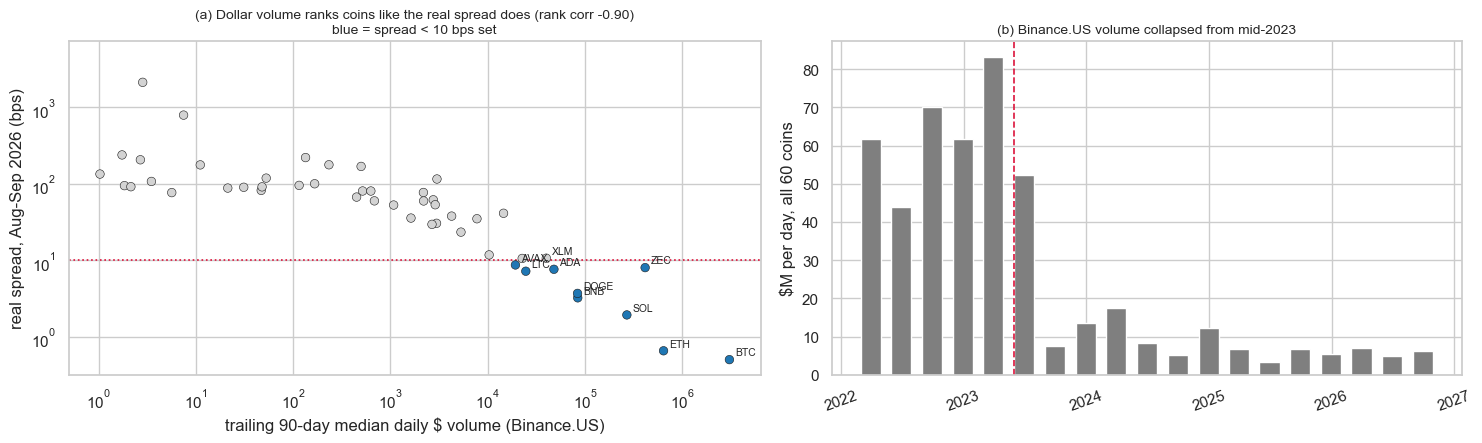

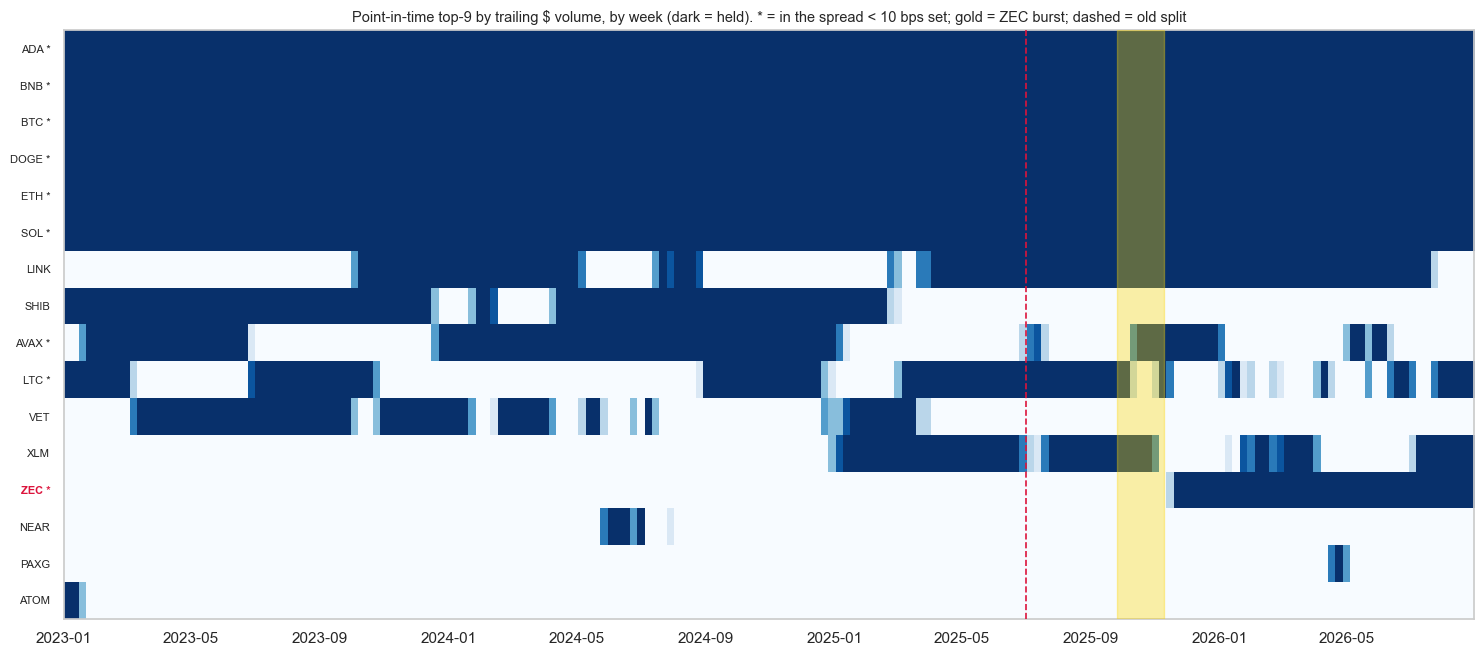

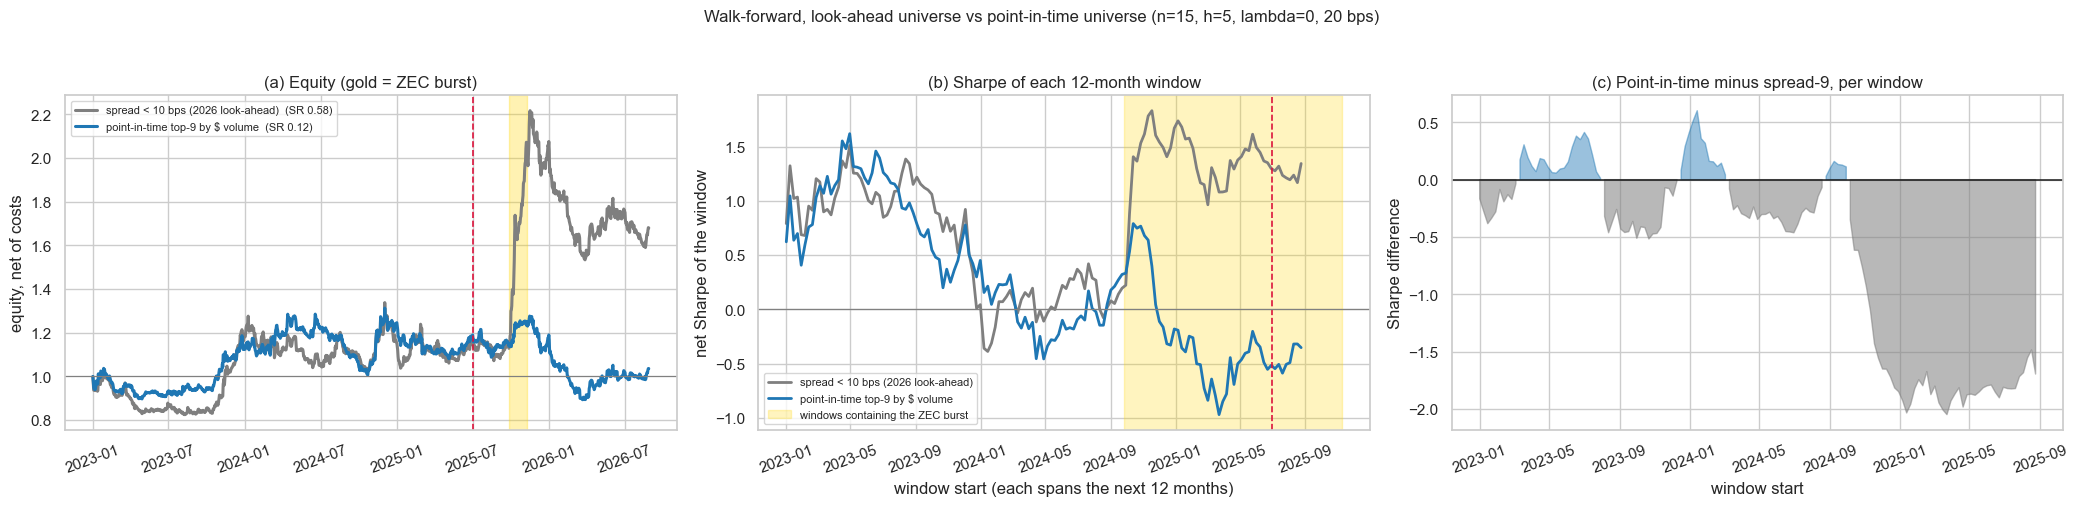

In [39]:
# --- Figures: the proxy, who was in the universe, and the results --------------
import matplotlib.dates as mdates

# (1) Is dollar volume a fair liquidity proxy? + how the venue changed
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={'width_ratios': [1.1, 1]})
_rho = LIQ['real_spread_bps'].corr(LIQ['dollar_volume_90d'], method='spearman')
_c = ['tab:blue' if s in XS_UNIVERSE else 'lightgrey' for s in LIQ.index]
ax[0].scatter(LIQ['dollar_volume_90d'], LIQ['real_spread_bps'], c=_c, s=38, edgecolor='k', lw=.4, zorder=3)
for s in LIQ.index:
    if s in XS_UNIVERSE or s in _top9_today or s == 'ZECUSDT':
        ax[0].annotate(s[:-4], (LIQ.loc[s, 'dollar_volume_90d'], LIQ.loc[s, 'real_spread_bps']),
                       textcoords='offset points', xytext=(4, 3), fontsize=7.5)
ax[0].set_xscale('log'); ax[0].set_yscale('log')
ax[0].axhline(10, color='crimson', ls=':', lw=1.2)
ax[0].set(xlabel='trailing 90-day median daily $ volume (Binance.US)', ylabel='real spread, Aug-Sep 2026 (bps)',
          title=f'(a) Dollar volume ranks coins like the real spread does (rank corr {_rho:+.2f})\nblue = spread < 10 bps set')
ax[0].title.set_fontsize(10)
ax[1].bar(VENUE_Q.index, VENUE_Q.values / 1e6, width=60, color='tab:gray')
ax[1].axvline(pd.Timestamp('2023-06-01', tz=TZ), color='crimson', ls='--', lw=1.2)
ax[1].set(ylabel='$M per day, all 60 coins', title='(b) Binance.US volume collapsed from mid-2023')
ax[1].title.set_fontsize(10); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

# (2) Who was actually in the point-in-time top-9, week by week
_wk   = _mp[EVER.index].resample('W').mean()
_nr   = len(EVER)
_x0, _x1 = mdates.date2num(_wk.index[0].tz_convert(None)), mdates.date2num(_wk.index[-1].tz_convert(None))
fig, ax = plt.subplots(figsize=(15, 0.32 * _nr + 1.6))
ax.imshow(_wk.T.values, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='nearest',
          extent=[_x0, _x1, _nr, 0])
ax.axvspan(mdates.date2num(BURST_START.tz_convert(None)), mdates.date2num(BURST_END.tz_convert(None)),
           color='gold', alpha=.35, zorder=3)
ax.axvline(mdates.date2num(SPLIT_DATE.tz_convert(None)), color='crimson', ls='--', lw=1.2, zorder=4)
ax.set_yticks(np.arange(_nr) + 0.5)
ax.set_yticklabels([f'{c[:-4]}{" *" if c in XS_UNIVERSE else ""}' for c in EVER.index], fontsize=8)
for t, c in zip(ax.get_yticklabels(), EVER.index):
    if c == 'ZECUSDT':
        t.set_color('crimson'); t.set_fontweight('bold')
ax.xaxis_date(); ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.set_title('Point-in-time top-9 by trailing $ volume, by week (dark = held). '
             '* = in the spread < 10 bps set; gold = ZEC burst; dashed = old split', fontsize=10.5)
ax.grid(False)
plt.tight_layout(); plt.show()

# (3) Results: equity, per-window Sharpe, per-window difference
_cols = {_s9lbl: 'tab:gray', _p9lbl: 'tab:blue'}
fig, ax = plt.subplots(1, 3, figsize=(21, 4.9))
for lbl, (n_, _) in BOOKS.items():
    ax[0].plot(equity_curve(n_.loc[WF_START:WF_END]), color=_cols[lbl], lw=2.2,
               label=f'{lbl}  (SR {PIT_TABLE.loc[lbl, "SR full span"]:.2f})')
    ax[1].plot(WIN_U.index, WIN_U[lbl], color=_cols[lbl], lw=2, label=lbl)
ax[0].axvspan(BURST_START, BURST_END, color='gold', alpha=.3)
ax[1].axvspan(BURST_START - pd.DateOffset(months=12), BURST_END, color='gold', alpha=.25,
              label='windows containing the ZEC burst')
for a in ax[:2]:
    a.axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.2)
    a.tick_params(axis='x', rotation=20)
ax[0].axhline(1, color='grey', lw=.8)
ax[0].set(ylabel='equity, net of costs', title='(a) Equity (gold = ZEC burst)')
ax[0].legend(fontsize=8)
ax[1].axhline(0, color='grey', lw=.9)
ax[1].set(xlabel='window start (each spans the next 12 months)', ylabel='net Sharpe of the window',
          title='(b) Sharpe of each 12-month window')
ax[1].legend(fontsize=8)
_d = WIN_U[_p9lbl] - WIN_U[_s9lbl]
ax[2].fill_between(_d.index, 0, _d, where=_d >= 0, color='tab:blue', alpha=.45)
ax[2].fill_between(_d.index, 0, _d, where=_d < 0, color='tab:gray', alpha=.55)
ax[2].axhline(0, color='k', lw=1.1)
ax[2].set(xlabel='window start', ylabel='Sharpe difference', title='(c) Point-in-time minus spread-9, per window')
ax[2].tick_params(axis='x', rotation=20)
fig.suptitle(f'Walk-forward, look-ahead universe vs point-in-time universe (n={BEST_N}, h={NET_H}, lambda=0, '
             f'{COST_BPS:.0f} bps)', y=1.03, fontsize=12)
plt.tight_layout(); plt.show()


### Conclusion under a 90-day screen: no out-of-sample edge

> **This depends on how fast the screen reacts.** A 90-day median is slow, and ZEC's liquidity rose early in
> its run. The next section re-runs the test with 7, 14 and 30-day screens and scores a window that starts when
> ZEC became liquid. The numbers below are correct *for the 90-day screen*.

| walk-forward, 2023-01 → 2026-08, λ = 0 | spread < 10 bps (2026 look-ahead) | point-in-time top-9 |
|---|---|---|
| net Sharpe, full span | 0.58 | **0.12** |
| net Sharpe after 2025-07-01 | 1.07 | **−0.37** |
| ZEC burst, 45 days | +82% | +9% |
| full span, burst removed | 0.01 | 0.02 |
| after split, burst removed | −0.77 | −0.77 |
| mean / median window Sharpe | 0.86 / 1.04 | 0.24 / 0.18 |
| 12-month windows positive | 92% | 56% |

**1. The comparison is clean.** The builder reproduces the earlier walk-forward to within 1e-17, so the gap
between the two columns comes entirely from which coins are held. The two universes share 7.2 of 9 coins on
average.

**2. The whole difference is ZEC.** Over the 45-day burst the look-ahead book made +82% and the point-in-time
book +9%. Remove that stretch and the two universes are indistinguishable: 0.01 vs 0.02 over the full span, and
−0.77 vs −0.77 after the split. One coin, one episode, held only because of a spread measured after the fact.

**3. On a universe a trader could actually have formed, the strategy earns 0.12 over 3.7 years** — about a
quarter of one standard error (≈ 0.43) — and **−0.37 after 2025-07-01**, the only stretch out-of-sample for
n = 15 and h = 5. Its 12-month windows are positive only 56% of the time. There is no demonstrated
out-of-sample edge.

**4. What this does not overturn.** The TRAIN result stands as an in-sample finding: net ≈ 0.46 on the spread
universe, and 0.47 on the point-in-time universe through 2025-07 in the robustness section (built there with
rank-demean weights). The signal worked on the window where it was chosen. What fails is persistence beyond that
window — consistent with the flat parameter grid, and with a venue whose volume fell by roughly 90% partway
through the sample.

**5. The limitations above still apply.** Survivorship in particular flatters momentum, so the true
out-of-sample figure is more likely lower than higher.


---
# Was the ZEC profit real? Reacting to liquidity

**The objection.** The point-in-time universe above excluded ZEC for the whole run. But the point of a
point-in-time universe is to exclude coins a trader *could not have known were tradable* — not to exclude
winners. If ZEC's liquidity rose fast enough, a real-time trader would have added it, and part of that profit
was real.

**What the data says about ZEC** (cell below): it was genuinely illiquid on Binance.US from 2022 through Q3 2025,
but its volume jumped in **early October 2025**, during the run rather than after it. The 90-day *median* screen
used above needs weeks of elevated volume to move, so it admitted ZEC only after the run ended.

**Two tests:**

1. **Screen-speed sweep.** The same 139-window walk-forward with liquidity screens of **7, 14, 30 and 90 days**.
   **The 30-day screen is the headline, fixed before any of these walk-forward Sharpes were computed.** A
   trailing one-month dollar-volume screen is the conventional liquidity filter. (A probe of *when* each screen
   admits ZEC was seen before choosing; no Sharpe was.) All four are reported.
2. **Post-liquidity-jump window.** Score every book from the first day a 7-day screen admits ZEC to the end of the
   data, as though reacting to liquidity. This window is split into the back half of the run and its aftermath,
   so it is clear where any profit comes from. It is one ~11-month period — too short for 12-month rolling
   windows, with a standard error near 0.9 — and its start date is event-chosen.

**Caveats.** A faster screen churns membership more, and that turnover is charged at 20 bps like everything else.
But the flat 20 bps also applies to ZEC in October 2025, days after its volume first spiked, when its real spread
is unknown. Capacity is untested too: ZEC traded roughly $50k–$1M a day in early October, which is fine for a
small book but not a large one.


In [40]:
# --- ZEC's liquidity: before, during, and after the run ---------------------------
Z = 'ZECUSDT'
_rank_daily = _dvol.rank(axis=1, ascending=False)
_ninth      = _dvol.apply(lambda r: r.nlargest(9).iloc[-1] if r.notna().sum() >= 9 else np.nan, axis=1)
ZEC_Q = pd.DataFrame({
    'ZEC $vol/day, median ($k)':     _dvol[Z].resample('QE').median() / 1e3,
    '9th-ranked coin, median ($k)':  _ninth.resample('QE').median() / 1e3,
    'ZEC daily rank, median':        _rank_daily[Z].resample('QE').median(),
    'share of hours ZEC traded':     (panel['Volume'][Z] > 0).resample('QE').mean(),
})
ZEC_Q.index = ZEC_Q.index.date
print('=== ZEC liquidity on Binance.US, by quarter ===')
display(ZEC_Q.round(2))

def screen_members(k, top=9):
    """Top-`top` coins by trailing k-day median $ volume, lagged 1 day. min_periods = 2k/3 (90 -> 60, as in rob1)."""
    med = _dvol.rolling(k, min_periods=max(2, int(k * 2 / 3))).median().shift(1)
    return med.rank(axis=1, ascending=False) <= top

SCREENS    = [7, 14, 30, 90]
HEADLINE_K = 30                                   # fixed before any sweep Sharpe was computed
SCREEN_MEM = {k: screen_members(k) for k in SCREENS}
_scr_rank  = {k: _dvol.rolling(k, min_periods=max(2, int(k * 2 / 3))).median().shift(1)
                   .rank(axis=1, ascending=False)[Z] for k in SCREENS}

_day = pd.DataFrame({'ZEC price': dclose[Z], 'ZEC $vol ($k)': _dvol[Z] / 1e3,
                     **{f'rank, {k}d screen': _scr_rank[k] for k in SCREENS},
                     'look-ahead book ZEC weight': W_S9[Z]}).loc['2025-09-14':'2025-11-20'].iloc[::3]
_day.index = _day.index.date
print('\n=== ZEC around the run, every 3rd day (rank <= 9 means the screen admits it) ===')
display(_day.round({'ZEC price': 0, 'ZEC $vol ($k)': 0, 'look-ahead book ZEC weight': 3}))

ZEC_ENTRY = {}
print('when each screen first admits ZEC after the old split, and on how many of the 45 burst days:')
for k in SCREENS:
    e = SCREEN_MEM[k][Z].loc[SPLIT_DATE:]
    ZEC_ENTRY[k] = e[e].index.min()
    print(f'  {k:>2}-day screen: first {ZEC_ENTRY[k].date()} | eligible '
          f'{int(SCREEN_MEM[k][Z].loc[BURST_START:BURST_END].sum()):2d} / {len(SCREEN_MEM[k][Z].loc[BURST_START:BURST_END])} burst days')
_sep = pd.Timestamp('2025-09-01', tz=TZ)
print(f'The look-ahead book already held {W_S9[Z].loc[_sep:BURST_START].mean():.0%} of its weight in ZEC in September,')
print(f'when ZEC traded a median ${_dvol[Z].loc[_sep:BURST_START].median()/1e3:.0f}k a day. No screen justifies that part.')


=== ZEC liquidity on Binance.US, by quarter ===


,"ZEC $vol/day, median ($k)","9th-ranked coin, median ($k)","ZEC daily rank, median",share of hours ZEC traded
2022-03-31,67.7000,"1,745.9400",35.5000,0.7500
2022-06-30,29.2600,"1,008.5000",43.0000,0.8300
2022-09-30,3.6000,410.4900,52.0000,0.4500
2022-12-31,3.3700,214.2000,43.0000,0.4800
2023-03-31,4.9200,252.5600,47.5000,0.7100
2023-06-30,5.7200,88.6000,33.0000,0.9300
2023-09-30,2.7500,62.0600,31.5000,0.8000
2023-12-31,5.2900,122.0600,36.0000,0.8500
2024-03-31,6.9700,176.9700,40.0000,0.8500
2024-06-30,3.0800,101.1200,36.0000,0.8400



=== ZEC around the run, every 3rd day (rank <= 9 means the screen admits it) ===


,ZEC price,ZEC $vol ($k),"rank, 7d screen","rank, 14d screen","rank, 30d screen","rank, 90d screen",look-ahead book ZEC weight
2025-09-14,50.0000,6.0000,29.0000,32.0000,33.0000,32.0000,0.1080
2025-09-17,51.0000,1.0000,35.0000,30.0000,30.0000,32.0000,0.1320
2025-09-20,50.0000,2.0000,31.0000,30.0000,31.0000,32.0000,0.1240
2025-09-23,55.0000,4.0000,31.0000,30.0000,30.0000,32.0000,0.0660
2025-09-26,56.0000,8.0000,24.0000,30.0000,29.0000,32.0000,0.1220
2025-09-29,72.0000,50.0000,24.0000,27.0000,29.0000,31.0000,0.1800
2025-10-02,131.0000,221.0000,13.0000,21.0000,28.0000,31.0000,0.1800
2025-10-05,166.0000,59.0000,8.0000,14.0000,26.0000,31.0000,0.1800
2025-10-08,173.0000,130.0000,9.0000,10.0000,23.0000,30.0000,0.1800
2025-10-11,292.0000,846.0000,9.0000,9.0000,20.0000,30.0000,0.1800


when each screen first admits ZEC after the old split, and on how many of the 45 burst days:
   7-day screen: first 2025-10-05 | eligible 36 / 45 burst days
  14-day screen: first 2025-10-10 | eligible 31 / 45 burst days
  30-day screen: first 2025-10-16 | eligible 25 / 45 burst days
  90-day screen: first 2025-11-15 | eligible  0 / 45 burst days
The look-ahead book already held 12% of its weight in ZEC in September,
when ZEC traded a median $2k a day. No screen justifies that part.


In [41]:
# --- Screen-speed sweep: the same walk-forward under 7 / 14 / 30 / 90-day screens --------
SWEEP = {'spread < 10 bps (look-ahead)': (NET_S9, W_S9, MEM_SPREAD)}
for k in SCREENS:
    n_, w_, d_ = conviction_net(SCREEN_MEM[k])
    _wk = w_.loc[WF_START:WF_END]
    assert _wk.sum(axis=1).abs().max() < 1e-9, f'{k}d: not dollar-neutral'
    assert _wk.abs().sum(axis=1).max() < 1 + 1e-9, f'{k}d: gross exceeds 1'
    assert (d_.loc[WF_START:WF_END].abs() > 1e-12).sum(axis=1).max() <= 9, f'{k}d: more than 9 coins'
    SWEEP[f'PIT top-9, {k}-day screen'] = (n_, w_, SCREEN_MEM[k])

# INVARIANT: the 90-day screen through the new function IS the point-in-time universe used above.
_g90 = SWEEP['PIT top-9, 90-day screen'][0].loc[WF_START:WF_END].sub(NET_P9.loc[WF_START:WF_END]).abs().max()
assert _g90 < 1e-12, f'90-day screen does not reproduce NET_P9 (gap {_g90:.2e})'
print(f'invariant OK: the 90-day screen reproduces the point-in-time book above (max gap {_g90:.1e}); '
      f'all books dollar-neutral, gross <= 1, <= 9 coins\n')

WIN_SCR = pd.DataFrame({lbl: [sharpe(_in(n_, s, e)) for s, e in WF_WINDOWS] for lbl, (n_, _, _) in SWEEP.items()},
                       index=[s for s, _ in WF_WINDOWS])
_R_all = dclose.pct_change()
rows = {}
for lbl, (n_, w_, mem) in SWEEP.items():
    full = n_.loc[WF_START:WF_END].dropna()
    k = None if lbl.startswith('spread') else int(lbl.split(', ')[1].split('-')[0])
    rows[lbl] = {
        'SR full span':            sharpe(full),
        'SR after 2025-07-01':     sharpe(n_.loc[SPLIT_DATE:WF_END].dropna()),
        'burst return':            np.expm1(np.log1p(n_.loc[BURST_START:BURST_END]).sum()),
        'ZEC P&L in burst':        (w_.shift(1) * _R_all)[Z].loc[BURST_START:BURST_END].sum(),
        'full span, burst removed': sharpe(_ex(full)),
        'ZEC first eligible':      '(always)' if k is None else str(ZEC_ENTRY[k].date()),
        'window SR mean':          WIN_SCR[lbl].mean(),
        '% windows > 0':           (WIN_SCR[lbl] > 0).mean(),
        'membership changes':      int(mem.loc[WF_START:WF_END].astype(int).diff().abs().sum().sum()),
        'turnover':                turnover(w_).loc[WF_START:WF_END].mean(),
    }
SWEEP_TABLE = pd.DataFrame(rows).T
print(f'=== walk-forward {WF_START.date()} -> {WF_END.date()}, {len(WF_WINDOWS)} windows, n={BEST_N}, h={NET_H}, '
      f'lambda=0, net of {COST_BPS:.0f} bps ===')
display(SWEEP_TABLE)
_hl = f'PIT top-9, {HEADLINE_K}-day screen'
print(f'HEADLINE (pre-registered {HEADLINE_K}-day screen): full-span net Sharpe {SWEEP_TABLE.loc[_hl, "SR full span"]:.2f}, '
      f'after 2025-07-01 {SWEEP_TABLE.loc[_hl, "SR after 2025-07-01"]:.2f}, '
      f'burst return {SWEEP_TABLE.loc[_hl, "burst return"]:+.0%}')
print(f'standard error of a full-span Sharpe ~{np.sqrt(ANN_TRADING / len(NET_S9.loc[WF_START:WF_END].dropna())):.2f}')


invariant OK: the 90-day screen reproduces the point-in-time book above (max gap 0.0e+00); all books dollar-neutral, gross <= 1, <= 9 coins

=== walk-forward 2023-01-01 -> 2026-08-28, 139 windows, n=15, h=5, lambda=0, net of 20 bps ===


,SR full span,SR after 2025-07-01,burst return,ZEC P&L in burst,"full span, burst removed",ZEC first eligible,window SR mean,% windows > 0,membership changes,turnover
spread < 10 bps (look-ahead),0.5824,1.0726,0.8200,0.5080,0.0123,(always),0.8590,0.9209,0,0.1500
"PIT top-9, 7-day screen",0.3511,0.5907,0.4218,0.2713,-0.0050,2025-10-05,0.5128,0.8561,986,0.1782
"PIT top-9, 14-day screen",0.3117,0.3418,0.2952,0.1771,0.0401,2025-10-10,0.4795,0.8921,460,0.1676
"PIT top-9, 30-day screen",0.3413,0.3829,0.3032,0.1929,0.0441,2025-10-16,0.4558,0.7266,274,0.1616
"PIT top-9, 90-day screen",0.1223,-0.3725,0.0887,0.0000,0.0230,2025-11-15,0.2366,0.5612,140,0.1553


HEADLINE (pre-registered 30-day screen): full-span net Sharpe 0.34, after 2025-07-01 0.38, burst return +30%
standard error of a full-span Sharpe ~0.43


In [42]:
# --- Post-liquidity-jump window: trade as though reacting to ZEC's liquidity ---------
_e7 = SCREEN_MEM[7][Z].loc[SPLIT_DATE:]
JUMP_DATE = _e7[_e7].index.min()
_AFTER    = BURST_END + pd.Timedelta(days=1)
_days     = len(NET_S9.loc[JUMP_DATE:WF_END].dropna())
print(f'window: {JUMP_DATE.date()} (first day a 7-day screen admits ZEC) -> {WF_END.date()}, {_days} days, '
      f'SE of a Sharpe ~{np.sqrt(ANN_TRADING / _days):.2f}')
print(f'split at the end of the run ({BURST_END.date()}): the back half of the run vs its aftermath\n')

def _cum(s):
    return np.expm1(np.log1p(s.dropna()).sum())

rows = {}
for lbl, (n_, w_, _) in SWEEP.items():
    whole, run, after = n_.loc[JUMP_DATE:WF_END].dropna(), n_.loc[JUMP_DATE:BURST_END], n_.loc[_AFTER:WF_END].dropna()
    rows[lbl] = {'net SR, whole window': sharpe(whole),
                 'return, whole window': _cum(whole),
                 f'return, run ({JUMP_DATE:%m-%d} to {BURST_END:%m-%d})': _cum(run),
                 'net SR, aftermath':    sharpe(after),
                 'return, aftermath':    _cum(after),
                 'max drawdown, whole':  max_drawdown(whole)}
JUMP_TABLE = pd.DataFrame(rows).T
display(JUMP_TABLE.round(3))
print(f'The run segment is only {len(n_.loc[JUMP_DATE:BURST_END])} days, so it is shown as a return, not a Sharpe.')
print('This window is one event-chosen period of about 11 months: read it as a check on the sweep, not a verdict.')


window: 2025-10-05 (first day a 7-day screen admits ZEC) -> 2026-08-28, 328 days, SE of a Sharpe ~0.88
split at the end of the run (2025-11-09): the back half of the run vs its aftermath



,"net SR, whole window","return, whole window","return, run (10-05 to 11-09)","net SR, aftermath","return, aftermath","max drawdown, whole"
spread < 10 bps (look-ahead),0.7790,0.2120,0.4930,-0.8640,-0.1880,-0.3080
"PIT top-9, 7-day screen",0.7200,0.1950,0.4170,-0.6450,-0.1570,-0.2810
"PIT top-9, 14-day screen",0.3410,0.0660,0.2900,-0.7270,-0.1730,-0.3000
"PIT top-9, 30-day screen",0.6420,0.1480,0.2980,-0.4790,-0.1150,-0.2980
"PIT top-9, 90-day screen",-0.4330,-0.1120,0.0710,-0.8400,-0.1700,-0.3000


The run segment is only 36 days, so it is shown as a return, not a Sharpe.
This window is one event-chosen period of about 11 months: read it as a check on the sweep, not a verdict.


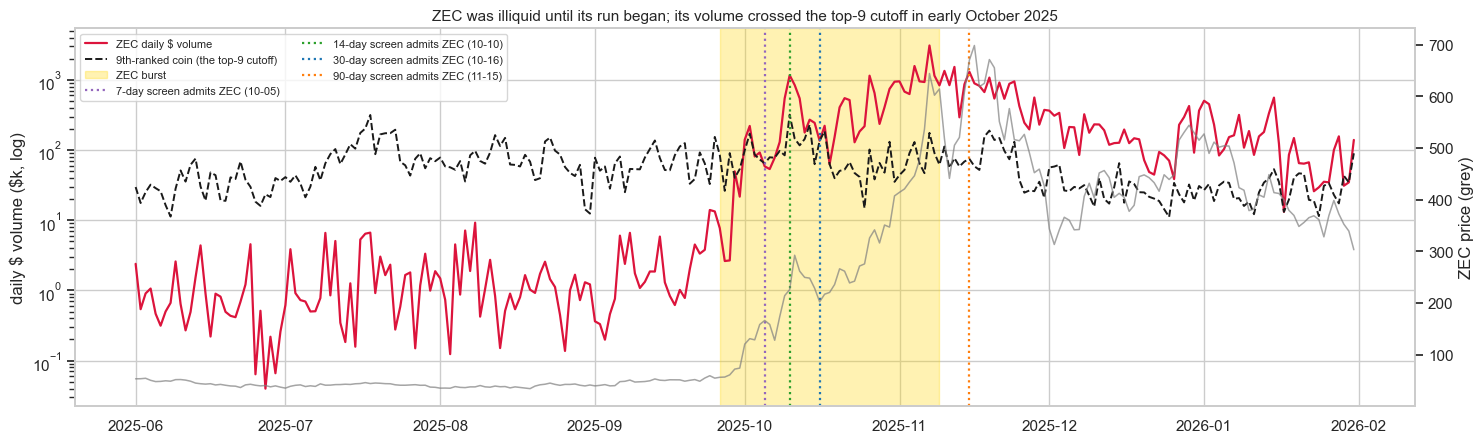

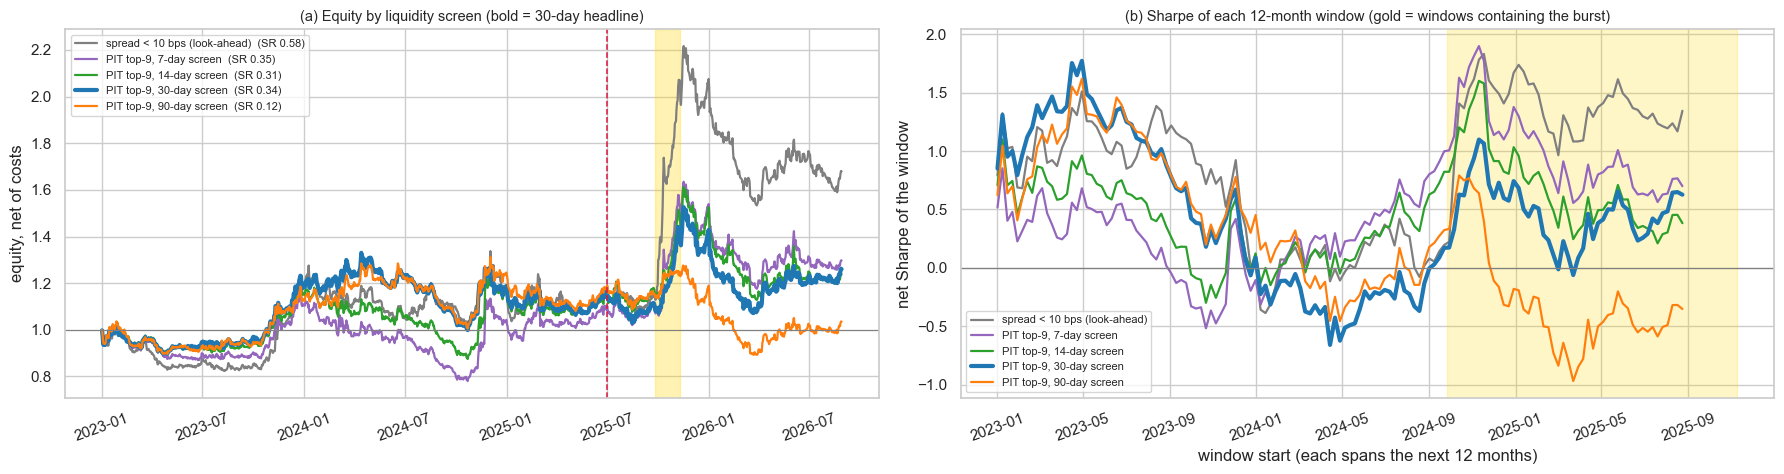

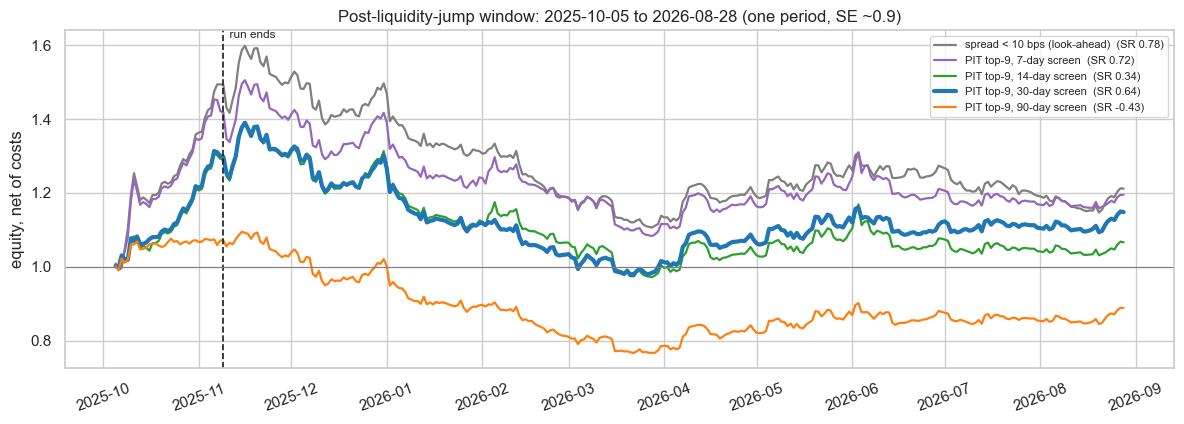

In [43]:
# --- Figures: ZEC liquidity, the sweep, and the post-jump window -----------------------
_scol = {'spread < 10 bps (look-ahead)': 'tab:gray', 'PIT top-9, 7-day screen': 'tab:purple',
         'PIT top-9, 14-day screen': 'tab:green', 'PIT top-9, 30-day screen': 'tab:blue',
         'PIT top-9, 90-day screen': 'tab:orange'}
_slw  = {lbl: (3.0 if lbl == _hl else 1.6) for lbl in _scol}
_kcol = {7: 'tab:purple', 14: 'tab:green', 30: 'tab:blue', 90: 'tab:orange'}

# (1) ZEC's liquidity against the top-9 cutoff
fig, ax = plt.subplots(figsize=(15, 4.6))
_lo, _hi = '2025-06-01', '2026-01-31'
ax.plot(_dvol[Z].loc[_lo:_hi] / 1e3, color='crimson', lw=1.6, label='ZEC daily $ volume')
ax.plot(_ninth.loc[_lo:_hi] / 1e3, color='k', lw=1.4, ls='--', label='9th-ranked coin (the top-9 cutoff)')
ax.set_yscale('log'); ax.set_ylabel('daily \\$ volume (\\$k, log)')
ax.axvspan(BURST_START, BURST_END, color='gold', alpha=.3, label='ZEC burst')
for k in SCREENS:
    ax.axvline(ZEC_ENTRY[k], color=_kcol[k], lw=1.6, ls=':', label=f'{k}-day screen admits ZEC ({ZEC_ENTRY[k]:%m-%d})')
_tw = ax.twinx()
_tw.plot(dclose[Z].loc[_lo:_hi], color='tab:gray', lw=1.1, alpha=.7)
_tw.set_ylabel('ZEC price (grey)'); _tw.grid(False)
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.set_title('ZEC was illiquid until its run began; its volume crossed the top-9 cutoff in early October 2025',
             fontsize=11)
plt.tight_layout(); plt.show()

# (2) the sweep
fig, ax = plt.subplots(1, 2, figsize=(18, 4.9))
for lbl, (n_, _, _) in SWEEP.items():
    ax[0].plot(equity_curve(n_.loc[WF_START:WF_END]), color=_scol[lbl], lw=_slw[lbl],
               label=f'{lbl}  (SR {SWEEP_TABLE.loc[lbl, "SR full span"]:.2f})')
    ax[1].plot(WIN_SCR.index, WIN_SCR[lbl], color=_scol[lbl], lw=_slw[lbl], label=lbl)
ax[0].axvspan(BURST_START, BURST_END, color='gold', alpha=.3)
ax[0].axvline(SPLIT_DATE, color='crimson', ls='--', lw=1.1)
ax[0].axhline(1, color='grey', lw=.8)
ax[0].set(ylabel='equity, net of costs', title=f'(a) Equity by liquidity screen (bold = {HEADLINE_K}-day headline)')
ax[1].axvspan(BURST_START - pd.DateOffset(months=12), BURST_END, color='gold', alpha=.22)
ax[1].axhline(0, color='grey', lw=.9)
ax[1].set(xlabel='window start (each spans the next 12 months)', ylabel='net Sharpe of the window',
          title='(b) Sharpe of each 12-month window (gold = windows containing the burst)')
for a in ax:
    a.legend(fontsize=8); a.tick_params(axis='x', rotation=20); a.title.set_fontsize(10.5)
plt.tight_layout(); plt.show()

# (3) the post-liquidity-jump window
fig, ax = plt.subplots(figsize=(12, 4.4))
for lbl, (n_, _, _) in SWEEP.items():
    ax.plot(equity_curve(n_.loc[JUMP_DATE:WF_END]), color=_scol[lbl], lw=_slw[lbl],
            label=f'{lbl}  (SR {JUMP_TABLE.loc[lbl, "net SR, whole window"]:.2f})')
ax.axvline(BURST_END, color='k', ls='--', lw=1.2)
ax.text(BURST_END, ax.get_ylim()[1], '  run ends', va='top', fontsize=8.5)
ax.axhline(1, color='grey', lw=.8)
ax.set(ylabel='equity, net of costs',
       title=f'Post-liquidity-jump window: {JUMP_DATE.date()} to {WF_END.date()} (one period, SE ~0.9)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


### Conclusion: part of the ZEC profit was real — and it is still one trade

| walk-forward 2023-01 → 2026-08, λ = 0 | look-ahead | 7-day | 14-day | **30-day (headline)** | 90-day |
|---|---|---|---|---|---|
| net Sharpe, full span | 0.58 | 0.35 | 0.31 | **0.34** | 0.12 |
| net Sharpe after 2025-07-01 | 1.07 | 0.59 | 0.34 | **0.38** | −0.37 |
| return over the 45-day burst | +82% | +42% | +30% | **+30%** | +9% |
| full span, burst removed | 0.01 | −0.01 | 0.04 | **0.04** | 0.02 |
| post-jump window (2025-10-05 →), net Sharpe | 0.78 | 0.72 | 0.34 | **0.64** | −0.43 |
| aftermath (after 2025-11-09), net Sharpe | −0.86 | −0.65 | −0.73 | **−0.48** | −0.84 |

**1. The objection holds.** ZEC was illiquid before its run, but its volume crossed the top-9 cutoff within days
of the run starting, and responsive screens admit it between 2025-10-05 and 10-16. Under the pre-registered
30-day screen the strategy scores **0.34** over the full span and makes **+30%** over the burst. About half of
the look-ahead book's out-of-sample result survives a universe a trader could have formed in real time. The
earlier conclusion — "the out-of-sample edge was the look-ahead" — came from the slow 90-day screen and is
withdrawn.

**2. What was not real** is the position before ZEC became liquid. The look-ahead book held ~12% of its weight
in ZEC through September, when ZEC traded a median $2k a day, and ZEC more than doubled before any screen
admitted it. That slice, plus the extra churn cost of reacting to it, is the look-ahead's share.

**3. The part that was real is still a single trade.** Remove the 45-day burst and every universe scores
between −0.01 and +0.04 over the full span — look-ahead or real-time, fast screen or slow. After the run ended,
every book lost money. The post-jump window's 0.64 under the 30-day screen is the back half of the run followed
by a drawdown.

**4. Read at the strength the evidence supports.** 0.34 (standard error ≈ 0.43) and 0.64 (≈ 0.88) are both
within one standard error of zero. Out of sample, XS momentum on this venue caught one strong trend in a coin
that became liquid as it trended — which is what momentum is supposed to do — and earned roughly nothing
otherwise. One episode is a real, capturable profit; it is not evidence of a persistent edge.

**5. Caveats.** ZEC's real spread in October 2025 is unknown, and the flat 20 bps may be optimistic days after its
volume first spiked. Capacity is limited: ZEC traded $50k–$1M a day in early October. The panel remains a survivor
set.
